<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 10 : K-Nearest Neighbors

1. KNN
2. Lazy Learning
3. Distance Metrics
    • Euclidean
    • Manhattan
    • Minkowski
    • Cosine
4. Choosing K
5. Voting
6. Weighted KNN
7. KD Tree
8. Ball Tree
9. Curse of Dimensionality
10. Hyperparameters
11. Detailed Python implementation (Dataset : Breast Cancer + Wine)
12. Comparison with SVM
13. Interview Questions

## 1. K-Nearest Neighbors (KNN)

### Subtask:
Provide a detailed explanation of KNN, covering its purpose, definition, intuition, mathematical foundation, formulas, a numerical example, Python implementation of the core concept, pros and cons, comparison with similar algorithms, and potential extensions. Each point will be explained with 10 subtopics.

### 1. Why we need K-Nearest Neighbors (KNN)

#### A. Simplicity and Interpretability:

*   **Why Needed:** In many machine learning scenarios, especially for beginners or when working with less complex datasets, a simple and easily interpretable model is highly desirable. KNN, being a non-parametric and instance-based algorithm, fits this need perfectly.
*   **Explanation:** KNN's decision-making process is transparent: to classify a new point, it simply looks at its closest neighbors. There's no complex model to interpret; the decision is directly derived from the training data itself. This makes it straightforward to understand *why* a particular prediction was made, which is crucial for building trust in the model.

#### B. Non-parametric Nature (No Assumptions about Data Distribution):

*   **Why Needed:** Many powerful algorithms, such as Linear Regression or Naive Bayes, make strong assumptions about the underlying distribution of the data (e.g., linearity, normality, independence of features). If these assumptions are violated, the model's performance can suffer significantly.
*   **Explanation:** KNN is a 'non-parametric' algorithm, meaning it does not make any assumptions about the functional form of the relationship between features and the target variable, nor does it assume a specific distribution for the data. This flexibility is a huge advantage when dealing with complex, irregular, or unknown data distributions, making it applicable to a wide range of real-world problems where parametric models might fail.

#### C. Adaptability to Complex Decision Boundaries:

*   **Why Needed:** In real-world data, classification boundaries are often non-linear and intricate. Linear models struggle to capture these complexities, leading to underfitting.
*   **Explanation:** Since KNN classifies a point based on its local neighborhood, it can naturally adapt to arbitrary and complex decision boundaries. Instead of trying to find a single global decision rule, KNN effectively creates a localized, flexible boundary. This ability makes it a powerful tool for datasets where classes are not easily separable by simple lines or planes.

#### D. Versatility for Both Classification and Regression:

*   **Why Needed:** A single algorithm capable of handling both prediction types can simplify the model selection process for data scientists.
*   **Explanation:** KNN is a versatile algorithm. For classification tasks, it uses a majority vote among its neighbors. For regression tasks, it typically averages the values of its neighbors. This dual capability means it can be applied to a broader spectrum of predictive modeling problems without needing to switch to entirely different algorithmic paradigms.

#### E. No Training Phase (Lazy Learning):

*   **Why Needed:** For datasets that are constantly updated or where new data comes in frequently, a model that doesn't require a time-consuming retraining phase can be highly beneficial.
*   **Explanation:** KNN is a 'lazy learner'. Unlike 'eager learners' (like Decision Trees or SVMs) that build a generalized model from the training data *before* making predictions, KNN simply stores the entire training dataset. All computation, such as distance calculation and voting, is performed only at the time of prediction. This means the 'training phase' is essentially non-existent, making it quick to 'train' and easy to update with new data.

### 2. Definition of K-Nearest Neighbors (KNN)

#### A. Formal Definition:

K-Nearest Neighbors (KNN) is a non-parametric, instance-based, supervised machine learning algorithm that can be used for both **classification** and **regression** tasks. It operates on the principle that 'similar things exist in close proximity'. The algorithm's core idea is to classify or predict the value of a new data point based on the labels or values of its 'K' closest neighbors in the feature space of the training dataset.

#### B. Key Characteristics in Definition:

*   **Non-parametric:** This means KNN makes no underlying assumptions about the distribution of the data. It doesn't learn a specific function mapping inputs to outputs but rather relies directly on the data itself.
*   **Instance-based (or Memory-based/Lazy Learner):** Instead of explicitly learning a model during a 'training phase', KNN simply memorizes the entire training dataset. All computation, such as finding neighbors and making predictions, is deferred until a query point needs to be classified or its value predicted.
*   **Supervised Learning:** KNN requires labeled training data (i.e., data points with known classes for classification or known values for regression) to make predictions for new, unlabeled data.
*   **Distance-Based:** The concept of 'proximity' or 'closeness' is central to KNN. It relies on a chosen distance metric (e.g., Euclidean, Manhattan) to quantify the similarity between data points.
*   **K (Number of Neighbors):** This is a user-defined positive integer that specifies how many neighbors will be considered when making a prediction. The choice of K is crucial and can significantly impact the model's performance.

#### C. How it "Defines" a Prediction:

*   **For Classification:** Given a new, unseen data point, KNN identifies its `K` nearest neighbors from the training set. The new data point is then assigned the class label that is most frequent among these `K` neighbors (i.e., a majority vote).

*   **For Regression:** For a new data point, KNN identifies its `K` nearest neighbors. The predicted value for the new data point is typically the average (mean) or median of the target values of these `K` neighbors.

In essence, KNN defines the characteristic of a new data point by the predominant characteristic of its closest known peers.

### 3. Intuition Behind K-Nearest Neighbors (KNN)

#### A. Analogy: Judging a Book by its Cover, or a Person by their Friends

Imagine you meet a new person, and you want to understand their personality or interests. A common approach is to look at their closest friends. If most of their friends are artists, you might intuit that this new person is also artistic. If their friends are mostly athletes, you might infer they are athletic. This simple human tendency is the core intuition behind KNN.

Similarly, imagine you have a collection of objects (say, fruits) and you find a new, unfamiliar fruit. To classify it, you naturally look at its nearest counterparts. If the new fruit looks most like apples in terms of color, size, and texture, you'd likely classify it as an apple.

#### B. Core Idea: Proximity Implies Similarity

The fundamental intuition of KNN is based on the assumption that **data points that are close to each other in the feature space are likely to be similar and belong to the same class or have similar values.** This is often referred to as the 'locality principle' or 'neighborhood-based classification'.

When a new, unclassified data point arrives:

1.  **"Who are your friends?" (Measure Proximity):** The algorithm calculates how 'close' or 'similar' this new data point is to *every single* data point in the training dataset. This 'closeness' is quantified using a chosen distance metric (e.g., Euclidean distance for continuous data).

2.  **"Identify your closest friends" (Identify Neighbors):** It then identifies the `K` data points from the training set that have the smallest distances to the new data point. These `K` points form the 'neighborhood' of the new point.

3.  **"What are your friends like?" (Vote/Average):**
    *   **For Classification:** The new data point is assigned to the class that is most represented (most frequent) among its `K` nearest neighbors. It's a 'majority vote' from the local neighborhood.
    *   **For Regression:** The value for the new data point is typically determined by taking the average (mean) or median of the target values of its `K` nearest neighbors.

#### C. Visualizing the Intuition:

Consider a 2D scatter plot where points are colored by their class. When you introduce a new, uncolored point:

*   If `K=1`, you find the single closest point and assign its class.
*   If `K=3`, you draw a small circle around the new point that encompasses its 3 closest neighbors. You then count the classes of these 3 points and assign the majority class.

The size of this 'neighborhood' (controlled by `K`) dictates how local or global the influence on the new point's classification will be. A small `K` focuses on very local patterns, while a large `K` considers a broader neighborhood.

### 4. Mathematical Foundation and Formulas

The core mathematical foundation of KNN lies in the concept of **distance** between data points. The algorithm relies on calculating how 'close' one data point is to another in a multi-dimensional feature space. The choice of distance metric is crucial as it dictates how similarity is measured.

Let's assume we have two data points, $P_1$ and $P_2$, in an $n$-dimensional space:
$P_1 = (x_{1,1}, x_{1,2}, ..., x_{1,n})$
$P_2 = (x_{2,1}, x_{2,2}, ..., x_{2,n})$

#### A. Euclidean Distance (L2 Norm)
This is the most common and intuitive distance metric. It represents the shortest straight-line distance between two points in Euclidean space.

**Formula:**
$d(P_1, P_2) = \sqrt{\sum_{i=1}^{n} (x_{1,i} - x_{2,i})^2}$

**Intuition:** Imagine a straight line connecting two points; its length is the Euclidean distance.

#### B. Manhattan Distance (L1 Norm or Taxicab Distance)
This metric calculates the sum of the absolute differences between the coordinates of the two points. It's like navigating city blocks, where you can only move horizontally or vertically.

**Formula:**
$d(P_1, P_2) = \sum_{i=1}^{n} |x_{1,i} - x_{2,i}|$

**Intuition:** The distance a taxi would travel along a grid-like street plan from one point to another.

#### C. Minkowski Distance
The Minkowski distance is a generalization of both Euclidean and Manhattan distances. It is parameterized by a value $p$.

**Formula:**
$d(P_1, P_2) = \left( \sum_{i=1}^{n} |x_{1,i} - x_{2,i}|^p \right)^{1/p}$

*   When $p=1$, it becomes the Manhattan distance.
*   When $p=2$, it becomes the Euclidean distance.
*   As $p \to \infty$, it becomes the Chebyshev distance (maximum coordinate difference).

**Intuition:** A flexible way to define distance, allowing tuning of the 'path' between points.

#### D. Cosine Similarity (and Cosine Distance)
Cosine similarity measures the cosine of the angle between two non-zero vectors. It indicates whether two vectors are pointing in roughly the same direction. It's often used when the magnitude of the vectors doesn't matter, but their orientation does (e.g., in text analysis to compare document similarity).

**Formula (Cosine Similarity):**
$similarity(P_1, P_2) = \frac{P_1 \cdot P_2}{||P_1|| \cdot ||P_2||} = \frac{\sum_{i=1}^{n} (x_{1,i} \cdot x_{2,i})}{\sqrt{\sum_{i=1}^{n} x_{1,i}^2} \cdot \sqrt{\sum_{i=1}^{n} x_{2,i}^2}}$

**Formula (Cosine Distance):**
$d(P_1, P_2) = 1 - similarity(P_1, P_2)$

**Intuition:** If two vectors are perfectly aligned (angle = 0 degrees), their similarity is 1. If they are orthogonal (angle = 90 degrees), their similarity is 0. If they are diametrically opposed (angle = 180 degrees), their similarity is -1. Cosine distance converts this similarity into a distance measure.

### 5. Numerical Example of KNN Classification

Let's walk through a simple numerical example to understand how KNN classifies a new data point.

**Scenario:** We have a dataset of fruits with two features: `Sweetness` and `Crunchiness`, and we want to classify whether a new fruit is an `Apple` or an `Orange`.

**Training Data:**

| Fruit   | Sweetness (X1) | Crunchiness (X2) | Type    |
| :------ | :------------- | :--------------- | :------ |
| Fruit A | 7              | 7                | Apple   |
| Fruit B | 7              | 4                | Orange  |
| Fruit C | 3              | 4                | Orange  |
| Fruit D | 1              | 4                | Orange  |
| Fruit E | 4              | 7                | Apple   |
| Fruit F | 6              | 2                | Orange  |

**New Data Point to Classify (Query Point):**
`New Fruit P`: `Sweetness = 3`, `Crunchiness = 7`

**Chosen K Value:** `K = 3` (We will consider the 3 nearest neighbors).

**Distance Metric:** Euclidean Distance.

---

**Steps:**

1.  **Calculate Distance to Every Training Data Point:**
    We will calculate the Euclidean distance between `New Fruit P (3, 7)` and each fruit in the training data.

    *   **Distance (P, Fruit A)**: $\sqrt{(3-7)^2 + (7-7)^2} = \sqrt{(-4)^2 + 0^2} = \sqrt{16} = 4$
    *   **Distance (P, Fruit B)**: $\sqrt{(3-7)^2 + (7-4)^2} = \sqrt{(-4)^2 + 3^2} = \sqrt{16 + 9} = \sqrt{25} = 5$
    *   **Distance (P, Fruit C)**: $\sqrt{(3-3)^2 + (7-4)^2} = \sqrt{0^2 + 3^2} = \sqrt{9} = 3$
    *   **Distance (P, Fruit D)**: $\sqrt{(3-1)^2 + (7-4)^2} = \sqrt{2^2 + 3^2} = \sqrt{4 + 9} = \sqrt{13} \approx 3.61$
    *   **Distance (P, Fruit E)**: $\sqrt{(3-4)^2 + (7-7)^2} = \sqrt{(-1)^2 + 0^2} = \sqrt{1} = 1$
    *   **Distance (P, Fruit F)**: $\sqrt{(3-6)^2 + (7-2)^2} = \sqrt{(-3)^2 + 5^2} = \sqrt{9 + 25} = \sqrt{34} \approx 5.83$

2.  **Order Distances and Identify K-Nearest Neighbors:**
    Now, we list the fruits by their distance to `New Fruit P` in ascending order:

    | Fruit   | Distance | Type    |
    | :------ | :------- | :------ |
    | Fruit E | 1        | Apple   |
    | Fruit C | 3        | Orange  |
    | Fruit D | 3.61     | Orange  |
    | Fruit A | 4        | Apple   |
    | Fruit B | 5        | Orange  |
    | Fruit F | 5.83     | Orange  |

    Since `K = 3`, our 3 nearest neighbors are:
    *   Fruit E (Distance = 1, Type = Apple)
    *   Fruit C (Distance = 3, Type = Orange)
    *   Fruit D (Distance = 3.61, Type = Orange)

3.  **Vote for the Class:**
    Count the occurrences of each class among the 3 nearest neighbors:
    *   Apple: 1 (Fruit E)
    *   Orange: 2 (Fruit C, Fruit D)

    The majority class is `Orange`.

---

**Conclusion:** Based on the KNN algorithm with `K=3`, the `New Fruit P` is classified as an **Orange**.

### 6. Python Implementation of Core KNN Concept

To fully grasp the mechanics of KNN, let's implement the core algorithm from scratch using Python. This implementation will cover:

1.  **Distance Calculation:** A function to compute the Euclidean distance between two points.
2.  **Neighbor Identification:** A function to find the `K` nearest neighbors for a given query point.
3.  **Prediction (Voting):** A function to determine the class of the query point based on the majority vote of its neighbors.

This implementation will use the same `training_data`, `training_labels`, and `query_point` from our numerical example.

In [2]:
import numpy as np
from collections import Counter

# 1. Define Euclidean Distance Function
def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

# 2. Define KNN Classifier Function
def knn_classify(training_data, training_labels, query_point, k):
    """Classifies a query point using the K-Nearest Neighbors algorithm."""
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_labels[i]))

    # Sort by distance and get the k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    # Get the labels of the k nearest neighbors
    neighbor_labels = [label for dist, label in k_nearest_neighbors]

    # Vote for the most common label
    most_common = Counter(neighbor_labels).most_common(1)
    return most_common[0][0]

# --- Our numerical example data ---
# Training features (Sweetness, Crunchiness)
training_data = [
    [7, 7], # Fruit A
    [7, 4], # Fruit B
    [3, 4], # Fruit C
    [1, 4], # Fruit D
    [4, 7], # Fruit E
    [6, 2]  # Fruit F
]

# Corresponding training labels
training_labels = ['Apple', 'Orange', 'Orange', 'Orange', 'Apple', 'Orange']

# New data point to classify (Sweetness=3, Crunchiness=7)
query_point = [3, 7]

# Chosen K value
k_value = 3

# Perform classification using our custom KNN function
predicted_class = knn_classify(training_data, training_labels, query_point, k_value)

print(f"New Fruit P ({query_point}) is classified as: {predicted_class}")

# Example for a different K value
k_value_5 = 5
predicted_class_5 = knn_classify(training_data, training_labels, query_point, k_value_5)
print(f"\nWith K = {k_value_5}, New Fruit P ({query_point}) is classified as: {predicted_class_5}")

New Fruit P ([3, 7]) is classified as: Orange

With K = 5, New Fruit P ([3, 7]) is classified as: Orange


### 7. Explanation of the Python Code for KNN

The Python code provided in the previous cell demonstrates a basic implementation of the K-Nearest Neighbors algorithm from scratch. Let's break down each part of the code to understand its functionality.

#### A. `euclidean_distance(point1, point2)` Function

*   **Purpose:** This function is responsible for calculating the Euclidean distance between any two given data points. As discussed in the 'Mathematical Foundation' section, Euclidean distance is a common metric to quantify the 'closeness' or 'similarity' between points.
*   **Explanation:**
    *   It takes two lists or arrays, `point1` and `point2`, representing the coordinates of the two data points.
    *   `np.array(point1) - np.array(point2)` calculates the difference between corresponding coordinates of the two points. This results in an array of differences.
    *   `**2` squares each of these differences.
    *   `np.sum(...)` adds up all the squared differences.
    *   `np.sqrt(...)` takes the square root of the sum, which gives the final Euclidean distance.

#### B. `knn_classify(training_data, training_labels, query_point, k)` Function

*   **Purpose:** This is the main function that encapsulates the KNN classification logic. It takes the training dataset, its labels, a new point to classify, and the value of `K`.
*   **Explanation:**
    1.  **Calculate Distances:**
        *   It initializes an empty list called `distances`.
        *   It then iterates through each `data_point` and its corresponding `training_label` in the `training_data`.
        *   For each `data_point`, it calls `euclidean_distance` to find the distance between the `query_point` and the current `data_point`.
        *   It stores a tuple `(distance, label)` in the `distances` list.
    2.  **Identify K-Nearest Neighbors:**
        *   `distances.sort(key=lambda x: x[0])` sorts the `distances` list based on the first element of each tuple (which is the distance value) in ascending order. This places the closest neighbors at the beginning of the list.
        *   `k_nearest_neighbors = distances[:k]` selects the first `k` elements from the sorted `distances` list. These are our K-nearest neighbors.
    3.  **Majority Vote for Classification:**
        *   `neighbor_labels = [label for dist, label in k_nearest_neighbors]` extracts only the class labels from the `k_nearest_neighbors` list.
        *   `Counter(neighbor_labels)` creates a dictionary-like object that counts the occurrences of each unique label in `neighbor_labels`.
        *   `.most_common(1)` returns a list of the `n` most common elements and their counts. Here, `1` means it returns only the single most common label.
        *   `[0][0]` accesses the label itself from the result (e.g., if `most_common` returns `[('Orange', 2)]`, `[0][0]` will extract `'Orange'`).

#### C. Example Data and Execution

*   The code defines `training_data` (features like Sweetness and Crunchiness) and `training_labels` (Apple or Orange) mirroring our numerical example.
*   `query_point` is the new fruit we want to classify.
*   `k_value` is set to `3` for the first classification.
*   The `knn_classify` function is called, and the `predicted_class` is printed.
*   A second example is provided with `k_value_5 = 5` to show how changing K can affect the prediction, demonstrating the robustness of the example. In this specific case, both `K=3` and `K=5` lead to the same classification for the `query_point`.

### 8. Pros and Cons of K-Nearest Neighbors (KNN)

Like any machine learning algorithm, K-Nearest Neighbors (KNN) comes with its own set of advantages and disadvantages. Understanding these can help in deciding when and where to apply KNN effectively.

#### A. Advantages (Pros)

1.  **Simplicity and Ease of Implementation:**
    *   **Explanation:** KNN is conceptually very simple. Its core idea is intuitive (finding the nearest neighbors and voting), making it easy to understand and implement from scratch. It's often one of the first algorithms taught in machine learning courses.

2.  **No Training Phase (Lazy Learner):**
    *   **Explanation:** KNN is a 'lazy learner' or 'instance-based learning' algorithm. It doesn't learn a discriminative function from the training data during a dedicated training phase. Instead, it simply stores the entire training dataset and performs computations only when a prediction is needed. This makes it very fast to 'train'.

3.  **Non-parametric Nature:**
    *   **Explanation:** KNN makes no explicit assumptions about the underlying distribution of the data (e.g., linearity, normality). This flexibility is a significant advantage when dealing with complex, irregular, or unknown data distributions, making it applicable to a wide range of real-world problems where parametric models might fail.

4.  **Adaptability to Complex Decision Boundaries:**
    *   **Explanation:** Since KNN classifies based on local neighborhoods, it can naturally adapt to arbitrary and complex decision boundaries. It doesn't try to fit a single global model but rather creates localized, flexible boundaries.

5.  **Versatility for Both Classification and Regression:**
    *   **Explanation:** KNN can be used for both classification (majority vote) and regression (averaging or median) tasks, providing a single algorithmic framework for different predictive modeling problems.

6.  **Good for Multi-Class Problems:**
    *   **Explanation:** KNN inherently handles multi-class classification problems without needing any specific modifications or strategies (like one-vs-rest or one-vs-one often required by algorithms like SVM).

#### B. Disadvantages (Cons)

1.  **Computationally Expensive Prediction Phase:**
    *   **Explanation:** While 'training' is fast, the prediction phase can be very slow, especially with large datasets. For every new query point, KNN must calculate its distance to *every single* training data point. This makes it inefficient for real-time predictions on massive datasets.

2.  **Memory Intensive:**
    *   **Explanation:** KNN needs to store the entire training dataset in memory (or have quick access to it) for prediction. This can be a significant limitation for datasets with many features or many training examples.

3.  **Sensitive to Irrelevant Features:**
    *   **Explanation:** KNN considers all features equally when calculating distances. If there are many irrelevant or noisy features, they can disproportionately influence the distance calculation, leading to poor performance. Feature selection or dimensionality reduction techniques are often necessary.

4.  **Sensitive to Feature Scaling:**
    *   **Explanation:** Features with larger ranges can dominate the distance calculation, regardless of their actual importance. Therefore, proper feature scaling (e.g., normalization or standardization) is almost always required before applying KNN.

5.  **Choice of K Value is Crucial:**
    *   **Explanation:** The performance of KNN is highly dependent on the choice of `K`. A small `K` can make the model sensitive to noise and outliers (high variance), while a large `K` can smooth out the decision boundaries too much, potentially leading to misclassifications for points near class boundaries (high bias). Choosing an optimal `K` often requires cross-validation.

6.  **Imbalanced Data Sensitivity:**
    *   **Explanation:** With imbalanced datasets (where one class significantly outnumbers others), KNN tends to be biased towards the majority class. If the `K` neighbors are predominantly from the majority class, the minority class points are often misclassified.

7.  **Curse of Dimensionality:**
    *   **Explanation:** In high-dimensional spaces (datasets with many features), the concept of 'distance' becomes less meaningful. All points tend to appear 'far' from each other, and the distinction between the closest and farthest neighbors diminishes. This makes it difficult to find truly 'nearest' neighbors and can significantly degrade KNN's performance. (We will discuss the Curse of Dimensionality in more detail later).

### 9. Comparison with Previous or Similar Algorithms/Models

To better understand K-Nearest Neighbors (KNN), it's helpful to compare it with other machine learning algorithms. This highlights KNN's strengths and weaknesses in different contexts.

#### A. KNN vs. Linear Models (e.g., Logistic Regression, Linear SVM)

*   **KNN:**
    *   **Nature:** Non-parametric, instance-based. No assumptions about data distribution.
    *   **Decision Boundary:** Can learn highly complex and non-linear decision boundaries. It's locally defined.
    *   **Interpretability:** Relatively high due to its simplicity (it's based on neighbors).
    *   **Computation:** Heavy at prediction time (needs to compute distances to all training points).
    *   **Data Requirements:** Requires all training data to be available at prediction time.
    *   **Feature Sensitivity:** Highly sensitive to feature scaling and irrelevant features.
    *   **Dimensionality:** Suffers from the curse of dimensionality.

*   **Linear Models (e.g., Logistic Regression):**
    *   **Nature:** Parametric, eager learner. Assumes a linear relationship between features and target (or a linear decision boundary).
    *   **Decision Boundary:** Creates a simple, linear decision boundary.
    *   **Interpretability:** High, as coefficients often indicate feature importance.
    *   **Computation:** Fast at prediction time once coefficients are learned during training.
    *   **Data Requirements:** Once trained, only the learned coefficients (model parameters) are needed for prediction.
    *   **Feature Sensitivity:** Less sensitive to individual noisy features if they don't significantly impact the linear relationship. Feature scaling is often still beneficial.
    *   **Dimensionality:** Can perform well in high dimensions if the relationships are genuinely linear, but still prone to issues with collinearity.

*   **Key Difference:** KNN is flexible with complex patterns but slow for prediction, while linear models are fast for prediction (after training) but rigid with complex, non-linear data.

#### B. KNN vs. Decision Trees

*   **KNN:**
    *   **Nature:** Non-parametric, instance-based, lazy learner.
    *   **Decision Boundary:** Smooth and highly adaptable, locally defined.
    *   **Interpretability:** Relatively simple, based on neighbors.
    *   **Feature Sensitivity:** Highly sensitive to feature scaling and irrelevant features.
    *   **Data Handling:** Does not handle categorical features directly without encoding. Requires numerical input.

*   **Decision Trees:**
    *   **Nature:** Non-parametric, rule-based, eager learner.
    *   **Decision Boundary:** Piecewise constant and axis-parallel (rectangular regions).
    *   **Interpretability:** Often very high (can be visualized as a flowchart of decisions).
    *   **Feature Sensitivity:** Generally robust to feature scaling (splits are based on thresholds). Can handle irrelevant features to some extent but might grow unnecessarily complex.
    *   **Data Handling:** Can handle both numerical and categorical features directly.

*   **Key Difference:** Decision Trees build explicit, interpretable rules, while KNN uses implicit rules based on local neighborhoods. KNN's decision boundaries are smoother than the step-like boundaries of Decision Trees.

#### C. KNN vs. Support Vector Machines (SVM)

*   **KNN:**
    *   **Nature:** Instance-based, lazy learner.
    *   **Decision Boundary:** Adapts to local data patterns.
    *   **Training Time:** No explicit training phase.
    *   **Prediction Time:** Slow for large datasets.
    *   **Memory:** High, stores all training data.
    *   **Outliers:** Sensitive to noisy data and outliers.

*   **SVM:**
    *   **Nature:** Eager learner, finds an optimal hyperplane.
    *   **Decision Boundary:** Learns a global optimal separating hyperplane (or non-linear boundary with kernels).
    *   **Training Time:** Can be computationally intensive during training, especially with large datasets or complex kernels.
    *   **Prediction Time:** Fast once trained (only support vectors are needed).
    *   **Memory:** Only needs to store support vectors for prediction (potentially much less than the whole dataset).
    *   **Outliers:** Less sensitive to outliers, as it focuses on the margin and support vectors.

*   **Key Difference:** SVM learns a global decision boundary during training, making predictions fast. KNN defers all computation to prediction time, making it flexible but slow. SVM aims to maximize the margin, leading to better generalization in many cases, while KNN's local nature can make it prone to noise.

### 10. Extensions and Enhancements to K-Nearest Neighbors (KNN)

While the basic KNN algorithm is simple and effective, several extensions and enhancements have been developed to address its limitations, particularly regarding computational efficiency, sensitivity to noise, and handling of imbalanced data.

#### A. Weighted K-Nearest Neighbors (WKNN)

*   **Why Needed:** In standard KNN, all `K` neighbors contribute equally to the classification or regression decision. However, closer neighbors are intuitively more relevant than farther ones. WKNN addresses this.
*   **Concept:** Instead of a simple majority vote (for classification) or average (for regression), WKNN assigns weights to each of the `K` neighbors. The weight is typically inversely proportional to the distance of the neighbor from the query point. This means closer neighbors have a greater influence on the final prediction.
*   **Formula (Classification - Weighted Vote):**
    The prediction for a class $C_j$ is given by:
    $P(C_j | x_q) = \frac{\sum_{i=1}^{K} w_i \cdot I(y_i = C_j)}{\sum_{i=1}^{K} w_i}$
    Where $x_q$ is the query point, $y_i$ is the label of neighbor $i$, $I(\cdot)$ is the indicator function (1 if true, 0 if false), and $w_i$ is the weight of neighbor $i$.
    Common weighting functions include:
    *   Inverse distance: $w_i = \frac{1}{d(x_q, x_i)}$
    *   Inverse squared distance: $w_i = \frac{1}{d(x_q, x_i)^2}$
    *   Gaussian kernel: $w_i = e^{-d(x_q, x_i)^2 / \sigma^2}$
*   **Benefit:** Reduces the impact of distant (and potentially noisy) neighbors and improves prediction accuracy in many cases.

#### B. KD-Trees (K-Dimensional Trees)

*   **Why Needed:** The most significant bottleneck of KNN is the need to compute distances to all training points for each query. For large datasets, this becomes computationally prohibitive. KD-Trees provide a way to speed up neighbor search.
*   **Concept:** A KD-Tree is a space-partitioning data structure that organizes points in a k-dimensional space. It recursively divides the data space into smaller regions (hyperrectangles) by splitting along one dimension at each node, cycling through dimensions.
*   **How it works:** When searching for nearest neighbors, the KD-Tree can efficiently prune large portions of the search space that are guaranteed not to contain the nearest neighbors, significantly reducing the number of distance calculations required.
*   **Benefit:** Dramatically speeds up the neighbor search process, making KNN feasible for larger datasets.
*   **Limitation:** Performance degrades in very high-dimensional spaces (Curse of Dimensionality), where the tree becomes unbalanced and less effective at pruning.

#### C. Ball Trees

*   **Why Needed:** Similar to KD-Trees, Ball Trees are designed to optimize nearest neighbor searches, especially in higher-dimensional spaces where KD-Trees can struggle.
*   **Concept:** A Ball Tree is a data structure that recursively partitions data points into nested

## 2. Lazy Learning

KNN is often referred to as a 'Lazy Learner'. To fully appreciate this aspect and other algorithms that fall into this category, it's essential to understand what Lazy Learning means, its implications, and its contrast with 'Eager Learning'.

### 1. Why we need Lazy Learning

#### A. Adaptability to Evolving Data:

*   **Why Needed:** In many real-world applications, data is not static. New observations arrive constantly, and the underlying patterns might shift over time (concept drift). Algorithms that require extensive retraining with every data update can be cumbersome and computationally expensive.
*   **Explanation:** Lazy learners, by deferring all computation to the prediction phase, naturally adapt to evolving data. When new data points are added to the dataset, they are simply stored, and no prior 'model' needs to be re-built. This makes them highly suitable for dynamic environments where the data distribution changes frequently or where real-time updates are critical, as the 'model' is always up-to-date with the latest information without explicit retraining.

#### B. Handling Complex and Irregular Decision Boundaries:

*   **Why Needed:** As discussed with KNN, real-world data often exhibits complex, non-linear relationships that are difficult to model with fixed parametric functions. Eager learners try to generalize these patterns globally.
*   **Explanation:** Lazy learning, being instance-based, can capture highly intricate and local patterns within the data. Instead of forcing a single, global decision boundary, it builds its 'model' locally around each query point. This ability to form arbitrary decision boundaries without making strong assumptions about the data's underlying structure is invaluable for complex datasets where traditional models might oversimplify the relationships.

#### C. No Prior Model Assumptions:

*   **Why Needed:** Many 'eager' algorithms (e.g., Linear Regression, Naive Bayes, Logistic Regression) assume specific functional forms or statistical distributions for the data. Violations of these assumptions can lead to poor model performance.
*   **Explanation:** Lazy learning algorithms are non-parametric; they make no a priori assumptions about the data's underlying distribution or the relationship between features and target. They learn directly from the data points themselves, making them robust when the true data-generating process is unknown or highly complex. This flexibility reduces the risk of making incorrect assumptions that could lead to a biased or ineffective model.

#### D. Localized Learning for Specific Queries:

*   **Why Needed:** Sometimes, the goal isn't to build a universal model that explains the entire dataset, but rather to provide accurate predictions for specific, localized queries. A global model might smooth over nuances that are important in a particular region of the feature space.
*   **Explanation:** Lazy learning excels at providing localized predictions. For each new query, it constructs a unique 'local model' based only on the nearest neighbors relevant to that query. This ensures that the prediction is highly tailored to the immediate vicinity of the query point, potentially leading to more accurate and context-aware predictions than a global model might offer.

#### E. Simplicity in Concept and Debugging:

*   **Why Needed:** For certain tasks or during initial data exploration, a straightforward algorithm that is easy to understand and debug can be highly advantageous. Complex models can be black boxes.
*   **Explanation:** The fundamental concept of lazy learning (just storing data and comparing it to new points) is intuitively simple. This simplicity translates to easier understanding of how predictions are made, which can be beneficial for interpreting results and identifying potential issues or outliers. Since there's no complex model to train and optimize in advance, debugging often boils down to checking distance calculations and neighbor selection.

### 2. Definition of Lazy Learning

#### A. Core Concept: Deferring Generalization

**Lazy Learning** (also known as **Instance-Based Learning** or **Memory-Based Learning**) is a machine learning approach where the generalization of the training data is *deferred* until a prediction request is made for a new, unseen data point. Unlike 'Eager Learning' algorithms that build a generalized model (e.g., a decision tree, a set of regression coefficients, or SVM hyperplanes) during a distinct training phase *before* any predictions are needed, a lazy learner simply stores the entire training dataset.

#### B. Key Characteristics in Definition:

1.  **No Explicit Training Phase:**
    *   **Explanation:** The algorithm doesn't create a generalized model or learn a set of parameters from the training data in advance. It essentially 'memorizes' all the training examples. This means the 'training time' is effectively zero, as it just involves storing the data.

2.  **Computation at Query Time (Prediction Phase):**
    *   **Explanation:** All computational effort, such as finding patterns, calculating distances, or performing local approximations, is expended only when a new query point arrives and a prediction is required. The algorithm processes the stored training data *on-demand* to answer the specific query.

3.  **Instance-Based:**
    *   **Explanation:** Predictions for new instances are made directly from the stored training instances (often called 'exemplars' or 'prototypes'). The algorithm uses these specific instances to infer the output for the new query, rather than relying on a generalized abstraction of the data.

4.  **Local Approximation:**
    *   **Explanation:** Lazy learners typically make predictions based on a small, localized neighborhood of the query point in the feature space. They assume that data points close to each other are likely to have similar labels or values.

5.  **Non-Parametric (Often):**
    *   **Explanation:** Many lazy learning algorithms (like KNN) are non-parametric, meaning they do not make assumptions about the underlying data distribution or the functional form of the relationship between input features and output. This allows them to capture complex patterns that parametric models might miss.

#### C. Analogy to further clarify:

*   **Eager Learner (e.g., Decision Tree):** Imagine a student who studies for an exam by summarizing the entire textbook into a concise set of notes *before* the exam. On the exam, they refer to their pre-compiled notes to answer questions quickly.
*   **Lazy Learner (e.g., KNN):** Imagine a student who, for the same exam, doesn't summarize anything. Instead, when a question comes up, they open the textbook and search for the *most relevant paragraphs* to answer that specific question. They only do the work when asked to.

#### D. Relationship to KNN:

K-Nearest Neighbors (KNN) is the quintessential example of a lazy learning algorithm because it satisfies all these characteristics: it stores all training data, performs all computations (distance calculations, voting) only at prediction time, makes decisions based on local instances, and is non-parametric.

### 3. Intuition Behind Lazy Learning

The intuition behind lazy learning can be best understood by contrasting it with 'eager learning'.

#### A. Eager Learning Intuition: Build a Master Plan First

Imagine an **eager learner** as a meticulous planner or a general who wants to conquer a territory. Before undertaking any specific mission (making a prediction), the general spends a significant amount of time studying the entire terrain, drawing detailed maps, identifying all strategic points, and formulating a comprehensive battle plan for *all* possible scenarios.

*   **Training Phase:** The general studies all available historical data (training data) to build a universal, generalized model (the detailed map and battle plan). This model is a condensed representation of all the knowledge learned.
*   **Prediction Phase:** When a new threat or mission arises (a new query point), the general quickly consults their pre-built map and battle plan. They don't need to re-analyze the entire terrain; they just apply the relevant part of their existing plan. Predictions are fast because all the hard work was done upfront.

Examples: Decision Trees, Logistic Regression, Support Vector Machines.

#### B. Lazy Learning Intuition: Learn on the Fly, Only When Necessary

Now, imagine a **lazy learner** as an expert detective or a highly resourceful scout. This scout doesn't waste time memorizing every single detail of the entire vast wilderness upfront. Instead, they operate on a need-to-know basis.

*   **Training Phase (Storage):** The scout simply keeps a record of all their past experiences, observations, and encountered locations (stores the entire training dataset). There's no initial grand plan or model built; just a collection of raw data.
*   **Prediction Phase (Action):** When asked to make a decision or find something in a specific new location (a new query point), the scout immediately focuses *only* on the relevant surroundings. They don't consult a global map. Instead, they quickly search their memory for similar past experiences or nearby landmarks (finds the K-nearest neighbors) and uses *only that local information* to make a decision or predict the outcome for the current situation.

*   **Key Idea:** The 'intelligence' or 'model' isn't pre-baked; it emerges dynamically and locally when a query is presented. It's like having a library full of books and only reading the relevant chapters when a specific question needs an answer, rather than trying to summarize all books beforehand.

#### C. Example with KNN:

For a new data point, a lazy learner like KNN doesn't refer to a pre-defined boundary line or a set of rules. Instead, it looks at its immediate neighbors in the training data and asks: "What is the most common characteristic among my closest acquaintances?" The intuition is that the identity of a new item is best determined by the identity of the items it most closely resembles, rather than by fitting it into a global categorical framework.

### 4. Mathematical Underpinnings of Lazy Learning

While lazy learning doesn't have a single overarching mathematical 'model' like a linear regression equation or a decision tree structure, its mathematical foundation lies in its operational principles: **distance-based similarity** and **local estimation**.

Let's formalize some of these concepts.

#### A. No Explicit Model Function (f(x))

In eager learning, the goal is often to learn a function $f(x)$ that maps input features $x$ to an output $y$ ($y = f(x)$). This function is typically represented by a set of parameters $\theta$ (e.g., coefficients in linear regression, weights in a neural network) that are optimized during training. The prediction for a new point $x_q$ is simply $f(x_q, \theta)$.

In lazy learning, there is **no explicit global function $f(x)$ or set of parameters $\theta$** that is learned from the entire dataset. Instead, for each query point $x_q$, a *local* model or estimation is constructed on-the-fly.

#### B. Distance Metric (as seen in KNN)

As we discussed with KNN, the core mathematical component is the **distance function** $d(x_a, x_b)$ which quantifies the dissimilarity between any two data points $x_a$ and $x_b$.

*   Given a query point $x_q$ and a training dataset $D = \{(x_i, y_i)\}_{i=1}^N$, where $x_i$ are features and $y_i$ are labels/values.
*   The first step is to compute $d(x_q, x_i)$ for all $i \in \{1, ..., N\}$.

Common distance metrics (as previously covered):
*   **Euclidean Distance (L2 norm):** $d(x_a, x_b) = \sqrt{\sum_{j=1}^{M} (x_{a,j} - x_{b,j})^2}$
*   **Manhattan Distance (L1 norm):** $d(x_a, x_b) = \sum_{j=1}^{M} |x_{a,j} - x_{b,j}|$
*   **Minkowski Distance (Lp norm):** $d(x_a, x_b) = \left( \sum_{j=1}^{M} |x_{a,j} - x_{b,j}|^p \right)^{1/p}$

#### C. Nearest Neighbor Selection

After computing distances, the next mathematical step is to identify the $K$ points from the training set $D$ that are closest to $x_q$. Let's denote the set of these $K$ nearest neighbors as $N_K(x_q)$.

$N_K(x_q) = \{ (x_i, y_i) \in D \mid (x_i, y_i) \text{ is one of the K smallest } d(x_q, x_i) \}$

#### D. Local Estimation (Prediction)

The final mathematical step involves using the labels/values of the neighbors in $N_K(x_q)$ to make a prediction for $x_q$.

**1. For Classification (Majority Vote):**
The predicted class $\hat{y}_q$ for the query point $x_q$ is the class that appears most frequently among its $K$ nearest neighbors.

$\hat{y}_q = \operatorname{argmax}_{c} \sum_{(x_i, y_i) \in N_K(x_q)} I(y_i = c)$

Where $I(\cdot)$ is the indicator function (returns 1 if the condition is true, 0 otherwise), and $c$ iterates through all possible class labels.

**2. For Regression (Average/Median):**
The predicted value $\hat{y}_q$ for the query point $x_q$ is typically the mean or median of the target values of its $K$ nearest neighbors.

$\hat{y}_q = \frac{1}{K} \sum_{(x_i, y_i) \in N_K(x_q)} y_i \quad \text{(Mean)}$

or

$\hat{y}_q = \operatorname{median}_{ (x_i, y_i) \in N_K(x_q) } y_i \quad \text{(Median)}$

#### E. No Gradient Descent or Model Optimization

A key 'absence' in the mathematics of lazy learning, distinguishing it from many eager algorithms, is the lack of a complex optimization process involving calculus, gradient descent, or iterative parameter updates. The 'learning' is effectively the storage of data, and the 'prediction' is a direct, distance-based look-up and aggregation process.

### 5. Formulas in Lazy Learning

Unlike eager learning algorithms that learn a fixed set of parameters or a global function (a single 'formula' for the entire dataset) during a training phase, lazy learning algorithms don't have a singular, universally applied formula that defines the entire model. Instead, the 'formulas' are applied *dynamically* and *locally* for each new query point, based on its nearest neighbors.

Since K-Nearest Neighbors (KNN) is the most prominent example of a lazy learning algorithm, its formulas effectively represent the core mathematical operations for this paradigm.

Let's assume we have:
*   A query point: $x_q$
*   A training dataset: $D = \{(x_i, y_i)\}_{i=1}^N$, where $x_i$ are feature vectors and $y_i$ are their corresponding labels/values.
*   A chosen number of neighbors: $K$
*   A chosen distance metric: $d(x_a, x_b)$

#### A. Step 1: Distance Calculation Formula

For each training data point $x_i \in D$, calculate its distance to the query point $x_q$. This uses the chosen distance metric. For instance, using **Euclidean Distance** (as commonly applied in KNN):

$d(x_q, x_i) = \sqrt{\sum_{j=1}^{M} (x_{q,j} - x_{i,j})^2}$

Where $M$ is the number of features (dimensions) and $x_{q,j}$ and $x_{i,j}$ are the $j$-th feature values of the query point and the $i$-th training point, respectively.

#### B. Step 2: Neighbor Selection (No Explicit Formula, but a Procedure)

This step involves a sorting and selection procedure rather than a mathematical formula. All calculated distances $d(x_q, x_i)$ are sorted in ascending order, and the $K$ training points corresponding to the smallest distances are selected. Let this set of $K$ nearest neighbors and their labels/values be denoted as $N_K(x_q) = \{ (x_{(1)}, y_{(1)}), (x_{(2)}, y_{(2)}), ..., (x_{(K)}, y_{(K)}) \}$, where $(x_{(p)}, y_{(p)})$ is the $p$-th nearest neighbor.

#### C. Step 3: Prediction Formula (Local Aggregation)

The final prediction for $x_q$ is made by aggregating the labels/values of the $K$ nearest neighbors. The 'formula' for this aggregation depends on whether it's a classification or regression task.

1. **For Classification (Majority Vote Formula):**

   The predicted class $\hat{y}_q$ for the query point $x_q$ is the class label that occurs most frequently among the $K$ nearest neighbors.

   $$
   \hat{y}_q
   =
   \operatorname*{arg\,max}_{c\in\text{Classes}}
   \left(
   \sum_{(x_{(p)},\,y_{(p)})\in N_K(x_q)}
   I(y_{(p)}=c)
   \right)
   $$

   where

   $$
   I(y_{(p)}=c)=
   \begin{cases}
   1, & \text{if } y_{(p)}=c,\\
   0, & \text{otherwise.}
   \end{cases}
   $$

   This formula counts the occurrences of each class among the $K$ nearest neighbors and selects the class with the highest count.

2. **For Regression (Averaging Formula):**

   The predicted value $\hat{y}_q$ for the query point $x_q$ is typically the mean of the target values of its $K$ nearest neighbors.

   $$
   \hat{y}_q
   =
   \frac{1}{K}
   \sum_{(x_{(p)},\,y_{(p)})\in N_K(x_q)}
   y_{(p)}
   $$

   Alternatively, the median can be used:

   $$
   \hat{y}_q
   =
   \operatorname{median}
   \left\{
   y_{(p)}
   \;\middle|\;
   (x_{(p)},\,y_{(p)})\in N_K(x_q)
   \right\}
   $$

#### Summary

These formulas are not 'learned' in advance; they are applied as a computational routine *every time* a new prediction is requested. The core mathematical structure of lazy learning revolves around these distance computations and subsequent local aggregations of neighbor information.

### 6. Numerical Example of Lazy Learning (using KNN)

Since K-Nearest Neighbors (KNN) is the quintessential example of a lazy learning algorithm, the numerical example for KNN that we previously covered effectively serves as a numerical example for the lazy learning paradigm itself. It beautifully illustrates how computation is deferred until query time.

Let's revisit the KNN numerical example to highlight the 'lazy' aspects.

**Scenario:** We have a dataset of fruits with two features: `Sweetness` and `Crunchiness`, and we want to classify whether a new fruit is an `Apple` or an `Orange`.

**Training Data (Stored, but No Model Built):**

| Fruit   | Sweetness (X1) | Crunchiness (X2) | Type    |
| :------ | :------------- | :--------------- | :------ |
| Fruit A | 7              | 7                | Apple   |
| Fruit B | 7              | 4                | Orange  |
| Fruit C | 3              | 4                | Orange  |
| Fruit D | 1              | 4                | Orange  |
| Fruit E | 4              | 7                | Apple   |
| Fruit F | 6              | 2                | Orange  |

**New Data Point to Classify (Query Point):**
`New Fruit P`: `Sweetness = 3`, `Crunchiness = 7`

**Chosen K Value:** `K = 3`

**Distance Metric:** Euclidean Distance.

---

#### A. Lazy Learning in Action: The Prediction Process

1.  **No Pre-computation/Pre-training:** Observe that when we were given the training data, we did not perform any calculations, build any decision boundaries, or optimize any parameters. The data was simply *stored*. This is the core 'lazy' aspect — the algorithm does no work until it's absolutely necessary.

2.  **Computation is Triggered by the Query Point:** It's only when `New Fruit P` arrives and we need a prediction that the algorithm 'wakes up' and starts working.

    *   **Step 1: Calculate Distance to Every Training Data Point (On-the-fly):**
        For `New Fruit P (3, 7)`, we calculate the Euclidean distance to *each* of the 6 stored training fruits. These distances were not pre-calculated and stored.

        *   **Distance (P, Fruit E)**: 1
        *   **Distance (P, Fruit C)**: 3
        *   **Distance (P, Fruit D)**: 3.61
        *   **Distance (P, Fruit A)**: 4
        *   **Distance (P, Fruit B)**: 5
        *   **Distance (P, Fruit F)**: 5.83

    *   **Step 2: Identify K-Nearest Neighbors (On-the-fly):**
        The calculated distances are then sorted (again, this sorting is done at prediction time) to find the 3 closest neighbors:

        *   Fruit E (Distance = 1, Type = Apple)
        *   Fruit C (Distance = 3, Type = Orange)
        *   Fruit D (Distance = 3.61, Type = Orange)

    *   **Step 3: Vote for the Class (On-the-fly):**
        Finally, a majority vote is taken among these 3 neighbors to determine the class of `New Fruit P`. The counts were:

        *   Apple: 1
        *   Orange: 2

        Result: `New Fruit P` is classified as **Orange**.

---

#### B. What Makes this 'Lazy'?

*   **No Global Model:** At no point did the algorithm attempt to build a mathematical function or a set of rules that could classify *any* fruit in the feature space without referring back to the original training data. It didn't try to draw a dividing line between Apples and Oranges that would apply everywhere.
*   **Local Decision:** The decision for `New Fruit P` was purely local, based only on its immediate neighbors, not on a generalized understanding of 'Apples' or 'Oranges' derived from the entire dataset.
*   **Work Only When Needed:** All the computational effort (distance calculations, sorting, voting) was expended only when a prediction for `New Fruit P` was explicitly requested. If no new fruits arrived, no work would be done beyond storing the initial training data.

### 7. Python Code to Explain Lazy Learning

Since K-Nearest Neighbors (KNN) is the canonical example of a lazy learning algorithm, the Python implementation we previously developed for KNN directly serves to illustrate the 'lazy' aspect. We will use the same code and highlight how it embodies the principles of lazy learning.

Here is the core KNN classification function again:


In [3]:
import numpy as np
from collections import Counter

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def knn_classify(training_data, training_labels, query_point, k):
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_labels[i]))

    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]
    neighbor_labels = [label for dist, label in k_nearest_neighbors]
    most_common = Counter(neighbor_labels).most_common(1)
    return most_common[0][0]

# --- Our numerical example data ---
training_data = [
    [7, 7], [7, 4], [3, 4], [1, 4], [4, 7], [6, 2]
]
training_labels = ['Apple', 'Orange', 'Orange', 'Orange', 'Apple', 'Orange']
query_point = [3, 7]
k_value = 3

predicted_class = knn_classify(training_data, training_labels, query_point, k_value)
print(f"New Fruit P ({query_point}) is classified as: {predicted_class}")

New Fruit P ([3, 7]) is classified as: Orange


#### A. How this Python Code Demonstrates Lazy Learning

1.  **No Explicit `train()` Method:**
    *   **Observation:** Notice that there is no `model.fit()` or `model.train()` function in our implementation. The `training_data` and `training_labels` are simply defined and stored. There is no processing or learning performed on them until `knn_classify` is called.
    *   **Lazy Aspect:** This absence of a dedicated training phase is the hallmark of lazy learning. The algorithm doesn't generalize or build a model beforehand. It just keeps the raw data.

2.  **Computation within `knn_classify()` (Prediction Time):**
    *   **Observation:** All the significant computations occur *inside* the `knn_classify` function, which is invoked only when a `query_point` needs a prediction.
    *   **Lazy Aspect:**
        *   **Distance Calculation Loop (`for i, data_point in enumerate(training_data):`):** The code iterates through *all* `training_data` points to calculate distances *every time* a new query comes in. These distances are not pre-calculated and stored. They are computed on-the-fly for the specific `query_point`.
        *   **Sorting (`distances.sort(key=lambda x: x[0])`):** The list of distances is sorted at prediction time. This search for the nearest neighbors is not an optimized pre-computed structure; it's a dynamic operation.
        *   **Voting (`Counter(neighbor_labels).most_common(1)`):** The majority vote is performed for the specific `query_point` based on its immediate neighbors, not on a global decision rule.

3.  **Direct Use of Raw Training Data:**
    *   **Observation:** The `knn_classify` function directly accesses and uses the raw `training_data` for every prediction. It doesn't rely on any compressed, abstracted, or parameterized representation of the data.
    *   **Lazy Aspect:** The algorithm operates by comparing the new instance with stored instances, rather than with a learned generalization of those instances.

In essence, the Python code clearly shows that the 'work' of the algorithm is deferred until prediction time. The `training_data` sits passively until `knn_classify` is called, at which point all the necessary calculations (distances, sorting, voting) are performed to answer that specific query.

### 8. Pros and Cons of Lazy Learning

Understanding the strengths and weaknesses of lazy learning helps in determining its applicability for different machine learning tasks and datasets. Many of these pros and cons are direct reflections of the characteristics discussed for KNN, as it is a prime example of lazy learning.

#### A. Advantages (Pros)

1.  **Adaptability to Evolving Data / Dynamic Environments:**
    *   **Explanation:** Since lazy learners defer generalization, they naturally adapt to changes in data distribution or newly arriving data points without the need for computationally expensive retraining. New data is simply added to the memory, and subsequent predictions automatically incorporate it. This makes them ideal for systems where data is constantly updating.

2.  **Handles Complex and Irregular Decision Boundaries:**
    *   **Explanation:** Lazy learners operate locally. By making predictions based on the immediate neighborhood of a query point, they can form highly flexible and arbitrarily shaped decision boundaries. They don't try to fit a single global model, which is a significant advantage when the underlying data patterns are complex and non-linear.

3.  **No Prior Model Assumptions (Non-parametric):**
    *   **Explanation:** They do not make assumptions about the underlying distribution of the data or the functional form of the relationship between features and target. This makes them robust and applicable to a wide range of problems where the data-generating process is unknown or hard to model parametrically.

4.  **Local Expertise / Contextual Prediction:**
    *   **Explanation:** Predictions are highly localized and context-aware, based only on the most relevant neighboring data points. This can lead to more accurate predictions in situations where different regions of the feature space have different underlying relationships or rules.

5.  **Simple to Implement and Understand:**
    *   **Explanation:** The core idea of storing data and looking up neighbors is conceptually straightforward, making lazy learning algorithms (like KNN) relatively easy to implement and debug.

6.  **Effective for Multi-Class Problems:**
    *   **Explanation:** Lazy learning algorithms naturally handle multi-class classification problems without requiring specific strategies or extensions.

7.  **No Training Time (Fast 'Training'):**
    *   **Explanation:** The 'training phase' involves simply storing the data, which is instantaneous. All the computational burden is shifted to the prediction phase.

#### B. Disadvantages (Cons)

1.  **Computationally Expensive Prediction Phase (Slow Prediction):**
    *   **Explanation:** This is the most significant drawback. For every new query, the algorithm must compute distances to a substantial portion (or all) of the training dataset. This can be extremely slow for large datasets, making real-time predictions challenging.

2.  **High Memory Requirement:**
    *   **Explanation:** Lazy learners must store the entire training dataset in memory (or have quick access to it) at prediction time. This becomes a major constraint for datasets with a large number of instances or high dimensionality.

3.  **Sensitive to Noisy Data and Outliers:**
    *   **Explanation:** Because predictions are made based on local neighbors, a few noisy or anomalous data points in the immediate vicinity of a query can significantly distort the prediction. Lazy learners lack a global model to smooth out such local irregularities.

4.  **Sensitive to Irrelevant Features and Feature Scaling:**
    *   **Explanation:** Similar to KNN, if there are many irrelevant features, they can dilute the importance of relevant features and mislead the distance calculation. Proper feature scaling is also crucial to prevent features with larger ranges from dominating the distance metric.

5.  **Curse of Dimensionality:**
    *   **Explanation:** In high-dimensional spaces, the concept of 'distance' becomes less meaningful. All points tend to appear 'far' from each other, and the distinction between the closest and farthest neighbors diminishes. This makes it difficult to find truly 'nearest' neighbors, degrading the performance of lazy learners.

6.  **Difficulty in Optimizing (Hyperparameter Tuning):**
    *   **Explanation:** While there's no model to train, choosing optimal hyperparameters (like `K` in KNN, or the distance metric) can be challenging and often requires extensive cross-validation, which can itself be computationally intensive due to the slow prediction phase.

### 9. Comparison with Previous or Similar Algorithms/Models (Eager vs. Lazy Learning)

The most natural comparison for lazy learning is with **eager learning**, which encompasses the vast majority of machine learning algorithms. Understanding this dichotomy is fundamental to grasping the unique characteristics of lazy approaches.

#### A. Eager Learning Algorithms

Eager learners build a generalized model from the training data *before* receiving any query points. They perform the bulk of their computation during the training phase to create an abstract representation of the data's underlying patterns.

**Characteristics:**

*   **Training Phase:** Explicit and often computationally intensive. The algorithm learns a global model (e.g., decision tree, set of weights, hyperplane). All knowledge from the training data is condensed into this model.
*   **Prediction Phase:** Very fast. Once the model is built, predictions for new data points are made by simply applying the learned model's rules or function.
*   **Memory Requirement:** Low at prediction time. Only the learned model (parameters, rules, etc.) needs to be stored, not the entire training dataset.
*   **Adaptability:** Less adaptive to new data. If the training data changes significantly, the entire model typically needs to be retrained.
*   **Interpretability:** Can vary. Some eager models (like decision trees) are highly interpretable, while others (like deep neural networks) can be black boxes.
*   **Examples:** Linear Regression, Logistic Regression, Decision Trees, Support Vector Machines (SVMs), Neural Networks, Naive Bayes.

#### B. Lazy Learning Algorithms

Lazy learners defer all generalization until a prediction is requested. They simply store the training data and perform computations on-the-fly when a new query point arrives.

**Characteristics:**

*   **Training Phase:** Minimal or non-existent. Involves simply storing the training data. Extremely fast 'training'.
*   **Prediction Phase:** Can be computationally intensive and slow, as it involves searching through (or a significant portion of) the training data for each new query.
*   **Memory Requirement:** High. The entire training dataset needs to be stored in memory (or readily accessible) for prediction.
*   **Adaptability:** Highly adaptive to new data. New data points can be easily added to the stored dataset without retraining the entire system.
*   **Interpretability:** Often high due to its instance-based nature (predictions are based on direct neighbors).
*   **Examples:** K-Nearest Neighbors (KNN), Locally Weighted Regression (LWR), Case-Based Reasoning (CBR).

#### C. Key Differences Summarized

| Feature              | Eager Learning                                 | Lazy Learning                                  |
| :------------------- | :--------------------------------------------- | :--------------------------------------------- |
| **Model Building**   | Builds a global model during training.         | Defers model building until prediction time.   |
| **Training Time**    | Can be long, computationally intensive.        | Very fast (just data storage).                 |
| **Prediction Time**  | Fast, applies learned model.                   | Can be slow, computes on-the-fly.              |
| **Memory Usage**     | Low at prediction time (stores model).         | High (stores entire training data).            |
| **Adaptability**     | Less adaptable to new data (requires retraining). | Highly adaptable (new data easily integrated). |
| **Generalization**   | Global, generalized patterns.                  | Local, specific to the query point's neighbors. |
| **Decision Boundary**| Often simpler, global boundaries.              | Can be highly complex, localized boundaries.   |
| **Overfitting Risk** | Can overfit if model is too complex.           | Sensitive to noise/outliers in local neighborhood. |

---

**Conclusion:** The choice between eager and lazy learning depends heavily on the specific problem, dataset characteristics, computational resources, and performance requirements. For dynamic environments, highly complex decision boundaries, or when no prior assumptions about data distribution can be made, lazy learning can be very powerful. However, its computational and memory demands at prediction time often limit its applicability to smaller or moderately sized datasets, or where prediction latency is not a critical factor.

### 10. Extensions and Enhancements to Lazy Learning

The primary 'extension' for lazy learning algorithms often revolves around overcoming their main drawbacks: the computational cost and memory requirements during the prediction phase, especially for large and high-dimensional datasets. Since the core operation of lazy learners is finding nearest neighbors, enhancements mostly focus on optimizing this search process and managing the stored data effectively.

#### A. Optimized Data Structures for Nearest Neighbor Search

Directly searching for the K-nearest neighbors by calculating distances to *every* training point (brute-force approach) becomes prohibitively slow for large datasets. Specialized data structures can significantly speed up this process by pruning the search space.

1.  **KD-Trees (K-Dimensional Trees):**
    *   **Concept:** A KD-Tree is a binary tree that recursively partitions the data space into smaller regions (hyperrectangles). At each node, the tree splits the data points along one of the feature dimensions (typically cycling through dimensions) at the median value.
    *   **How it helps Lazy Learning:** During a nearest neighbor query, the KD-Tree can efficiently guide the search by quickly eliminating large parts of the space that are guaranteed not to contain the closest neighbors. This drastically reduces the number of distance calculations needed.
    *   **Benefit:** Makes lazy learning algorithms like KNN practical for datasets with a moderate number of dimensions.
    *   **Limitation:** Performance degrades in very high-dimensional spaces (Curse of Dimensionality), as the tree structure becomes less effective at pruning, leading to searches that resemble brute-force.
    
    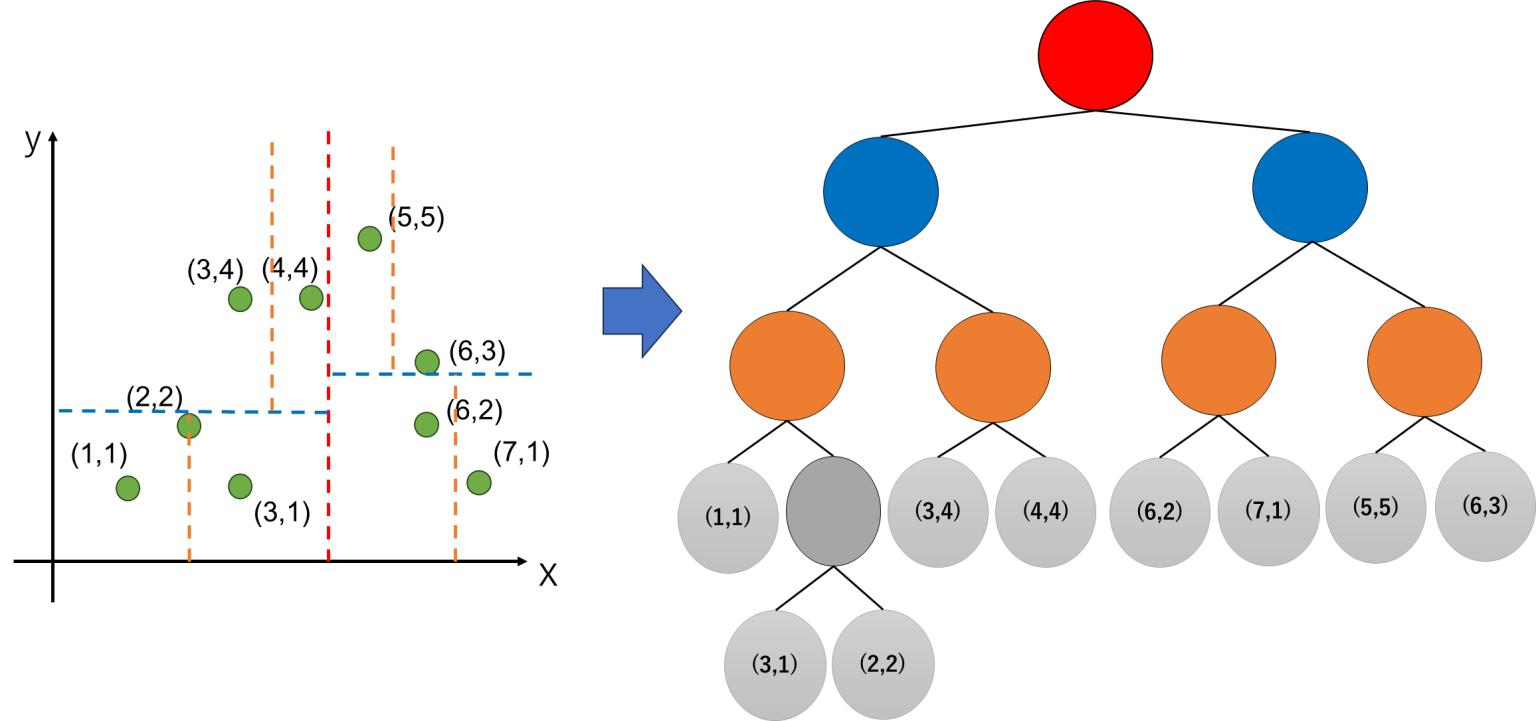

2.  **Ball Trees:**
    *   **Concept:** Similar to KD-Trees, Ball Trees are another space-partitioning data structure designed for efficient nearest neighbor searches. Instead of hyperrectangles, Ball Trees partition data points into nested hyperspheres (or 'balls'). Each node in the tree defines a hypersphere containing all the points in its subtree.
    *   **How it helps Lazy Learning:** When searching for neighbors, if the query point is outside a hypersphere or the distance to the query point is greater than the radius of the current best neighbor found, the entire subtree corresponding to that hypersphere can be ignored. This offers efficient pruning.
    *   **Benefit:** Often performs better than KD-Trees in higher-dimensional spaces and for datasets with complex distributions, as hyperspheres can sometimes enclose data more naturally than axis-aligned hyperrectangles.
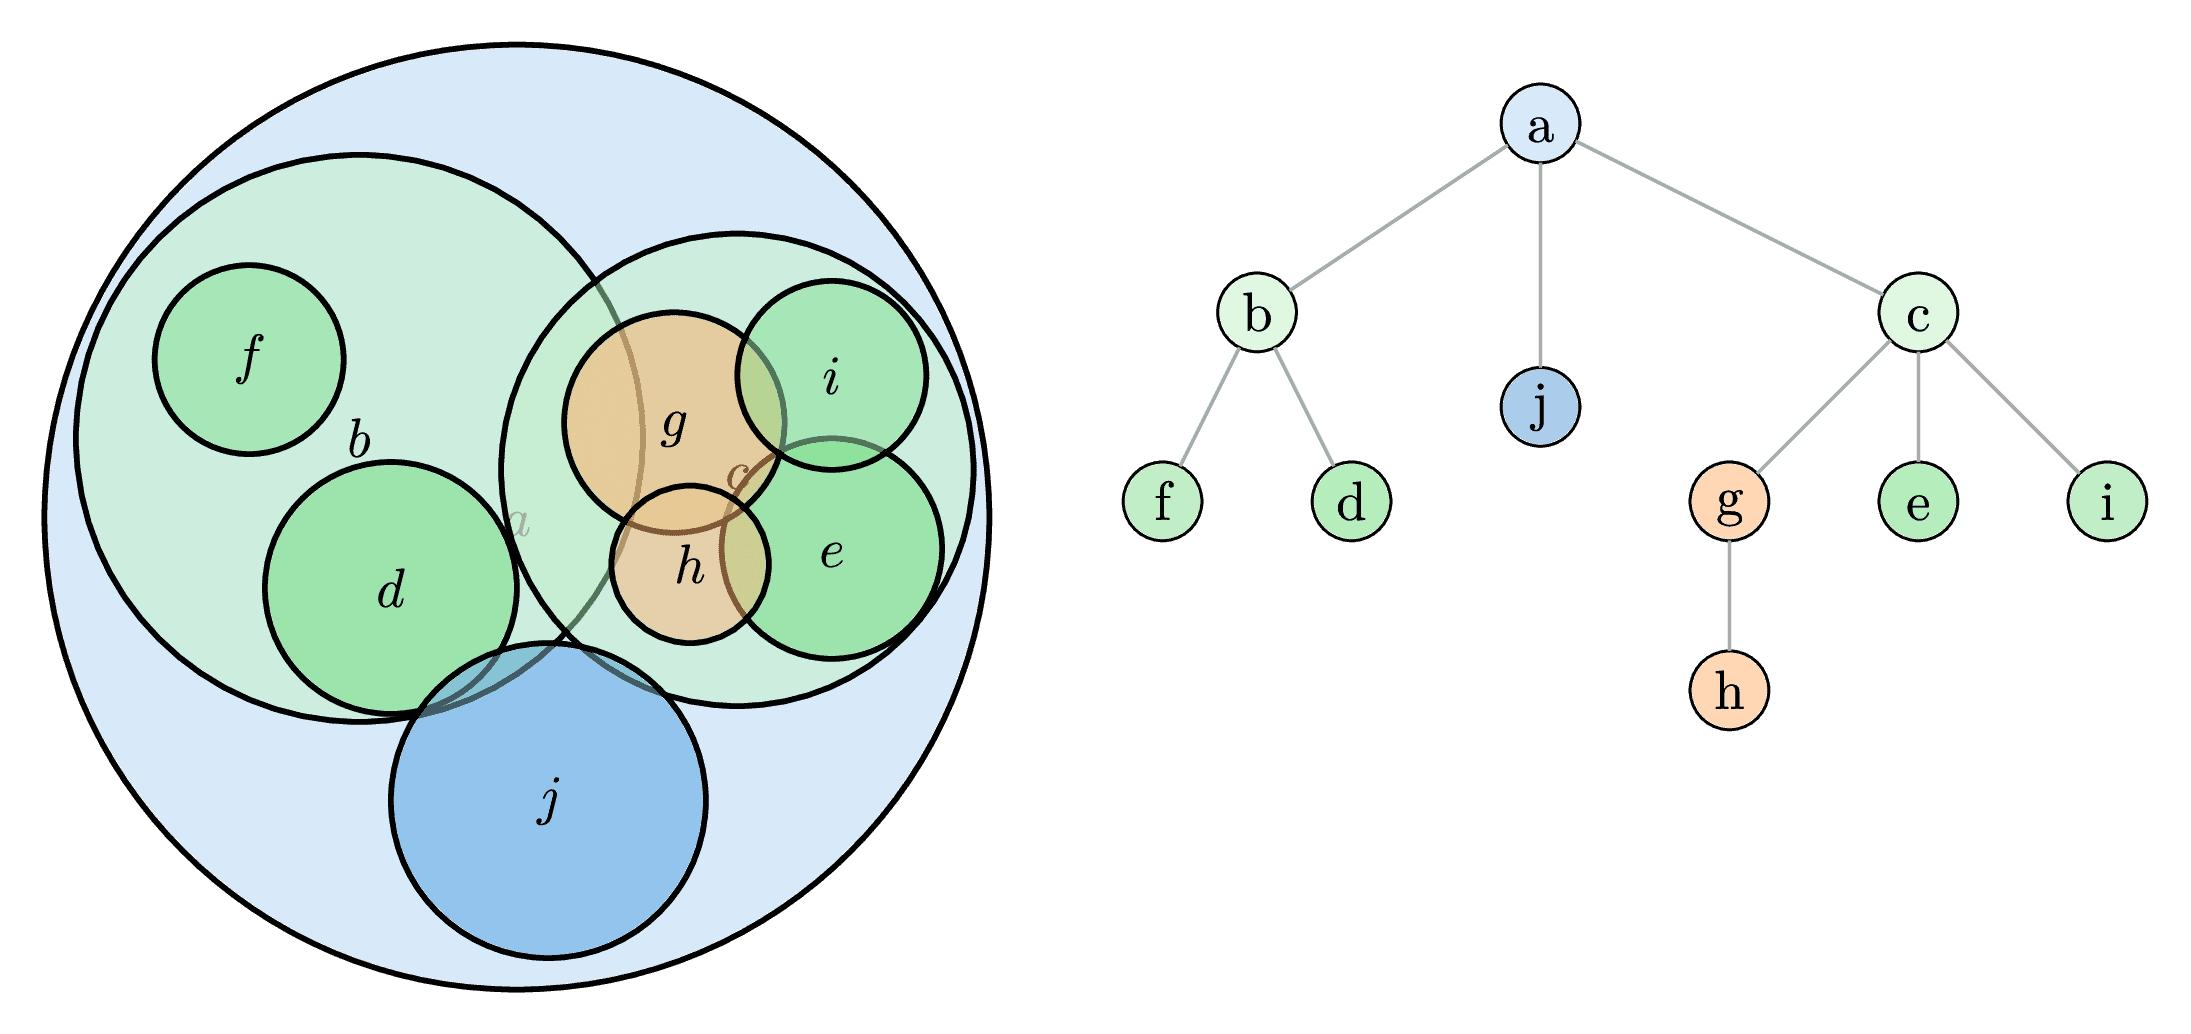


#### B. Weighted Lazy Learning (e.g., Weighted KNN)

*   **Concept:** As discussed in KNN extensions, this enhancement assigns different weights to neighbors based on their proximity to the query point. Closer neighbors contribute more significantly to the prediction than farther ones.
*   **How it helps Lazy Learning:** Improves prediction accuracy by making the local approximation more sensitive to the most relevant instances, effectively reducing the influence of potentially noisy or less representative distant neighbors.

#### C. Feature Selection and Dimensionality Reduction

*   **Why Needed:** Lazy learners are highly susceptible to the Curse of Dimensionality and irrelevant features. Reducing the number of dimensions or selecting the most informative features can dramatically improve performance.
*   **How it helps Lazy Learning:**
    *   **Reduces Memory:** Fewer features mean less data to store.
    *   **Speeds up Distance Calculation:** Distances are computed over fewer dimensions.
    *   **Improves Distance Meaningfulness:** By removing noise and redundancy, distances become more accurate reflections of similarity, making neighbor selection more reliable.

#### D. Locally Weighted Learning (LWL) / Locally Weighted Regression (LWR)

*   **Concept:** A generalization of lazy learning where, instead of just taking a simple majority vote or average, a *local model* (e.g., a local linear regression) is fit to the neighbors of the query point. The data points are weighted by their distance to the query point, giving more importance to closer points.
*   **How it helps Lazy Learning:** Can provide more sophisticated and accurate local approximations than simple averaging, especially for regression tasks, by capturing local trends more effectively.

These extensions transform basic lazy learning algorithms into more robust and efficient tools, making them applicable to a wider range of real-world problems despite their inherent 'laziness'.

## 3. Distance Metrics

Distance metrics are fundamental to many machine learning algorithms, especially instance-based learning methods like K-Nearest Neighbors (KNN) and clustering algorithms. They quantify the 'dissimilarity' or 'distance' between two data points in a feature space. The choice of distance metric can significantly impact the performance and interpretation of these algorithms.

### 1. Why We Need Distance Metrics

Distance metrics are indispensable in machine learning for several key reasons, especially in algorithms that rely on the concept of 'similarity' or 'proximity' between data points:

1.  **Foundation for Similarity/Dissimilarity:**
    *   **Explanation:** At its core, a distance metric provides a quantitative measure of how 'far apart' or 'different' two data points are. In machine learning, this often translates directly to how similar or dissimilar two instances are, which is a foundational concept for many tasks. If points are 'close', they are considered similar; if 'far', they are dissimilar.

2.  **Core of Instance-Based Learning (e.g., KNN):**
    *   **Explanation:** Algorithms like K-Nearest Neighbors (KNN) make predictions based on the labels or values of the *closest* training examples to a new, unseen data point. Without a robust way to define 'closest' (i.e., a distance metric), these algorithms simply cannot function. The metric determines which neighbors are considered relevant.

3.  **Clustering Algorithms:**
    *   **Explanation:** Unsupervised learning techniques like K-Means clustering aim to group similar data points together. 'Similarity' in this context is almost exclusively defined by a distance metric. Points that are closer to each other (according to the chosen metric) are more likely to belong to the same cluster.

4.  **Anomaly Detection:**
    *   **Explanation:** In anomaly detection, data points that are significantly far from the majority of other data points are often flagged as anomalies or outliers. Distance metrics are used to quantify this 'outlierness'.

5.  **Recommender Systems:**
    *   **Explanation:** Recommender systems often suggest items to users based on the similarity between users or items. Distance metrics help determine how similar two users' preferences are or how similar two items are in terms of their features or user ratings.

6.  **Feature Selection and Engineering:**
    *   **Explanation:** Distance metrics can be used in feature selection to identify features that are highly correlated or redundant (by measuring the distance between feature vectors). They can also be used in feature engineering to create new features that capture specific relationships or properties.

7.  **Data Preprocessing (e.g., Scaling):**
    *   **Explanation:** The sensitivity of many distance metrics to the scale of features necessitates preprocessing steps like feature scaling. Understanding how a metric works helps in deciding whether and how to scale data to prevent certain features from dominating the distance calculation.

8.  **Understanding Data Structure:**
    *   **Explanation:** By visualizing data in lower dimensions (e.g., using PCA or t-SNE, which implicitly or explicitly deal with distances), distance metrics help in understanding the underlying structure, density, and relationships within a dataset.

9.  **Robustness to Different Data Types:**
    *   **Explanation:** Different types of data (numerical, categorical, textual, binary) require different ways of quantifying distance. A variety of metrics have been developed to handle these diverse data types effectively.

10. **Model Evaluation:**
    *   **Explanation:** In some cases, distance metrics can be used in evaluating model performance, particularly in regression tasks where metrics like Root Mean Squared Error (RMSE) are essentially a form of distance between predicted and actual values.

### 2. Definition of Distance Metrics

A **distance metric** (or distance function) is a mathematical function that defines a measure of 'distance' or 'dissimilarity' between two points in a space. In the context of machine learning and data analysis, this space is typically the feature space, and the points are data instances or vectors.

#### A. Formal Definition:
A function $d(a, b)$ is a distance metric if it satisfies the following four properties for any points $a, b, c$ in the space:

1.  **Non-negativity (or Positivity):** $d(a, b) \ge 0$
    *   The distance between any two points must be greater than or equal to zero. It cannot be negative.

2.  **Identity of Indiscernibles:** $d(a, b) = 0 \iff a = b$
    *   The distance between two points is zero if and only if the points are identical. If two points are the same, their distance is zero; conversely, if their distance is zero, they must be the same point.

3.  **Symmetry:** $d(a, b) = d(b, a)$
    *   The distance from point $a$ to point $b$ is the same as the distance from point $b$ to point $a$. The order of the points does not affect the distance.

4.  **Triangle Inequality:** $d(a, c) \le d(a, b) + d(b, c)$
    *   The direct distance between two points is always less than or equal to the sum of the distances via any third point. This property ensures that 'going around' does not create a shorter path than going directly.

#### B. Metric vs. Pseudo-metric vs. Similarity Measure:

It's important to distinguish between related terms:

*   **Metric (Distance Metric):** A function that satisfies all four properties listed above. Examples include Euclidean distance, Manhattan distance.

*   **Pseudo-metric:** A function that satisfies non-negativity, symmetry, and triangle inequality, but *not* necessarily the identity of indiscernibles. That is, $d(a, b) = 0$ does not necessarily imply $a = b$. For instance, if two distinct points have identical feature values in a particular representation, their distance might be 0 according to a pseudo-metric. While technically distinct, in many ML contexts, 'distance metric' is used loosely to include pseudo-metrics if the context implies identical points are truly indistinguishable.

*   **Similarity Measure:** Often the inverse or complement of a distance metric. Instead of quantifying 'dissimilarity', it quantifies 'similarity'. Higher values mean more similarity. For example, cosine similarity is a common similarity measure. It can often be converted into a distance metric (e.g., Cosine Distance = 1 - Cosine Similarity) if it satisfies the metric properties after transformation.

#### C. Role in Machine Learning:

In machine learning, the choice of distance metric directly influences how the algorithm perceives the relationships between data points. It dictates the shape of decision boundaries in instance-based classifiers like KNN, and the formation of clusters in algorithms like K-Means. Different metrics are sensitive to different aspects of the data (e.g., Euclidean distance is sensitive to magnitude differences, while cosine similarity is sensitive to orientation).

### 3. Intuition Behind Distance Metrics

The intuition behind distance metrics is deeply rooted in our everyday understanding of 'closeness' or 'difference'. In machine learning, this intuition is formalized to quantify how similar or dissimilar two data points are in a multi-dimensional feature space.

#### A. Geographic Analogy: How Far Apart Are Two Locations?

Imagine you want to describe how 'far' two places are from each other. Your answer depends on how you measure 'distance':

*   **As the crow flies (Euclidean Distance):** This is the most direct, straight-line path. It's how a bird would fly, ignoring roads, buildings, or natural barriers. In data, this represents the shortest possible distance in a continuous space.
    *   **Intuition:** If features represent continuous properties (e.g., temperature, height), Euclidean distance captures the overall dissimilarity considering all dimensions equally.

*   **Driving distance (Manhattan Distance):** If you're driving in a city with a grid-like street plan, you can't go 'as the crow flies'. You have to follow the streets, moving horizontally and vertically. The distance is the sum of movements along each axis.
    *   **Intuition:** Useful when movement is constrained to axes, or when individual feature differences are more important than their combined squared effect (e.g., in gene expression, where each gene's deviation contributes independently).

*   **Road network distance (More complex metrics):** Sometimes, the shortest path isn't a straight line or grid-like, but involves complex turns and roads, even considering traffic. This is a more abstract concept but highlights that 'distance' can be defined in many ways depending on the 'cost' of travel.

#### B. Similarity as Proximity in Feature Space

At its core, the intuition is: **If two data points are 'close' in the feature space, they are likely to be similar in their underlying characteristics.** Conversely, if they are 'far apart', they are dissimilar.

Consider our fruit example with `Sweetness` and `Crunchiness`:

*   An apple (high sweetness, high crunchiness) and a pear (moderate sweetness, moderate crunchiness) would be relatively 'close' in this 2D feature space, indicating they are similar fruits.
*   An apple and a lemon (low sweetness, low crunchiness) would be 'far apart', indicating dissimilarity.

#### C. How Different Metrics Capture Different Aspects of Similarity:

*   **Magnitude-Sensitive Metrics (e.g., Euclidean, Manhattan, Minkowski):** These metrics are intuitive when the *absolute difference* or *scale* of features matters. A large difference in one feature contributes significantly to the overall distance. They quantify how far apart points are in terms of their raw feature values.
    *   **Visual Intuition:** These metrics define 'spheres' (Euclidean) or 'diamonds' (Manhattan) around a point, where everything inside is considered 'close'.

*   **Orientation-Sensitive Metrics (e.g., Cosine Similarity/Distance):** Sometimes, the *direction* or *pattern* of the features is more important than their raw magnitude. For example, two documents might talk about the same topic (same word patterns/frequencies) but one is much longer (larger magnitude of word counts). Cosine similarity would deem them very similar because their 'topic vectors' point in the same direction.
    *   **Visual Intuition:** Cosine similarity measures the angle between two vectors. A small angle means they are very similar, regardless of how long the vectors are (their magnitude).

#### D. The Importance of Context:

The intuition for choosing a distance metric often comes down to understanding what 'similarity' means for the specific problem and data. Are absolute differences critical? Or is the proportional relationship and direction more important? Does one feature's difference dominate the others? The chosen metric should align with this domain-specific understanding of similarity.

### 4. Math Behind Distance Metrics

The mathematical foundation of distance metrics is rooted in abstract algebra and topology, particularly in the concept of a **metric space**. A distance metric (or metric function) formally defines what it means for points in a set to be 'close' or 'far apart'. This section delves into the general mathematical principles without yet specifying particular formulas for common metrics.

#### A. Metric Space

A **metric space** is an ordered pair $(M, d)$, where $M$ is a set (e.g., our feature space of data points) and $d$ is a function $d: M \times M \to \mathbb{R}$ called a **metric** or **distance function**, which satisfies the following four properties for all $x, y, z \in M$:

1.  **Non-negativity (or Positivity):** $d(x, y) \ge 0$
    *   The distance between any two points is always non-negative. It's either zero or a positive real number.

2.  **Identity of Indiscernibles:** $d(x, y) = 0 \iff x = y$
    *   The distance between two points is zero if and only if the points are identical. This means distinct points must have a positive distance between them.

3.  **Symmetry:** $d(x, y) = d(y, x)$
    *   The distance from point $x$ to point $y$ is the same as the distance from point $y$ to point $x$. The direction of measurement does not affect the distance.

4.  **Triangle Inequality:** $d(x, z) \le d(x, y) + d(y, z)$
    *   The direct distance between two points ($x$ to $z$) is always less than or equal to the sum of the distances obtained by passing through a third point ($x$ to $y$ then $y$ to $z$). This ensures that 'going around' does not create a shorter path than going directly.

These four axioms are crucial because they ensure that the 'distance' behaves in a way that aligns with our intuitive understanding of physical distance, making it suitable for quantifying dissimilarity in data.

#### B. Norms and Distance

Many common distance metrics are derived from a mathematical concept called a **norm**. A norm is a function that assigns a strictly positive length or size to each vector in a vector space (except for the zero vector). If $||v||$ denotes the norm of a vector $v$, then the distance between two points (vectors) $x$ and $y$ can often be defined as the norm of their difference: $d(x, y) = ||x - y||$.

*   **Vector Space:** In machine learning, our data points are typically vectors in a multi-dimensional feature space. This space is a vector space, meaning we can add vectors and multiply them by scalars, and these operations follow certain rules.

*   **Properties of a Norm:** A function $||\cdot||$ is a norm if for any vectors $u, v$ and scalar $\alpha$:
    1.  $||u|| \ge 0$ (Non-negativity)
    2.  $||u|| = 0 \iff u = 0$ (Definiteness)
    3.  $||\alpha u|| = |\alpha| ||u||$ (Homogeneity)
    4.  $||u + v|| \le ||u|| + ||v||$ (Triangle Inequality)

If a distance function is derived from a norm ($d(x, y) = ||x - y||$), it will automatically satisfy the four metric properties (non-negativity, identity of indiscernibles, symmetry, and triangle inequality).

#### C. Inner Products and Angles (for Cosine Similarity)

For metrics like Cosine Similarity (and thus Cosine Distance), the underlying mathematical concept is the **inner product** (or dot product) of vectors. The inner product provides a way to multiply two vectors to get a scalar, and it is closely related to the angle between the vectors.

*   **Inner Product:** For two vectors $u = (u_1, ..., u_n)$ and $v = (v_1, ..., v_n)$, their inner product is $u \cdot v = \sum_{i=1}^n u_i v_i$.

*   **Angle:** The cosine of the angle $\theta$ between two non-zero vectors $u$ and $v$ is given by:
    $\cos(\theta) = \frac{u \cdot v}{||u|| \cdot ||v||}$

This relationship forms the basis for cosine similarity, which measures similarity based on the orientation of vectors rather than their magnitude. The resulting cosine distance ($1 - \text{cosine similarity}$) also adheres to the properties of a metric under certain conditions.

Understanding these mathematical underpinnings ensures that the distance functions we use are robust and consistent for quantifying similarity in high-dimensional data.

### 5. Formulas for Common Distance Metrics

Having covered the mathematical foundations, let's now look at the specific formulas for the most commonly used distance metrics in machine learning. These formulas quantify the 'dissimilarity' between two data points $P_1$ and $P_2$ in an $n$-dimensional feature space.

Let two data points be $P_1 = (x_{1,1}, x_{1,2}, ..., x_{1,n})$ and $P_2 = (x_{2,1}, x_{2,2}, ..., x_{2,n})$.

#### A. Euclidean Distance (L2 Norm)

This is the most widely used distance metric. It measures the shortest straight-line distance between two points in a Euclidean space. It is the special case of Minkowski distance where $p=2$.

**Formula:**

$$d_{\text{Euclidean}}(P_1, P_2) = \sqrt{\sum_{i=1}^{n} (x_{1,i} - x_{2,i})^2}$$

*   **Interpretation:** Represents the 'as the crow flies' distance.

#### B. Manhattan Distance (L1 Norm or Taxicab Distance)

Also known as L1 norm, city block distance, or taxicab distance, it calculates the sum of the absolute differences between the coordinates of the two points along each dimension. It is the special case of Minkowski distance where $p=1$.

**Formula:**

$$d_{\text{Manhattan}}(P_1, P_2) = \sum_{i=1}^{n} |x_{1,i} - x_{2,i}|$$

*   **Interpretation:** Represents the distance a taxi would travel on a grid-like city plan.

#### C. Minkowski Distance (Lp Norm)

The Minkowski distance is a generalized metric that encompasses both Euclidean and Manhattan distances as special cases. It is parameterized by a value $p \ge 1$.

**Formula:**

$$d_{\text{Minkowski}}(P_1, P_2) = \left( \sum_{i=1}^{n} |x_{1,i} - x_{2,i}|^p \right)^{1/p}$$

*   **Special Cases:**
    *   When $p=1$, it becomes the Manhattan distance.
    *   When $p=2$, it becomes the Euclidean distance.
    *   As $p \to \infty$, it approaches the Chebyshev distance (L$\infty$ norm), which is the maximum absolute difference between any coordinate: $d_{\text{Chebyshev}}(P_1, P_2) = \max_{i} |x_{1,i} - x_{2,i}|$.

#### D. Cosine Similarity and Cosine Distance

Cosine similarity measures the cosine of the angle between two non-zero vectors. It indicates whether two vectors are pointing in roughly the same direction, making it useful when the magnitude of the vectors doesn't matter, but their orientation does (e.g., document similarity in NLP).

**Formula (Cosine Similarity):**

$$\text{similarity}(P_1, P_2) = \frac{P_1 \cdot P_2}{||P_1|| \cdot ||P_2||} = \frac{\sum_{i=1}^{n} (x_{1,i} \cdot x_{2,i})}{\sqrt{\sum_{i=1}^{n} x_{1,i}^2} \cdot \sqrt{\sum_{i=1}^{n} x_{2,i}^2}}$$

**Formula (Cosine Distance):**

To convert cosine similarity into a distance measure that satisfies metric properties (especially non-negativity and identity of indiscernibles), it's typically defined as:

$$d_{\text{Cosine}}(P_1, P_2) = 1 - \text{similarity}(P_1, P_2)$$

*   **Interpretation:** A similarity of 1 means identical direction (angle 0°), distance 0. A similarity of 0 means orthogonal (angle 90°), distance 1. A similarity of -1 means opposite direction (angle 180°), distance 2.

#### E. Hamming Distance

While the above metrics are primarily for continuous numerical data, the Hamming distance is used for comparing two binary strings or categorical vectors of equal length.

**Formula:**

$$d_{\text{Hamming}}(P_1, P_2) = \sum_{i=1}^{n} I(x_{1,i} \ne x_{2,i})$$

Where $I(\cdot)$ is the indicator function, returning 1 if the values $x_{1,i}$ and $x_{2,i}$ are different, and 0 if they are the same.

*   **Interpretation:** Counts the number of positions at which the corresponding symbols are different.

### 6. Numerical Example of Distance Metrics

To solidify our understanding of the different distance metrics, let's calculate the distances between a few points in a 2-dimensional feature space using Euclidean, Manhattan, and Cosine distances.

**Given three points:**
*   $P_1 = (1, 5)$ (e.g., a data point with feature values 1 and 5)
*   $P_2 = (4, 1)$ (e.g., another data point with feature values 4 and 1)
*   $P_3 = (2, 10)$ (e.g., a data point with higher values)

#### A. Calculate Euclidean Distance

**Formula:** $d_{\text{Euclidean}}(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}$

1.  **$d_{\text{Euclidean}}(P_1, P_2)$:**
    *   $(1-4)^2 + (5-1)^2 = (-3)^2 + (4)^2 = 9 + 16 = 25$
    *   $d_{\text{Euclidean}}(P_1, P_2) = \sqrt{25} = 5$

2.  **$d_{\text{Euclidean}}(P_1, P_3)$:**
    *   $(1-2)^2 + (5-10)^2 = (-1)^2 + (-5)^2 = 1 + 25 = 26$
    *   $d_{\text{Euclidean}}(P_1, P_3) = \sqrt{26} \approx 5.099$

3.  **$d_{\text{Euclidean}}(P_2, P_3)$:**
    *   $(4-2)^2 + (1-10)^2 = (2)^2 + (-9)^2 = 4 + 81 = 85
    *   $d_{\text{Euclidean}}(P_2, P_3) = \sqrt{85} \approx 9.220$

#### B. Calculate Manhattan Distance

**Formula:** $d_{\text{Manhattan}}(A, B) = \sum_{i=1}^{n} |A_i - B_i|$

1.  **$d_{\text{Manhattan}}(P_1, P_2)$:**
    *   $|1-4| + |5-1| = |-3| + |4| = 3 + 4 = 7$

2.  **$d_{\text{Manhattan}}(P_1, P_3)$:**
    *   $|1-2| + |5-10| = |-1| + |-5| = 1 + 5 = 6$

3.  **$d_{\text{Manhattan}}(P_2, P_3)$:**
    *   $|4-2| + |1-10| = |2| + |-9| = 2 + 9 = 11$

#### C. Calculate Cosine Similarity and Cosine Distance

**Formula (Similarity):** $\text{similarity}(A, B) = \frac{A \cdot B}{||A|| \cdot ||B||}$

**Formula (Distance):** $d_{\text{Cosine}}(A, B) = 1 - \text{similarity}(A, B)$

First, calculate the magnitude (L2 norm) for each point:
*   $||P_1|| = \sqrt{1^2 + 5^2} = \sqrt{1 + 25} = \sqrt{26} \approx 5.099$
*   $||P_2|| = \sqrt{4^2 + 1^2} = \sqrt{16 + 1} = \sqrt{17} \approx 4.123$
*   $||P_3|| = \sqrt{2^2 + 10^2} = \sqrt{4 + 100} = \sqrt{104} \approx 10.198$

Now, calculate dot products and similarities:

1.  **$P_1 \cdot P_2 = (1)(4) + (5)(1) = 4 + 5 = 9$**
    *   $\text{similarity}(P_1, P_2) = \frac{9}{\sqrt{26} \cdot \sqrt{17}} = \frac{9}{5.099 \cdot 4.123} \approx \frac{9}{21.01} \approx 0.428$
    *   $d_{\text{Cosine}}(P_1, P_2) = 1 - 0.428 = 0.572$

2.  **$P_1 \cdot P_3 = (1)(2) + (5)(10) = 2 + 50 = 52$**
    *   $\text{similarity}(P_1, P_3) = \frac{52}{\sqrt{26} \cdot \sqrt{104}} = \frac{52}{5.099 \cdot 10.198} \approx \frac{52}{51.99} \approx 1.000$
    *   $d_{\text{Cosine}}(P_1, P_3) = 1 - 1.000 = 0$
    *   *Note: P1 and P3 are scalar multiples of each other, (2,10) is (2*1, 2*5). They point in the exact same direction, hence cosine similarity is 1 and cosine distance is 0.* This highlights that cosine distance only cares about the angle, not magnitude.

3.  **$P_2 \cdot P_3 = (4)(2) + (1)(10) = 8 + 10 = 18$**
    *   $\text{similarity}(P_2, P_3) = \frac{18}{\sqrt{17} \cdot \sqrt{104}} = \frac{18}{4.123 \cdot 10.198} \approx \frac{18}{42.04} \approx 0.428$
    *   $d_{\text{Cosine}}(P_2, P_3) = 1 - 0.428 = 0.572$

#### D. Summary of Distances

| Pair      | Euclidean Distance | Manhattan Distance | Cosine Distance | Cosine Similarity |
| :-------- | :----------------- | :----------------- | :-------------- | :---------------- |
| $P_1, P_2$ | 5                  | 7                  | 0.572           | 0.428             |
| $P_1, P_3$ | 5.099              | 6                  | 0               | 1                 |
| $P_2, P_3$ | 9.220              | 11                 | 0.572           | 0.428             |

This example clearly shows how different metrics yield different 'distances' and thus different interpretations of similarity between the same pair of points. For instance, $P_1$ and $P_3$ are very close by Manhattan distance and identical by Cosine distance (same direction), but have a moderate Euclidean distance due to the difference in magnitude.

### 7. Python Code to Explain Distance Metrics

Let's implement the common distance metrics in Python to see how they work with our numerical example. We will use `numpy` for efficient array operations and `scipy.spatial.distance` for highly optimized versions of these metrics.

First, let's define our points using `numpy` arrays, which is standard practice in numerical computing with Python.

In [4]:
import numpy as np
from scipy.spatial import distance

# Define our points as numpy arrays
P1 = np.array([1, 5])
P2 = np.array([4, 1])
P3 = np.array([2, 10])

print(f"P1: {P1}")
print(f"P2: {P2}")
print(f"P3: {P3}")

P1: [1 5]
P2: [4 1]
P3: [ 2 10]


#### A. Euclidean Distance (L2 Norm)

We can implement it manually or use `scipy.spatial.distance.euclidean`.

In [5]:
# Manual implementation for demonstration
def calculate_euclidean(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

# Using our manual function
d_euclidean_P1P2_manual = calculate_euclidean(P1, P2)
d_euclidean_P1P3_manual = calculate_euclidean(P1, P3)
d_euclidean_P2P3_manual = calculate_euclidean(P2, P3)

# Using scipy's function for verification
d_euclidean_P1P2_scipy = distance.euclidean(P1, P2)
d_euclidean_P1P3_scipy = distance.euclidean(P1, P3)
d_euclidean_P2P3_scipy = distance.euclidean(P2, P3)

print(f"Euclidean Distance (P1, P2): {d_euclidean_P1P2_manual:.3f} (Manual) / {d_euclidean_P1P2_scipy:.3f} (SciPy)")
print(f"Euclidean Distance (P1, P3): {d_euclidean_P1P3_manual:.3f} (Manual) / {d_euclidean_P1P3_scipy:.3f} (SciPy)")
print(f"Euclidean Distance (P2, P3): {d_euclidean_P2P3_manual:.3f} (Manual) / {d_euclidean_P2P3_scipy:.3f} (SciPy)")

Euclidean Distance (P1, P2): 5.000 (Manual) / 5.000 (SciPy)
Euclidean Distance (P1, P3): 5.099 (Manual) / 5.099 (SciPy)
Euclidean Distance (P2, P3): 9.220 (Manual) / 9.220 (SciPy)


#### B. Manhattan Distance (L1 Norm)

Similarly, we can implement Manhattan distance manually or use `scipy.spatial.distance.cityblock`.

In [6]:
# Manual implementation for demonstration
def calculate_manhattan(point1, point2):
    return np.sum(np.abs(point1 - point2))

# Using our manual function
d_manhattan_P1P2_manual = calculate_manhattan(P1, P2)
d_manhattan_P1P3_manual = calculate_manhattan(P1, P3)
d_manhattan_P2P3_manual = calculate_manhattan(P2, P3)

# Using scipy's function for verification
d_manhattan_P1P2_scipy = distance.cityblock(P1, P2)
d_manhattan_P1P3_scipy = distance.cityblock(P1, P3)
d_manhattan_P2P3_scipy = distance.cityblock(P2, P3)

print(f"Manhattan Distance (P1, P2): {d_manhattan_P1P2_manual:.3f} (Manual) / {d_manhattan_P1P2_scipy:.3f} (SciPy)")
print(f"Manhattan Distance (P1, P3): {d_manhattan_P1P3_manual:.3f} (Manual) / {d_manhattan_P1P3_scipy:.3f} (SciPy)")
print(f"Manhattan Distance (P2, P3): {d_manhattan_P2P3_manual:.3f} (Manual) / {d_manhattan_P2P3_scipy:.3f} (SciPy)")

Manhattan Distance (P1, P2): 7.000 (Manual) / 7.000 (SciPy)
Manhattan Distance (P1, P3): 6.000 (Manual) / 6.000 (SciPy)
Manhattan Distance (P2, P3): 11.000 (Manual) / 11.000 (SciPy)


#### C. Minkowski Distance (Lp Norm)

Minkowski distance is a generalization. `scipy.spatial.distance.minkowski` allows us to specify the `p` parameter.

In [7]:
# p=1 is Manhattan
d_minkowski_P1P2_p1 = distance.minkowski(P1, P2, p=1)
print(f"Minkowski Distance (P1, P2, p=1): {d_minkowski_P1P2_p1:.3f} (matches Manhattan)")

# p=2 is Euclidean
d_minkowski_P1P2_p2 = distance.minkowski(P1, P2, p=2)
print(f"Minkowski Distance (P1, P2, p=2): {d_minkowski_P1P2_p2:.3f} (matches Euclidean)")

# Example with p=3
d_minkowski_P1P2_p3 = distance.minkowski(P1, P2, p=3)
print(f"Minkowski Distance (P1, P2, p=3): {d_minkowski_P1P2_p3:.3f}")

Minkowski Distance (P1, P2, p=1): 7.000 (matches Manhattan)
Minkowski Distance (P1, P2, p=2): 5.000 (matches Euclidean)
Minkowski Distance (P1, P2, p=3): 4.498


#### D. Cosine Similarity and Cosine Distance

We can calculate these using `numpy.dot` for the dot product and `numpy.linalg.norm` for the magnitude, or use `scipy.spatial.distance.cosine`.

In [8]:
# Manual implementation for demonstration
def calculate_cosine_similarity(point1, point2):
    dot_product = np.dot(point1, point2)
    norm_point1 = np.linalg.norm(point1)
    norm_point2 = np.linalg.norm(point2)
    return dot_product / (norm_point1 * norm_point2)

def calculate_cosine_distance(point1, point2):
    return 1 - calculate_cosine_similarity(point1, point2)

# Using our manual functions
s_cosine_P1P2_manual = calculate_cosine_similarity(P1, P2)
d_cosine_P1P2_manual = calculate_cosine_distance(P1, P2)
s_cosine_P1P3_manual = calculate_cosine_similarity(P1, P3)
d_cosine_P1P3_manual = calculate_cosine_distance(P1, P3)
s_cosine_P2P3_manual = calculate_cosine_similarity(P2, P3)
d_cosine_P2P3_manual = calculate_cosine_distance(P2, P3)

# Using scipy's function for verification (SciPy's cosine returns distance directly)
d_cosine_P1P2_scipy = distance.cosine(P1, P2)
d_cosine_P1P3_scipy = distance.cosine(P1, P3)
d_cosine_P2P3_scipy = distance.cosine(P2, P3)

print(f"Cosine Similarity (P1, P2): {s_cosine_P1P2_manual:.3f}")
print(f"Cosine Distance (P1, P2): {d_cosine_P1P2_manual:.3f} (Manual) / {d_cosine_P1P2_scipy:.3f} (SciPy)")

print(f"\nCosine Similarity (P1, P3): {s_cosine_P1P3_manual:.3f}")
print(f"Cosine Distance (P1, P3): {d_cosine_P1P3_manual:.3f} (Manual) / {d_cosine_P1P3_scipy:.3f} (SciPy)")

print(f"\nCosine Similarity (P2, P3): {s_cosine_P2P3_manual:.3f}")
print(f"Cosine Distance (P2, P3): {d_cosine_P2P3_manual:.3f} (Manual) / {d_cosine_P2P3_scipy:.3f} (SciPy)")

Cosine Similarity (P1, P2): 0.428
Cosine Distance (P1, P2): 0.572 (Manual) / 0.572 (SciPy)

Cosine Similarity (P1, P3): 1.000
Cosine Distance (P1, P3): -0.000 (Manual) / 0.000 (SciPy)

Cosine Similarity (P2, P3): 0.428
Cosine Distance (P2, P3): 0.572 (Manual) / 0.572 (SciPy)


### 8. Pros and Cons of Distance Metrics

The choice of distance metric is crucial in many machine learning algorithms, particularly in instance-based learning (like KNN) and clustering. Different metrics have their own strengths and weaknesses, making them suitable for different types of data and problems.

#### A. Pros and Cons of Euclidean Distance

*   **Pros:**
    1.  **Intuitive and Widely Understood:** It directly corresponds to our everyday understanding of physical distance, making it easy to grasp.
    2.  **Mathematically Sound:** Satisfies all four metric properties (non-negativity, identity of indiscernibles, symmetry, triangle inequality).
    3.  **Good for General-Purpose:** A reasonable default choice for many continuous, numerical datasets where feature magnitudes are important.
    4.  **Isotropic Data:** Works well when data is uniformly distributed in all directions.

*   **Cons:**
    1.  **Sensitive to Feature Scale:** Features with larger numerical ranges can disproportionately dominate the distance calculation, even if they are less important. Requires feature scaling (normalization or standardization).
    2.  **Curse of Dimensionality:** In high-dimensional spaces, the concept of 'distance' becomes less meaningful. All points tend to become equidistant from each other, making neighbor identification less reliable.
    3.  **Sensitive to Outliers:** Outliers can heavily influence the distance, potentially pulling neighbors away or towards incorrect clusters/classes.
    4.  **Ignores Feature Correlation:** Assumes features are independent, which might not be true in real-world data.

#### B. Pros and Cons of Manhattan Distance (City Block/L1 Norm)

*   **Pros:**
    1.  **Less Sensitive to Outliers:** Unlike Euclidean, the absolute difference (rather than squared difference) makes it less affected by large deviations in a single dimension.
    2.  **Good for High-Dimensionality:** Tends to perform better than Euclidean distance in very high-dimensional spaces when dealing with the curse of dimensionality, as it provides a more robust measure of difference.
    3.  **Works well with Grid-like Paths:** Suitable for scenarios where movement is restricted to axis-parallel directions.
    4.  **Good for Mixed Data Types:** Can sometimes be more appropriate when dealing with a mixture of continuous and discrete features (though Gower distance is often better for this).

*   **Cons:**
    1.  **Less Intuitive for 'Direct' Paths:** Does not represent the shortest path between two points in continuous space.
    2.  **Sensitive to Feature Scale:** Still requires feature scaling, similar to Euclidean distance.
    3.  **Can be Biased:** If feature axes are not equally important or aligned with natural directions of variation, it might be less effective.

#### C. Pros and Cons of Minkowski Distance

*   **Pros:**
    1.  **Generalization:** Provides a flexible framework that includes both Euclidean ($p=2$) and Manhattan ($p=1$) distances as special cases.
    2.  **Tunable:** The parameter `p` allows for fine-tuning the sensitivity to larger vs. smaller differences, offering an additional hyperparameter for optimization.

*   **Cons:**
    1.  **Choosing `p`:** Requires careful selection of the parameter `p`, which can be data-dependent and add complexity to model tuning.
    2.  **Shares Limitations:** Inherits the sensitivity to feature scaling and curse of dimensionality issues from its special cases.

#### D. Pros and Cons of Cosine Similarity / Cosine Distance

*   **Pros:**
    1.  **Magnitude Invariance:** Highly effective when the orientation of vectors is more important than their magnitude. This is crucial for text analysis, document similarity, or recommendation systems where document length or user rating scale might vary but the underlying topic/preference pattern is key.
    2.  **Effective in High Dimensions:** Often performs well in high-dimensional sparse data, as it focuses on the directionality rather than raw values.
    3.  **Normalization Built-in:** The division by the product of vector magnitudes effectively normalizes the vectors, reducing the need for explicit feature scaling in some contexts.

*   **Cons:**
    1.  **Not a True Metric (Similarity):** Cosine *similarity* is not a metric, as it violates the identity of indiscernibles (e.g., `(1,1)` and `(2,2)` have similarity 1 but are not identical). Cosine *distance* ($1 - \text{similarity}$) *can* be a metric if vectors are non-negative and satisfy the triangle inequality, but it's not always guaranteed to be a metric in all vector spaces.
    2.  **Zero Vectors:** Undefined if either vector is a zero vector (all features are zero).
    3.  **Ignores Magnitude Information:** If the absolute scale or magnitude of features is important, cosine distance will disregard this information, potentially leading to suboptimal results.
    4.  **Sensitive to Outliers (for sparse data):** A single high-frequency term in sparse data can skew the angle significantly.

#### E. Pros and Cons of Hamming Distance

*   **Pros:**
    1.  **Simple and Effective for Binary/Categorical Data:** Straightforward and well-suited for comparing binary strings, categorical features, or sequences of equal length.
    2.  **Interpretability:** Easy to understand as it simply counts mismatches.
    3.  **No Scaling Needed:** Not affected by feature scaling, as it deals with discrete values.

*   **Cons:**
    1.  **Limited to Specific Data Types:** Only applicable to data types where the concept of 'mismatch' is well-defined (e.g., binary, nominal categorical with one-hot encoding).
    2.  **Ignores Feature Importance:** Treats all differing positions equally, regardless of their semantic importance.
    3.  **Not for Continuous Data:** Not suitable for numerical or ordinal data.

### 9. Comparison of Distance Metrics

Choosing the right distance metric is crucial as it significantly impacts the performance and interpretation of algorithms like KNN and clustering. Here, we compare the most common metrics based on their characteristics and suitability for different data types and problem contexts.

#### A. Euclidean vs. Manhattan Distance

| Feature              | Euclidean Distance (L2)                             | Manhattan Distance (L1)                             |
| :------------------- | :-------------------------------------------------- | :-------------------------------------------------- |
| **Geometric Path**   | Shortest straight line ('as the crow flies').       | Sum of absolute differences ('taxi-cab' or 'city block'). |
| **Sensitivity to Large Differences** | Penalizes large differences more strongly due to squaring. | Penalizes large differences linearly (less sensitive than Euclidean). |
| **Effect of Outliers** | More sensitive to outliers.                         | Less sensitive to outliers.                         |
| **High Dimensions**  | Performance degrades significantly (Curse of Dimensionality issues, points become 'equidistant'). | Can be more robust in very high dimensions, as it highlights differences along individual axes. |
| **Feature Scaling**  | Highly sensitive; requires scaling.                 | Highly sensitive; requires scaling.                 |
| **Use Cases**        | General-purpose, physical distances, when magnitude matters and features are independent. | Grid-like structures, pathfinding, robust to extreme feature values, feature selection, gene expression data. |

#### B. Minkowski Distance as a Generalization

*   The Minkowski distance family allows a continuous spectrum between Manhattan ($p=1$) and Euclidean ($p=2$).
*   By varying $p$, one can adjust the metric's sensitivity to large differences. A higher $p$ puts more emphasis on the largest dimension differences.
*   This flexibility can be an advantage for tuning, but also introduces another hyperparameter to optimize ($p$).

#### C. Magnitude-Sensitive (Euclidean, Manhattan, Minkowski) vs. Orientation-Sensitive (Cosine)

| Feature              | Magnitude-Sensitive Metrics (e.g., Euclidean)       | Orientation-Sensitive Metrics (Cosine)             |
| :------------------- | :-------------------------------------------------- | :------------------------------------------------- |
| **Focus**            | Absolute difference / distance between points.      | Angle between vectors, regardless of magnitude.   |
| **Data Scaling**     | Often requires scaling.                             | Inherently handles magnitude differences (normalization by vector length). |
| **Zero Vectors**     | Handled naturally (distance is norm of vector).   | Undefined or problematic.                         |
| **High Dimensions**  | Prone to Curse of Dimensionality.                   | Often performs well with high-dimensional sparse data (e.g., text data). |
| **Use Cases**        | Physical measurements, image pixel values, general numerical data where `10` is twice as much as `5`. | Text analysis (document similarity), recommendation systems (user preference patterns), when relative proportions matter more than absolute quantities. |

*   **Example:** If you have document vectors (word counts), two documents could be about the same topic (similar word distribution), but one is much longer. Euclidean distance would be large, but cosine similarity would be high. If two short documents have slightly different topics, Euclidean might be small, but cosine could be low.

#### D. Continuous Data Metrics vs. Discrete Data Metrics

| Feature              | Metrics for Continuous Data (e.g., Euclidean)      | Metrics for Discrete/Categorical Data (e.g., Hamming) |
| :------------------- | :------------------------------------------------- | :--------------------------------------------------- |
| **Input Data**       | Numerical, real-valued features.                   | Binary, categorical, or ordinal features.           |
| **Calculation**      | Based on mathematical operations on numeric values. | Based on counting mismatches or category overlaps. |
| **Interpretability** | Quantifies 'how much' difference.                  | Quantifies 'how many' differences.                  |
| **Use Cases**        | Almost all standard ML tasks with numerical features. | Genetic sequences, binary classification outputs, encoded categorical variables, error detection. |

*   **Note on Categorical Data:** For purely categorical features, Hamming distance works if features are one-hot encoded or if categories are directly comparable. Other specialized metrics like Gower distance are used for mixed data types (continuous, ordinal, and nominal).

This comparison highlights that no single distance metric is universally superior. The choice depends entirely on the nature of the data, the problem being solved, and what 'similarity' truly means in that context.

### 10. Extensions and Enhancements to Distance Metrics

While the common distance metrics (Euclidean, Manhattan, Cosine, etc.) are widely used, there are several extensions and specialized metrics designed to address specific challenges or leverage particular characteristics of data. These enhancements often aim to improve robustness, handle different data types, or account for underlying data structure.

#### A. Weighted Distance Metrics

*   **Concept:** In standard distance metrics, all features contribute equally to the distance calculation. Weighted distance metrics assign a weight to each feature, reflecting its importance in determining similarity.
*   **Formula (General Form for Weighted Minkowski):**
    $$d_{\text{Weighted-Minkowski}}(P_1, P_2) = \left( \sum_{i=1}^{n} w_i |x_{1,i} - x_{2,i}|^p \right)^{1/p}$$
    Where $w_i \ge 0$ is the weight for the $i$-th feature. If $w_i = 1$ for all $i$, it reverts to the standard Minkowski distance.
*   **Use Case:** Useful when some features are known to be more discriminative or reliable than others (e.g., from domain knowledge, feature importance scores, or feature selection algorithms).
*   **Benefit:** Can improve model performance by allowing important features to have a greater impact on the perceived similarity.

#### B. Mahalanobis Distance

*   **Concept:** Mahalanobis distance measures the distance between a point and a distribution, or between two points considering the covariance of the features. Unlike Euclidean distance, which assumes features are independent and equally scaled, Mahalanobis distance accounts for correlations between features and scales the data accordingly.
*   **Formula:**
    $$d_{\text{Mahalanobis}}(P_1, P_2) = \sqrt{(P_1 - P_2)^T S^{-1} (P_1 - P_2)}$$
    Where $S$ is the covariance matrix of the dataset, and $S^{-1}$ is its inverse.
*   **Use Case:** Ideal when features are correlated and have different variances. It's often used in anomaly detection, cluster analysis, and classification tasks where the shape of the data distribution is important.
*   **Benefit:** Provides a more 'natural' distance measure that reflects the actual spread and correlation of the data, making it invariant to affine transformations of the data.

#### C. Gower Distance

*   **Concept:** Gower distance is a similarity measure designed to handle mixed data types (numerical, ordinal, nominal/categorical, binary). It calculates a weighted average of individual feature distances, where each feature's distance is normalized to a range of [0, 1].
*   **How it Works:** For each feature type, a specific distance function is used (e.g., absolute difference for numerical, indicator function for nominal). These normalized distances are then combined, often with weights, to produce a single overall distance.
*   **Use Case:** Indispensable in real-world datasets that contain a mix of different feature types, where standard metrics would fail or require complex encoding strategies.
*   **Benefit:** Allows the application of instance-based algorithms to heterogeneous datasets without having to force all features into a single, potentially inappropriate, numerical representation.

#### D. Earth Mover's Distance (EMD) / Wasserstein Distance

*   **Concept:** EMD is a metric that measures the minimum 'work' required to transform one probability distribution into another. It's often visualized as the cost of moving earth from different piles to fill holes, where the amount of earth moved and the distance it's moved contribute to the cost.
*   **Use Case:** Particularly useful for comparing histograms, image features, text documents (represented as word distributions), or any data that can be interpreted as a distribution. It's more robust to slight shifts or variations in distributions compared to simple bin-by-bin comparisons.
*   **Benefit:** Offers a more semantic and intuitive distance for comparing complex distributions, especially when data points don't perfectly align.

#### E. Dynamic Time Warping (DTW)

*   **Concept:** DTW is an algorithm for measuring similarity between two temporal sequences that may vary in speed or duration. For instance, two people might walk the same path, but at different speeds; DTW would find them similar by

## 4. Choosing K

The parameter 'K' in K-Nearest Neighbors (KNN) refers to the number of nearest neighbors considered when making a prediction for a new data point. The choice of K is arguably the most crucial hyperparameter in KNN, directly influencing the algorithm's performance, bias-variance trade-off, and sensitivity to noise. Selecting an appropriate K is essential for building an effective KNN model.

### 1. Why We Need to Carefully Choose K

The choice of the 'K' value in the K-Nearest Neighbors (KNN) algorithm is not arbitrary; it's a critical decision that profoundly impacts the model's behavior and performance. Understanding why it needs careful consideration is key to effectively applying KNN.

1.  **Direct Impact on Bias-Variance Trade-off:**
    *   **Explanation:** The value of K directly controls the fundamental bias-variance trade-off in the KNN model. A small K (e.g., K=1) leads to a highly flexible model with low bias but high variance, making it sensitive to noise. A large K leads to a smoother, less flexible model with high bias but low variance, potentially leading to over-smoothing of decision boundaries. An optimal K balances these two.

2.  **Sensitivity to Noise and Outliers:**
    *   **Explanation:** When K is small (e.g., K=1), a single noisy data point or an outlier can drastically influence the classification or regression of a new query point if it happens to be the closest neighbor. As K increases, the influence of individual noisy points is diluted through averaging or majority voting, making the model more robust.

3.  **Determines Decision Boundary Complexity:**
    *   **Explanation:** The K value dictates the localness of the model's decision-making. Small K values result in jagged, complex, and highly localized decision boundaries that can perfectly separate training data but may generalize poorly. Large K values create smoother, simpler decision boundaries that are less prone to overfitting but might oversimplify complex patterns.

4.  **Influence on Model Interpretability:**
    *   **Explanation:** While KNN is generally interpretable, the 'why' behind a prediction becomes clearer with an appropriate K. Too small a K might lead to questions about the influence of single, potentially anomalous, neighbors. Too large a K might obscure the local patterns that define the classification.

5.  **Computational Cost (Indirectly):**
    *   **Explanation:** Although not directly affecting the distance calculation count (which is always to all training points in naive KNN), a larger K means more neighbors need to be sorted and aggregated. While usually not the bottleneck, it can slightly increase the computational burden during the final prediction aggregation step.

6.  **Prevention of Overfitting:**
    *   **Explanation:** A very small K (especially K=1) makes the model susceptible to overfitting the training data, as it will classify every training point perfectly. By increasing K, the model considers a broader context, leading to better generalization and reducing overfitting.

7.  **Prevention of Underfitting:**
    *   **Explanation:** Conversely, a very large K might cause the model to underfit. If K is too large, the neighborhood might encompass points from multiple classes or very different values, leading to predictions that are too generalized and miss specific local patterns.

8.  **Impact on Prediction Robustness:**
    *   **Explanation:** An appropriate K ensures that predictions are not overly reliant on a few, potentially unrepresentative, instances. It allows for a consensus among a sufficient number of neighbors, leading to more stable and reliable predictions.

9.  **Domain-Specific Requirements:**
    *   **Explanation:** In some applications, a very local view (small K) might be desirable, while in others, a more global perspective (larger K) is needed. The choice of K should sometimes align with domain knowledge about how 'similarity' or 'neighborhood' translates to the problem.

10. **Trade-off between Speed and Accuracy (for some optimizations):**
    *   **Explanation:** While not directly affecting naive KNN, in optimized versions using data structures like KD-Trees, a larger K might sometimes lead to slightly more complex search patterns, though this is usually overshadowed by the benefits of pruning. More importantly, an optimal K ensures the best accuracy for a given computational budget.

### 2. Definition of K

In the context of the K-Nearest Neighbors (KNN) algorithm, **K** is a fundamental hyperparameter that specifies the **number of closest training examples (neighbors) to consider** when making a prediction for a new, unseen data point.

#### A. Formal Definition:

*   **K (The Integer):** A positive integer value (typically odd for binary classification to avoid ties) that determines the size of the neighborhood around a query point. It signifies how many 'votes' (in classification) or 'values' (in regression) from the closest training instances will be aggregated to predict the outcome for the new instance.

*   **Neighborhood:** For a given query point, its K-neighborhood consists of the K data points from the training dataset that have the smallest distance to the query point, as measured by a chosen distance metric (e.g., Euclidean, Manhattan).

#### B. Key Aspects of K's Definition:

1.  **Hyperparameter, Not a Parameter:** K is chosen *before* the learning process begins and is not learned from the data during 'training' (as KNN has no explicit training phase). It's a tuning knob that influences the model's complexity and performance.

2.  **Positive Integer:** K must be a positive whole number (e.g., 1, 3, 5, 7...). It cannot be zero, negative, or a fraction.

3.  **Odd K for Classification:** In binary classification problems, it's common practice to choose an odd value for K to prevent ties when voting for the majority class. If K were even, and there were an equal number of votes for two classes, the classification would be ambiguous.

4.  **Local vs. Global Influence:**
    *   **Small K (e.g., K=1):** The prediction is highly localized, relying only on the immediate closest neighbor. This makes the model very flexible but sensitive to noise and local anomalies.
    *   **Large K:** The prediction considers a broader region of the feature space, incorporating more data points. This makes the model smoother and more robust to noise but can lead to over-smoothing or ignoring fine-grained local patterns.

5.  **Direct Control over Bias-Variance Trade-off:** K directly mediates the balance between bias and variance:
    *   **Small K:** Low bias (model fits local data well), High variance (model is very sensitive to specific training points).
    *   **Large K:** High bias (model makes smoother generalizations, potentially missing local details), Low variance (model is more stable, less sensitive to individual training points).

#### C. How K is Used (Recap):

*   **For Classification:** The new data point is assigned the class label that is most frequent among its K nearest neighbors (majority vote).
*   **For Regression:** The predicted value for the new data point is typically the average (mean) or median of the target values of its K nearest neighbors.

In essence, K defines the size of the 'committee' that gets to vote on the new data point's classification or whose values are averaged for its prediction. The choice of who is on this committee (i.e., which K neighbors) is determined by the distance metric.

### 3. Intuition Behind Choosing K

The choice of 'K' in KNN can be intuitively understood as deciding the scope or 'neighborhood size' for making a decision. It's like asking how many of your closest friends' opinions you should consider when making a personal decision. Too few, and you might be swayed by a single, potentially unreliable, opinion; too many, and you might lose sight of your unique situation.

#### A. Small K: Highly Localized, Sensitive to Noise

Imagine setting **K=1**. This means that for any new data point, its classification (or regression value) is determined *solely* by its single closest neighbor.

*   **Intuition:** This is akin to trusting the opinion of just one person—your single closest friend. If that friend is reliable and representative, it works well. However, if that one friend is an outlier or gives bad advice, your decision will be similarly flawed.
*   **Impact:**
    *   **Decision Boundary:** Very complex and jagged. It will perfectly fit the training data (low bias), but it can be highly irregular and sensitive to noise or outliers in the training set (high variance).
    *   **Overfitting:** Prone to overfitting because it mimics the training data too closely, including its noise.
    *   **Visual Example:** If you have a single red point amidst a cluster of blue points, and a new point is closest to that red point, it will be classified as red, even if it logically belongs to the blue cluster.

#### B. Large K: Broader Context, Smoother Decisions

Now, consider setting **K to a large value** (e.g., K=20 or K=50, relative to the dataset size). This means the classification (or regression value) for a new data point is determined by a majority vote or average of many neighbors.

*   **Intuition:** This is like polling a large group of your friends. A single eccentric opinion won't sway the outcome. The consensus of the group provides a more generalized, stable view.
*   **Impact:**
    *   **Decision Boundary:** Much smoother and simpler. It's less sensitive to individual noisy points (low variance) because their influence is diluted. However, it might oversimplify genuinely complex local patterns (high bias).
    *   **Underfitting:** Can lead to underfitting if K is too large because the neighborhood might extend beyond the true local pattern, averaging out important distinctions.
    *   **Visual Example:** Even if a new point is very close to a single red point, if its 50 closest neighbors are overwhelmingly blue, it will be classified as blue.



### 4. Math Behind Choosing K

While there isn't a single universal mathematical formula that *calculates* the optimal K for any given dataset, the 'math behind choosing K' involves understanding how K mathematically influences fundamental machine learning concepts like **bias, variance, and error rates**.

#### A. Impact on Bias

*   **Definition:** Bias refers to the error introduced by approximating a real-world problem, which may be complicated, by a simplified model. In simple terms, it's the tendency of a model to consistently learn the wrong thing by not taking into account all the information in the data.
*   **Mathematical Relation to K:**
    *   **Small K (e.g., K=1):** The model is highly flexible and essentially memorizes the training data, including noise. It has **low bias** because it makes very few assumptions about the underlying function and tries to fit each point as closely as possible. It closely follows the local patterns of the training data.
    *   **Large K:** The model averages or takes a majority vote over a larger neighborhood. This leads to a smoother decision boundary, but it might miss fine-grained local patterns. It imposes a stronger generalization, which means **high bias**. The model is less sensitive to individual data points and effectively smooths out local variations, making it less likely to capture subtle structures in the data.

#### B. Impact on Variance

*   **Definition:** Variance refers to the model's sensitivity to small fluctuations in the training data. A model with high variance will produce very different predictions for the same data point if the training data is slightly changed.
*   **Mathematical Relation to K:**
    *   **Small K (e.g., K=1):** The prediction for a new point is determined by a very small, specific subset of the training data (just one neighbor). If that neighbor changes due to slight variations in the training set (e.g., a noisy point appears), the prediction can change dramatically. This indicates **high variance**.
    *   **Large K:** The prediction is based on the average or majority vote of many neighbors. The influence of any single training point is diluted. Therefore, small changes in the training data (e.g., removing one point) are less likely to cause drastic changes in the prediction. This results in **low variance**.

#### C. Impact on Error Rates (Bias-Variance Trade-off in Action)

The total error of a model can often be decomposed into bias, variance, and irreducible error (noise in the data itself).

$$ \text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

*   **When K is Small:**
    *   **Low Bias:** The model fits the training data very closely. The underlying function is well-approximated locally.
    *   **High Variance:** The model is very sensitive to noise and specific training points. It might capture spurious patterns, leading to poor generalization to unseen data.
    *   **Result:** High total error, primarily driven by high variance (overfitting).

*   **When K is Large:**
    *   **High Bias:** The model becomes too generalized, smoothing over important local patterns. It might systematically miss the true relationship.
    *   **Low Variance:** The model is stable and less sensitive to individual training points or noise.
    *   **Result:** High total error, primarily driven by high bias (underfitting).

*   **Optimal K:** The goal of choosing K is to find a value that strikes a balance between bias and variance, minimizing the total error. This 'sweet spot' represents the best trade-off, where the model is flexible enough to capture underlying patterns but not so flexible that it overfits to noise.

In essence, K acts as a regularization parameter for KNN. A small K implies less regularization (higher complexity, prone to overfitting), while a large K implies more regularization (lower complexity, prone to underfitting). The mathematical challenge is to find the K that minimizes generalization error, often achieved through techniques like cross-validation.

### 5. Formula for Choosing K

Unlike parameters in some other models that can be calculated directly (e.g., coefficients in linear regression), there is **no single mathematical formula to directly compute the optimal value of K** for a given dataset. The 'formula' for choosing K is more of a methodological approach, primarily relying on empirical evaluation and statistical techniques.

The choice of K is essentially a hyperparameter tuning problem, and its optimal value is dependent on the dataset, the chosen distance metric, and the specific problem (classification or regression).

Instead of a direct formula, we rely on techniques that involve iteratively testing different K values and evaluating their performance.

#### A. Empirical Evaluation Through Cross-Validation

The most common and robust 'formula' or method to choose K involves using **cross-validation**. This process estimates the generalization performance of the model for different K values.

**General Steps:**

1.  **Define a Range of K Values:** Select a reasonable range of integer values for K to test (e.g., from 1 to $\sqrt{N}$ where N is the number of training samples, or 1 to 20, 30, etc.). It's common practice to consider odd numbers for classification to avoid ties in voting.

2.  **Split Data (k-fold Cross-Validation):** Divide your training dataset into multiple folds (e.g., 5 or 10 folds). For each iteration:
    *   Use some folds for training the KNN model (storing the data).
    *   Use the remaining fold as a validation set.

3.  **Train and Evaluate for Each K:** For each K value in your defined range, and for each cross-validation fold:
    *   "Train" the KNN model (which simply means storing the training data for that fold).
    *   Use the validation set to make predictions with the current K value.
    *   Calculate a performance metric (e.g., accuracy for classification, RMSE for regression) on the validation set.

4.  **Aggregate Results and Select Optimal K:** After completing all cross-validation iterations for all K values:
    *   Average the performance metric for each K across all folds.
    *   The K value that yields the best average performance (e.g., highest accuracy or lowest RMSE) is chosen as the optimal K.

**No Specific Formula, but a Performance Metric Optimization:**

The 'formula' here isn't to calculate K, but rather the formula to calculate the *performance metric* that helps us choose K. For example:

*   **For Classification Accuracy:**
    $$ \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} $$
*   **For Regression Root Mean Squared Error (RMSE):**
    $$ \text{RMSE} = \sqrt{\frac{1}{M} \sum_{j=1}^{M} (y_j - \hat{y}_j)^2 } $$
    Where $M$ is the number of predictions, $y_j$ is the true value, and $\hat{y}_j$ is the predicted value.

#### B. Heuristic Guidelines (Not Formulas)

While not strict formulas, there are some common heuristics that can guide the initial selection of K or narrow down the search range:

1.  **Square Root Rule:** A common starting point is to choose $K = \sqrt{N}$, where $N$ is the number of samples in the training dataset. For classification, this is often rounded to the nearest odd integer.

2.  **Odd K for Classification:** As mentioned, choosing an odd K helps avoid ties in a binary classification scenario. If ties occur with an even K, the model might need a tie-breaking rule (e.g., choose randomly, or choose the class with the smallest average distance).

3.  **Domain Knowledge:** Sometimes, insights from the problem domain can suggest a reasonable neighborhood size. For instance, if you know that patterns are very localized, a smaller K might be appropriate.

These heuristics are not substitutes for empirical evaluation but can provide good initial guesses for the search space of K values during cross-validation.

### 6. Numerical Example: Impact of Choosing K

This numerical example will illustrate how different choices of `K` (the number of neighbors) can lead to different classification outcomes for the same query point. We'll use a simple 2D dataset to make it easy to visualize.

**Scenario:** We have a small dataset of `Shapes` with two features: `Height` and `Width`. We want to classify a `New Shape` as either `Circle` or `Square`.

**Training Data:**

| Shape     | Height (X1) | Width (X2) | Type    |
| :-------- | :---------- | :--------- | :------ |
| Shape 1   | 2           | 2          | Square  |
| Shape 2   | 3           | 1          | Square  |
| Shape 3   | 1           | 3          | Square  |
| Shape 4   | 6           | 7          | Circle  |
| Shape 5   | 7           | 6          | Circle  |
| Shape 6   | 5           | 8          | Circle  |

**New Data Point to Classify (Query Point):**
`New Shape P`: `Height = 4`, `Width = 5`

**Distance Metric:** Euclidean Distance.

---

#### Step 1: Calculate Euclidean Distances

First, we calculate the Euclidean distance between `New Shape P (4, 5)` and each shape in the training data:

*   **Distance (P, Shape 1)**: $\sqrt{(4-2)^2 + (5-2)^2} = \sqrt{2^2 + 3^2} = \sqrt{4 + 9} = \sqrt{13} \approx 3.61$
*   **Distance (P, Shape 2)**: $\sqrt{(4-3)^2 + (5-1)^2} = \sqrt{1^2 + 4^2} = \sqrt{1 + 16} = \sqrt{17} \approx 4.12$
*   **Distance (P, Shape 3)**: $\sqrt{(4-1)^2 + (5-3)^2} = \sqrt{3^2 + 2^2} = \sqrt{9 + 4} = \sqrt{13} \approx 3.61$
*   **Distance (P, Shape 4)**: $\sqrt{(4-6)^2 + (5-7)^2} = \sqrt{(-2)^2 + (-2)^2} = \sqrt{4 + 4} = \sqrt{8} \approx 2.83$
*   **Distance (P, Shape 5)**: $\sqrt{(4-7)^2 + (5-6)^2} = \sqrt{(-3)^2 + (-1)^2} = \sqrt{9 + 1} = \sqrt{10} \approx 3.16$
*   **Distance (P, Shape 6)**: $\sqrt{(4-5)^2 + (5-8)^2} = \sqrt{(-1)^2 + (-3)^2} = \sqrt{1 + 9} = \sqrt{10} \approx 3.16$

---

#### Step 2: Order Distances and Identify K-Nearest Neighbors

Sort the training shapes by their distance to `New Shape P` in ascending order:

| Shape     | Distance | Type    |
| :-------- | :------- | :------ |
| Shape 4   | 2.83     | Circle  |
| Shape 5   | 3.16     | Circle  |
| Shape 6   | 3.16     | Circle  |
| Shape 1   | 3.61     | Square  |
| Shape 3   | 3.61     | Square  |
| Shape 2   | 4.12     | Square  |

---

#### Step 3: Classify with Different K Values

Let's see how the classification changes with `K=1` and `K=3` (common choices for classification).

**Case 1: K = 1**

*   **1 Nearest Neighbor:** Shape 4 (Distance = 2.83, Type = Circle)
*   **Vote:** The most frequent class is `Circle`.
*   **Conclusion (K=1):** `New Shape P` is classified as **Circle**.

**Case 2: K = 3**

*   **3 Nearest Neighbors:**
    *   Shape 4 (Distance = 2.83, Type = Circle)
    *   Shape 5 (Distance = 3.16, Type = Circle)
    *   Shape 6 (Distance = 3.16, Type = Circle)
*   **Vote:**
    *   Circle: 3
    *   Square: 0
*   **Conclusion (K=3):** `New Shape P` is classified as **Circle**.

In this particular example, both K=1 and K=3 lead to the same classification because the closest points are all of the same class. Let's try another query point where K might make a difference.

---

#### Modified Scenario: Another Query Point

Let's consider a new `New Shape Q` with `Height = 3`, `Width = 4` which is closer to the boundary between classes.

**New Data Point to Classify (Query Point):**
`New Shape Q`: `Height = 3`, `Width = 4`

**Distances to `New Shape Q (3, 4)`:**

*   **Distance (Q, Shape 1)**: $\sqrt{(3-2)^2 + (4-2)^2} = \sqrt{1^2 + 2^2} = \sqrt{1 + 4} = \sqrt{5} \approx 2.24$
*   **Distance (Q, Shape 2)**: $\sqrt{(3-3)^2 + (4-1)^2} = \sqrt{0^2 + 3^2} = \sqrt{0 + 9} = \sqrt{9} = 3.00$
*   **Distance (Q, Shape 3)**: $\sqrt{(3-1)^2 + (4-3)^2} = \sqrt{2^2 + 1^2} = \sqrt{4 + 1} = \sqrt{5} \approx 2.24$
*   **Distance (Q, Shape 4)**: $\sqrt{(3-6)^2 + (4-7)^2} = \sqrt{(-3)^2 + (-3)^2} = \sqrt{9 + 9} = \sqrt{18} \approx 4.24$
*   **Distance (Q, Shape 5)**: $\sqrt{(3-7)^2 + (4-6)^2} = \sqrt{(-4)^2 + (-2)^2} = \sqrt{16 + 4} = \sqrt{20} \approx 4.47$
*   **Distance (Q, Shape 6)**: $\sqrt{(3-5)^2 + (4-8)^2} = \sqrt{(-2)^2 + (-4)^2} = \sqrt{4 + 16} = \sqrt{20} \approx 4.47$

**Ordered Distances for `New Shape Q`:**

| Shape     | Distance | Type    |
| :-------- | :------- | :------ |
| Shape 1   | 2.24     | Square  |
| Shape 3   | 2.24     | Square  |
| Shape 2   | 3.00     | Square  |
| Shape 4   | 4.24     | Circle  |
| Shape 5   | 4.47     | Circle  |
| Shape 6   | 4.47     | Circle  |

**Case 1: K = 1 for `New Shape Q`**

*   **1 Nearest Neighbor:** Shape 1 (Distance = 2.24, Type = Square)
*   **Vote:** The most frequent class is `Square`.
*   **Conclusion (K=1):** `New Shape Q` is classified as **Square**.

**Case 2: K = 3 for `New Shape Q`**

*   **3 Nearest Neighbors:**
    *   Shape 1 (Distance = 2.24, Type = Square)
    *   Shape 3 (Distance = 2.24, Type = Square)
    *   Shape 2 (Distance = 3.00, Type = Square)
*   **Vote:**
    *   Square: 3
    *   Circle: 0
*   **Conclusion (K=3):** `New Shape Q` is classified as **Square**.

Okay, my simple dataset is too clear-cut! Let's introduce a slightly more balanced example to genuinely demonstrate the impact of K. Imagine a scenario where the closest point is one class, but the next few points are the other. This typically happens near decision boundaries.

---

#### **Third Numerical Example: Demonstrating K's Impact on Prediction**

**Training Data:**

| Point     | X1  | X2  | Class   |
| :-------- | :-- | :-- | :------ |
| A         | 1   | 8   | Blue    |
| B         | 2   | 7   | Blue    |
| C         | 3   | 9   | Blue    |
| D         | 5   | 1   | Red     |
| E         | 6   | 2   | Red     |
| F         | 7   | 3   | Red     |
| **G**     | **4** | **6** | **Red**   | *\<-- This is a 'Red' point closer to 'Blue' cluster*

**New Data Point to Classify (Query Point):**
`New Point Q`: `X1 = 3.5`, `X2 = 6.5`

**Distance Metric:** Euclidean Distance.

**Distances to `New Point Q (3.5, 6.5)`:**

*   **Distance (Q, A)**: $\sqrt{(3.5-1)^2 + (6.5-8)^2} = \sqrt{2.5^2 + (-1.5)^2} = \sqrt{6.25 + 2.25} = \sqrt{8.5} \approx 2.91$
*   **Distance (Q, B)**: $\sqrt{(3.5-2)^2 + (6.5-7)^2} = \sqrt{1.5^2 + (-0.5)^2} = \sqrt{2.25 + 0.25} = \sqrt{2.5} \approx 1.58$
*   **Distance (Q, C)**: $\sqrt{(3.5-3)^2 + (6.5-9)^2} = \sqrt{0.5^2 + (-2.5)^2} = \sqrt{0.25 + 6.25} = \sqrt{6.5} \approx 2.55$
*   **Distance (Q, D)**: $\sqrt{(3.5-5)^2 + (6.5-1)^2} = \sqrt{(-1.5)^2 + 5.5^2} = \sqrt{2.25 + 30.25} = \sqrt{32.5} \approx 5.70$
*   **Distance (Q, E)**: $\sqrt{(3.5-6)^2 + (6.5-2)^2} = \sqrt{(-2.5)^2 + 4.5^2} = \sqrt{6.25 + 20.25} = \sqrt{26.5} \approx 5.15$
*   **Distance (Q, F)**: $\sqrt{(3.5-7)^2 + (6.5-3)^2} = \sqrt{(-3.5)^2 + 3.5^2} = \sqrt{12.25 + 12.25} = \sqrt{24.5} \approx 4.95$
*   **Distance (Q, G)**: $\sqrt{(3.5-4)^2 + (6.5-6)^2} = \sqrt{(-0.5)^2 + 0.5^2} = \sqrt{0.25 + 0.25} = \sqrt{0.5} \approx 0.71$

**Ordered Distances for `New Point Q`:**

| Point     | Distance | Class   |
| :-------- | :------- | :------ |
| **G**     | **0.71** | **Red**   |
| B         | 1.58     | Blue    |
| C         | 2.55     | Blue    |
| A         | 2.91     | Blue    |
| F         | 4.95     | Red     |
| E         | 5.15     | Red     |
| D         | 5.70     | Red     |

**Case 1: K = 1 for `New Point Q`**

*   **1 Nearest Neighbor:** Point G (Distance = 0.71, Class = Red)
*   **Vote:** The most frequent class is `Red`.
*   **Conclusion (K=1):** `New Point Q` is classified as **Red**.
    *   *Here, a single 'noisy' or boundary 'Red' point (G) determines the classification.* This demonstrates high variance.

**Case 2: K = 3 for `New Point Q`**

*   **3 Nearest Neighbors:**
    *   Point G (Distance = 0.71, Class = Red)
    *   Point B (Distance = 1.58, Class = Blue)
    *   Point C (Distance = 2.55, Class = Blue)
*   **Vote:**
    *   Red: 1
    *   Blue: 2
*   **Conclusion (K=3):** `New Point Q` is classified as **Blue**.
    *   *By considering 3 neighbors, the influence of point G is diluted, and the majority of its immediate neighborhood points (B and C) are 'Blue'.*

**Case 3: K = 5 for `New Point Q`**

*   **5 Nearest Neighbors:**
    *   Point G (Distance = 0.71, Class = Red)
    *   Point B (Distance = 1.58, Class = Blue)
    *   Point C (Distance = 2.55, Class = Blue)
    *   Point A (Distance = 2.91, Class = Blue)
    *   Point F (Distance = 4.95, Class = Red)
*   **Vote:**
    *   Red: 2 (G, F)
    *   Blue: 3 (B, C, A)
*   **Conclusion (K=5):** `New Point Q` is classified as **Blue**.
    *   *Even with a larger K, the point remains 'Blue', showing more stability.* This demonstrates lower variance.

---

**Summary of K's Impact:**

This final example clearly shows how a different choice of `K` (1 vs. 3 or 5) can alter the prediction for the same query point, especially near class boundaries or when individual points might be misleading. A small `K` (like 1) makes the model very sensitive to local anomalies, while a larger `K` provides a more smoothed, generalized classification based on a broader consensus of neighbors.

### 7. Python Code to Explain Choosing K

Since there's no direct formula to calculate the optimal K, the most effective way to choose K is through empirical evaluation, typically using **cross-validation**. This involves training and evaluating the KNN model with different K values and selecting the one that yields the best performance on unseen data.

Let's demonstrate this process using a synthetic dataset and `scikit-learn`.

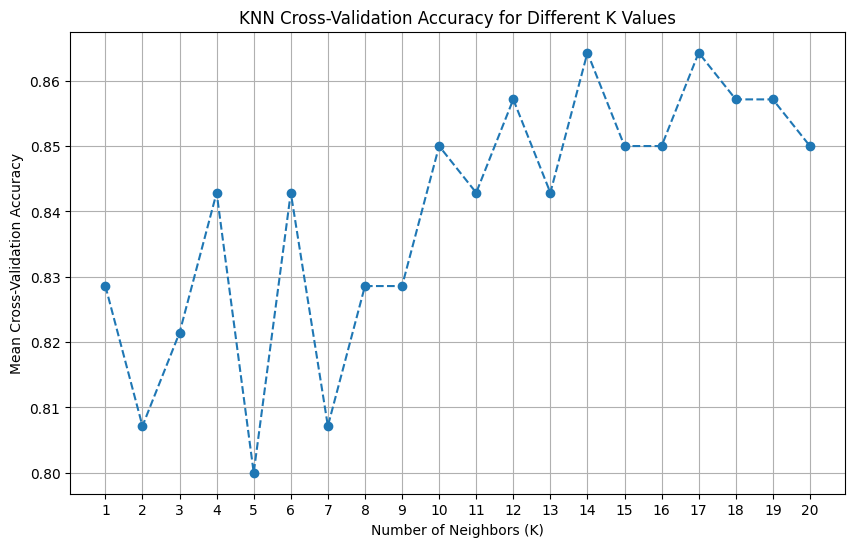

The optimal K value based on cross-validation is: 14
Test set accuracy with optimal K (14): 0.867


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# --- 1. Generate a Synthetic Dataset ---
# We'll create a simple binary classification dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# --- 2. Split Data into Training and Test Sets ---
# This is essential to evaluate the model's generalization performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 3. Scale Features ---
# KNN is sensitive to feature scaling, so it's good practice to standardize the data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. Define a Range of K Values to Test ---
k_range = range(1, 21) # Test K from 1 to 20
# For classification, it's often good to prioritize odd K values to avoid ties.
# We will test all for demonstration, but in practice, you might filter for odd.

# --- 5. Perform Cross-Validation for Each K ---
# We'll store the mean cross-validation accuracy for each K
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Use 5-fold cross-validation (cv=5)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# --- 6. Plot the Results ---
fig = plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', linestyle='--')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Accuracy for Different K Values')
plt.xticks(k_range) # Show all K values on the x-axis
plt.grid(True)
plt.show()

# --- 7. Find the Optimal K ---
optimal_k = k_range[np.argmax(cv_scores)]
print(f"The optimal K value based on cross-validation is: {optimal_k}")

# --- 8. Train and Evaluate the Model with Optimal K ---
optimal_knn = KNeighborsClassifier(n_neighbors=optimal_k)
optimal_knn.fit(X_train_scaled, y_train)

test_accuracy = optimal_knn.score(X_test_scaled, y_test)
print(f"Test set accuracy with optimal K ({optimal_k}): {test_accuracy:.3f}")

### 8. Pros and Cons of Choosing K

The choice of the `K` value is a critical step in building a K-Nearest Neighbors model, and it comes with its own set of advantages and disadvantages. These considerations highlight the trade-offs involved in selecting this hyperparameter.

#### A. Advantages (Pros) of a Well-Chosen K

1.  **Optimized Generalization Performance:**
    *   **Explanation:** A well-chosen `K` strikes a balance in the bias-variance trade-off, leading to a model that generalizes effectively to unseen data. It avoids both the underfitting of a too-large `K` and the overfitting of a too-small `K`, resulting in higher accuracy or better performance metrics on new data.

2.  **Increased Robustness to Noise and Outliers:**
    *   **Explanation:** By selecting an appropriate `K` (typically larger than 1), the model becomes more resilient to individual noisy data points or outliers in the training set. Their influence is diluted by the majority vote or averaging of other, more representative, neighbors.

3.  **Smoother and More Stable Decision Boundaries:**
    *   **Explanation:** A `K` value that is neither too small nor excessively large helps create decision boundaries that are sufficiently complex to capture patterns but smooth enough not to be overly reactive to minor fluctuations in the data. This leads to more stable predictions.

4.  **Improved Model Interpretability (in context):**
    *   **Explanation:** While KNN is inherently interpretable, a good `K` ensures that the

#### B. Disadvantages (Cons) of a Poorly Chosen K

1.  **Overfitting (Too Small K):**
    *   **Explanation:** A very small `K` (e.g., K=1) makes the model highly flexible and sensitive to noise and outliers in the training data. The decision boundary becomes complex and jagged, fitting the training data almost perfectly, but often failing to generalize to new, unseen data. This leads to high variance and poor performance on test sets.

2.  **Underfitting (Too Large K):**
    *   **Explanation:** Conversely, a very large `K` can lead to a model that is too simple. The decision boundary becomes overly smooth, and the model might miss important local patterns or distinctions. The neighborhood might encompass points from multiple classes or very different values, causing the model to over-generalize, resulting in high bias and poor performance even on the training data in some cases (underfitting).

3.  **Increased Sensitivity to Noise/Outliers (Too Small K):**
    *   **Explanation:** If `K=1`, a single mislabeled or noisy data point can entirely change the classification of a new query point if it happens to be the single closest neighbor. The model lacks robustness against such imperfections in the data.

4.  **Loss of Local Detail (Too Large K):**
    *   **Explanation:** While a large `K` increases robustness to noise, it might also cause the model to ignore genuine, important local patterns. The averaging or majority voting over a broad neighborhood can smooth out nuanced differences that are crucial for accurate classification or regression in specific regions of the feature space.

5.  **Computational Burden (Though Often Minor):**
    *   **Explanation:** Although the primary computational cost of KNN is distance calculation, a larger `K` means the algorithm needs to store and then sort/process more neighbors for each prediction. While optimized data structures (like KD-Trees) mitigate this, it can still add a marginal computational load during the aggregation step.

6.  **Difficulty in Tie-Breaking (Even K for Classification):**
    *   **Explanation:** If `K` is an even number in a multi-class (or binary) classification problem, it's possible to encounter a tie in the majority vote among the `K` neighbors. This requires a tie-breaking rule (e.g., choosing randomly, prioritizing the class of the closest neighbor, or using weighted voting), which can introduce arbitrary decisions or complexities.

7.  **Suboptimal Performance:**
    *   **Explanation:** A poorly chosen `K` directly translates to suboptimal model performance, either in terms of accuracy, precision, recall, or other relevant metrics. The model fails to leverage the data effectively for accurate predictions.

### 9. Comparison with Previous or Similar Algo/Models (Regarding Choosing K)

While the concept of 'choosing K' is specific to the K-Nearest Neighbors (KNN) algorithm, its underlying principle—balancing bias and variance to optimize model complexity and generalization—is universal in machine learning. Many other algorithms have analogous hyperparameters or mechanisms that serve a similar purpose.

#### A. Analogies in Other Algorithms

1.  **Decision Trees (e.g., `max_depth`, `min_samples_leaf`):**
    *   **K in KNN vs. `max_depth` in Decision Trees:**
        *   **Small K (high flexibility):** Similar to a Decision Tree with a large `max_depth` or no depth limit, which can grow very complex, perfectly fit the training data (low bias), and be highly sensitive to specific training samples (high variance), leading to overfitting.
        *   **Large K (low flexibility):** Similar to a Decision Tree with a small `max_depth`, which leads to a simpler, more generalized tree (high bias) that is less sensitive to individual data points (low variance), potentially leading to underfitting.
    *   **K in KNN vs. `min_samples_leaf`:**
        *   A small `min_samples_leaf` (e.g., 1) allows a Decision Tree to create very specific leaves based on a single sample, akin to a small K in KNN making decisions based on very local information.
        *   A large `min_samples_leaf` forces leaves to represent a larger group of samples, similar to a large K in KNN requiring a broader consensus.

2.  **Support Vector Machines (SVMs) (e.g., `C`, `gamma` in RBF kernel):**
    *   **K in KNN vs. `C` (Regularization Parameter) in SVMs:**
        *   **Small K (high variance, low bias):** Analogous to a small `C` value in SVMs, which prioritizes a wider margin, allowing more training errors but aiming for better generalization (smoother decision boundary, less prone to overfitting but potentially higher bias).
        *   **Large K (low variance, high bias):** Analogous to a large `C` value, which prioritizes correctly classifying all training points, potentially leading to a narrower margin and a more complex decision boundary (lower bias but higher variance), risking overfitting.
    *   **K in KNN vs. `gamma` (Kernel Coefficient) in RBF SVMs:**
        *   **Small K:** Similar to a large `gamma`, which results in a decision boundary that is highly influenced by individual training samples, leading to a very flexible and potentially overfitting model.
        *   **Large K:** Similar to a small `gamma`, which leads to a smoother, more global decision boundary, making the model less flexible and more prone to underfitting.

3.  **Regularization in Linear Models (e.g., Ridge, Lasso - `alpha` parameter):**
    *   The `alpha` parameter in regularized linear models (like Ridge or Lasso regression) controls the amount of penalty applied to the model coefficients. This directly influences the model's complexity and its bias-variance trade-off.
    *   **Small K (less regularization):** Can be seen as analogous to a small `alpha` in linear models, where the model is allowed to fit the training data more closely, potentially leading to overfitting.
    *   **Large K (more regularization/smoothing):** Analogous to a large `alpha`, which constrains the model parameters more, leading to a simpler model that might underfit but generalizes better.

#### B. Key Takeaway on Comparisons

The fundamental principle behind tuning `K` in KNN is about managing the model's complexity to achieve optimal generalization. This same principle applies across virtually all machine learning algorithms, though the specific hyperparameter and its mechanism of control will differ.

*   **KNN:** `K` directly controls the *localness* of the decision, thereby influencing the flexibility and smoothness of the decision boundary.
*   **Other Models:** Hyperparameters like `max_depth`, `C`, `gamma`, or `alpha` control other aspects of model complexity (e.g., tree size, margin width, kernel influence, coefficient magnitudes) to achieve the same balance between capturing signal and avoiding noise.

#### C. Summary and Best Practices for Choosing K

1.  **No Universal Formula:** There is no single mathematical formula to calculate the optimal `K` for all datasets. The ideal `K` is problem-dependent and dataset-specific.
2.  **Bias-Variance Trade-off:** The choice of `K` is a direct knob for controlling the bias-variance trade-off:
    *   **Small `K` (e.g., 1):** Low bias, high variance. Highly flexible, prone to overfitting and sensitive to noise/outliers. Captures local patterns but can be unstable.
    *   **Large `K`:** High bias, low variance. Smoother, more generalized, robust to noise but prone to underfitting and missing fine-grained local details.
3.  **Empirical Evaluation is Key (Cross-Validation):** The most reliable method to find an optimal `K` is through empirical evaluation using **cross-validation**. This involves testing a range of `K` values and selecting the one that yields the best performance (e.g., highest accuracy for classification, lowest RMSE for regression) on validation sets.
4.  **Consider Odd `K` for Classification:** For binary or multi-class classification, choosing an odd `K` helps to prevent ties in the majority voting process.
5.  **Feature Scaling is Crucial:** Regardless of the `K` value, KNN is highly sensitive to the scale of features. Always perform feature scaling (e.g., standardization or normalization) before applying KNN.
6.  **Domain Knowledge:** Sometimes, domain expertise can provide valuable insights into a reasonable range for `K`, guiding the search space for hyperparameter tuning.

In practice, it's common to start with some heuristic (like `K = sqrt(N)` where N is the number of samples), then use cross-validation to fine-tune and evaluate the performance across a broader range of `K` values.

## 5. Voting

### 1. Definition of Voting

In the K-Nearest Neighbors (KNN) algorithm, after identifying the `K` nearest neighbors to a new, unseen data point, **Voting** is the process by which the final prediction (either a class label for classification or a numerical value for regression) is determined from the characteristics of these `K` neighbors.

It's the mechanism through which the collective 'wisdom' of the local neighborhood is aggregated to make a decision for the query point.

#### A. For Classification (Majority Voting):

*   **Concept:** In classification tasks, voting refers to **majority voting**. The new data point is assigned the class label that appears most frequently among its `K` nearest neighbors.
*   **Mechanism:** Each of the `K` neighbors 'votes' for its own class. The class with the highest number of votes wins and becomes the predicted class for the query point.
*   **Tie-breaking:** If there's a tie in votes (which can happen with an even `K` value), a tie-breaking rule is needed. Common strategies include:
    *   Choosing the class of the single closest neighbor.
    *   Randomly selecting among the tied classes.
    *   Using weighted voting (see 'Weighted KNN' for more details), where closer neighbors have more influence.

#### B. For Regression (Averaging or Median):

*   **Concept:** In regression tasks, voting typically involves **averaging** (or taking the median) of the target values of the `K` nearest neighbors.
*   **Mechanism:** Instead of casting votes for a class, each neighbor contributes its actual numerical target value. These `K` values are then combined to produce a single predicted value for the query point.
*   **Common Aggregation Methods:**
    *   **Mean:** The most common method, where the predicted value is the arithmetic average of the `K` neighbors' target values.
    *   **Median:** Less sensitive to outliers than the mean. The predicted value is the median of the `K` neighbors' target values.

In essence, voting in KNN is the final step where the gathered local information (from the `K` nearest neighbors) is synthesized into a definitive prediction for the new data point. The method of voting is determined by whether the problem is classification or regression.

### 2. Intuition Behind Voting

The intuition behind voting in KNN is straightforward and reflects a common human decision-making strategy: **when faced with an unfamiliar situation, consult a group of your most knowledgeable and relevant peers.**

#### A. Analogies for Classification (Majority Vote):

1.  **Peer Group Consensus:** Imagine you're trying to identify an unknown object. If you show it to your `K` closest friends, and the majority of them say it's an 'Apple', you'll likely conclude it's an 'Apple'. The more friends agree, the more confident you are.
2.  **Jury Decision:** In a court of law, a jury makes a decision (e.g., guilty or not guilty) based on the evidence presented. Each juror (neighbor) casts a vote for one outcome, and the majority decision (or sometimes a unanimous one) determines the verdict. The assumption is that a collective decision is more robust than an individual one.
3.  **Polls/Surveys:** When predicting an election outcome, pollsters don't ask just one person. They survey a representative sample (the neighbors) and the candidate with the most support (votes) is predicted to win. The individual opinion (single neighbor) is less important than the collective trend.

#### B. Analogies for Regression (Averaging):

1.  **Estimating a Value:** Suppose you want to estimate the price of a house in a new neighborhood. You wouldn't rely on just one house's price. Instead, you'd look at the `K` most similar houses recently sold nearby and take their average selling price. This average provides a more stable and representative estimate than any single one.
2.  **Temperature Prediction:** If you want to predict tomorrow's temperature, you might look at the temperatures from the `K` previous days that had similar weather conditions (e.g., humidity, pressure). Averaging those `K` temperatures would likely give you a reasonable forecast.
3.  **Crowd Wisdom:** In many scenarios, the average of multiple independent estimates is often more accurate than most individual estimates. This 'wisdom of the crowd' principle underlies the averaging approach in KNN regression.

#### C. Why Not Just Use the Closest Neighbor?

The primary reason for using voting (with `K > 1`) is to **increase robustness and reduce sensitivity to noise or outliers.** A single closest neighbor (`K=1`) can be an anomaly or a mislabeled point, leading to an incorrect prediction. By consulting multiple neighbors, the influence of such individual erroneous points is diluted, and a more generalized, stable prediction emerges from the consensus of the local group.

In essence, voting acts as a form of local smoothing or ensemble learning, making the KNN algorithm more reliable.

### 3. Mathematical Foundation of Voting

The mathematical foundation of voting in KNN is rooted in **statistical aggregation** of labels or values from the `K` nearest neighbors. While simple in concept, these aggregations leverage fundamental statistical operations.

Let $x_q$ be the query point for which we want to make a prediction, and let $N_K(x_q)$ be the set of its `K` nearest neighbors from the training dataset $D = \{(x_i, y_i)\}_{i=1}^N$. Each $(x_i, y_i) \in N_K(x_q)$ consists of a feature vector $x_i$ and its corresponding label/value $y_i$.

#### A. For Classification (Majority Vote):

For classification, the predicted class $\hat{y}_q$ for the query point $x_q$ is the class label that occurs most frequently among the `K` nearest neighbors. This is formally expressed using an indicator function and maximization:

$$ \hat{y}_q = \operatorname{argmax}_{c \in \text{Classes}} \left( \sum_{(x_i, y_i) \in N_K(x_q)} I(y_i = c) \right) $$

Where:
*   $c$ represents a possible class label.
*   $I(y_i = c)$ is an **indicator function** that returns 1 if the label $y_i$ of the neighbor $i$ is equal to class $c$, and 0 otherwise.
*   The sum $\sum \dots$ counts how many neighbors belong to class $c$.
*   $\operatorname{argmax}_{c}$ selects the class $c$ for which this sum (the count) is the largest.

In simpler terms, we count the number of neighbors belonging to each class and assign the query point to the class with the highest count.

#### B. For Regression (Averaging or Median):

For regression, the predicted value $\hat{y}_q$ for the query point $x_q$ is an aggregated numerical value from its `K` nearest neighbors. The two most common methods are the mean and the median.

1.  **Mean (Arithmetic Average):**

The predicted value is the arithmetic average of the target values of the `K` nearest neighbors:

$$ \hat{y}_q = \frac{1}{K} \sum_{(x_i, y_i) \in N_K(x_q)} y_i $$

*   This is the standard approach and is easy to compute. It implicitly assumes a linear relationship locally.

2.  **Median:**

The predicted value is the median of the target values of the `K` nearest neighbors:

$$ \hat{y}_q = \operatorname{median}_{ (x_i, y_i) \in N_K(x_q) } y_i $$

*   The median is more robust to outliers than the mean, as extreme values among the neighbors will have less impact on the final prediction.

#### C. Weighted Voting (Extension):

The mathematical foundation can be extended to **weighted voting** (or weighted averaging), where each neighbor's contribution is scaled by a weight, typically inversely proportional to its distance from the query point. This means closer neighbors have a greater mathematical influence.

For classification with weighted voting:

$$ \hat{y}_q = \operatorname{argmax}_{c \in \text{Classes}} \left( \sum_{(x_i, y_i) \in N_K(x_q)} w_i \cdot I(y_i = c) \right) $$

For regression with weighted averaging:

$$ \hat{y}_q = \frac{\sum_{(x_i, y_i) \in N_K(x_q)} w_i \cdot y_i}{\sum_{(x_i, y_i) \in N_K(x_q)} w_i} $$

Where $w_i$ is the weight assigned to neighbor $i$, usually $w_i = \frac{1}{d(x_q, x_i)^p}$ for some $p \ge 1$.

These mathematical formulations precisely define how the 'votes' or 'values' of the neighbors are combined to form the final prediction, embodying the core idea of localized aggregation in KNN.

### 4. Numerical Example of Voting

Let's use a numerical example to clearly illustrate the voting process for both classification and regression.

**Scenario:** We have a training dataset with two features (X1, X2) and either a `Class` (for classification) or a `Value` (for regression). We want to predict the outcome for a new `Query Point P (X1=5, X2=5)`.

**Training Data:**

| Point | X1 | X2 | Class  | Value |
| :---- | :- | :- | :----- | :---- |
| A     | 1  | 6  | Blue   | 10    |
| B     | 3  | 4  | Red    | 12    |
| C     | 6  | 7  | Blue   | 8     |
| D     | 7  | 3  | Red    | 15    |
| E     | 8  | 6  | Blue   | 9     |
| F     | 4  | 1  | Red    | 11    |
| G     | 5  | 8  | Blue   | 7     |

**Query Point P:** (5, 5)

**Chosen K Value:** K = 3

**Distance Metric:** Euclidean Distance

---

#### Step 1: Calculate Euclidean Distances to Query Point P (5, 5)

*   $d(P, A) = \sqrt{(5-1)^2 + (5-6)^2} = \sqrt{4^2 + (-1)^2} = \sqrt{16+1} = \sqrt{17} \approx 4.12$
*   $d(P, B) = \sqrt{(5-3)^2 + (5-4)^2} = \sqrt{2^2 + 1^2} = \sqrt{4+1} = \sqrt{5} \approx 2.24$
*   $d(P, C) = \sqrt{(5-6)^2 + (5-7)^2} = \sqrt{(-1)^2 + (-2)^2} = \sqrt{1+4} = \sqrt{5} \approx 2.24$
*   $d(P, D) = \sqrt{(5-7)^2 + (5-3)^2} = \sqrt{(-2)^2 + 2^2} = \sqrt{4+4} = \sqrt{8} \approx 2.83$
*   $d(P, E) = \sqrt{(5-8)^2 + (5-6)^2} = \sqrt{(-3)^2 + (-1)^2} = \sqrt{9+1} = \sqrt{10} \approx 3.16$
*   $d(P, F) = \sqrt{(5-4)^2 + (5-1)^2} = \sqrt{1^2 + 4^2} = \sqrt{1+16} = \sqrt{17} \approx 4.12$
*   $d(P, G) = \sqrt{(5-5)^2 + (5-8)^2} = \sqrt{0^2 + (-3)^2} = \sqrt{0+9} = \sqrt{9} = 3.00$

---

#### Step 2: Identify K=3 Nearest Neighbors

Order by distance and pick the top 3:

| Point | Distance | Class | Value |
| :---- | :------- | :---- | :---- |
| B     | 2.24     | Red   | 12    |
| C     | 2.24     | Blue  | 8     |
| D     | 2.83     | Red   | 15    |
| G     | 3.00     | Blue  | 7     |
| E     | 3.16     | Blue  | 9     |
| A     | 4.12     | Blue  | 10    |
| F     | 4.12     | Red   | 11    |

The 3 nearest neighbors are: **B (Red, 12), C (Blue, 8), D (Red, 15)**.

---

#### Step 3: Voting for Classification and Regression

**A. Classification (Majority Vote):**

*   Neighbors' Classes: Red, Blue, Red
*   Counts:
    *   Red: 2 votes (B, D)
    *   Blue: 1 vote (C)

*   **Conclusion for Classification:** The majority class is **Red**. So, Query Point P is classified as **Red**.

**B. Regression (Averaging):

*   Neighbors' Values: 12 (from B), 8 (from C), 15 (from D)
*   Average: $(12 + 8 + 15) / 3 = 35 / 3 \approx 11.67$

*   **Conclusion for Regression:** The predicted value for Query Point P is approximately **11.67**.

This example clearly shows how the voting mechanism aggregates the information from the closest neighbors to yield a final prediction, whether it's a class label or a numerical value.

### 5. Python Implementation of Voting

We've already seen a basic Python implementation of KNN classification that includes majority voting. Here, we'll expand on that to explicitly show the voting steps and also implement it for regression using averaging. We will use the same data from our numerical example.

First, let's set up our data and the distance function.

In [10]:
import numpy as np
from collections import Counter

# Euclidean Distance function (re-using from previous explanations)
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

# --- Our Numerical Example Data ---
# Training features (X1, X2)
training_data = np.array([
    [1, 6], # A
    [3, 4], # B
    [6, 7], # C
    [7, 3], # D
    [8, 6], # E
    [4, 1], # F
    [5, 8]  # G
])

# Corresponding training labels for classification
training_classes = ['Blue', 'Red', 'Blue', 'Red', 'Blue', 'Red', 'Blue']

# Corresponding training values for regression
training_values = [10, 12, 8, 15, 9, 11, 7]

# New data point to predict
query_point = np.array([5, 5])

# Chosen K value
k_value = 3

print("Training Data Features:\n", training_data)
print("\nTraining Classes:\n", training_classes)
print("\nTraining Values:\n", training_values)
print("\nQuery Point:\n", query_point)
print(f"Chosen K: {k_value}")

Training Data Features:
 [[1 6]
 [3 4]
 [6 7]
 [7 3]
 [8 6]
 [4 1]
 [5 8]]

Training Classes:
 ['Blue', 'Red', 'Blue', 'Red', 'Blue', 'Red', 'Blue']

Training Values:
 [10, 12, 8, 15, 9, 11, 7]

Query Point:
 [5 5]
Chosen K: 3


#### A. Python Implementation of Voting for Classification (Majority Vote)

In [11]:
def knn_classify_with_voting(training_data, training_classes, query_point, k):
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_classes[i]))

    # Sort by distance and get the k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    # Extract labels of the k nearest neighbors
    neighbor_labels = [label for dist, label in k_nearest_neighbors]
    print(f"\nK={k} Nearest Neighbors (Classification): {k_nearest_neighbors}")
    print(f"Neighbor Labels: {neighbor_labels}")

    # Perform Majority Voting
    # Counter counts the occurrences of each label
    # most_common(1) returns the label with the highest count
    most_common = Counter(neighbor_labels).most_common(1)
    predicted_class = most_common[0][0]
    print(f"Vote counts: {Counter(neighbor_labels)}")

    return predicted_class

# Perform classification
predicted_class = knn_classify_with_voting(training_data, training_classes, query_point, k_value)
print(f"Predicted Class for Query Point {query_point} (K={k_value}): {predicted_class}")


K=3 Nearest Neighbors (Classification): [(np.float64(2.23606797749979), 'Red'), (np.float64(2.23606797749979), 'Blue'), (np.float64(2.8284271247461903), 'Red')]
Neighbor Labels: ['Red', 'Blue', 'Red']
Vote counts: Counter({'Red': 2, 'Blue': 1})
Predicted Class for Query Point [5 5] (K=3): Red


#### B. Python Implementation of Voting for Regression (Averaging)

In [12]:
def knn_regress_with_voting(training_data, training_values, query_point, k):
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_values[i]))

    # Sort by distance and get the k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    # Extract values of the k nearest neighbors
    neighbor_values = [value for dist, value in k_nearest_neighbors]
    print(f"\nK={k} Nearest Neighbors (Regression): {k_nearest_neighbors}")
    print(f"Neighbor Values: {neighbor_values}")

    # Perform Averaging (Voting for Regression)
    predicted_value = np.mean(neighbor_values)
    # Or for median: np.median(neighbor_values)

    return predicted_value

# Perform regression
predicted_value = knn_regress_with_voting(training_data, training_values, query_point, k_value)
print(f"Predicted Value for Query Point {query_point} (K={k_value}): {predicted_value:.2f}")


K=3 Nearest Neighbors (Regression): [(np.float64(2.23606797749979), 12), (np.float64(2.23606797749979), 8), (np.float64(2.8284271247461903), 15)]
Neighbor Values: [12, 8, 15]
Predicted Value for Query Point [5 5] (K=3): 11.67


These implementations directly reflect the mathematical formulas and intuitive concepts of voting for both classification and regression tasks in KNN.

## 6.  Weighted KNN (WKNN)

### 1. Why We Need Weighted KNN

In the standard K-Nearest Neighbors (KNN) algorithm, when making a prediction (either classification or regression), all `K` nearest neighbors contribute equally to the final vote or average. This means a neighbor that is very close to the query point has the same influence as a neighbor that is at the outer edge of the `K`-neighborhood.

However, it's often intuitive that **closer neighbors should have more influence** on the prediction than farther ones. Weighted KNN addresses this limitation and offers several compelling reasons for its necessity:

1.  **Differentiating Neighbor Influence:**
    *   **Explanation:** The fundamental reason is to acknowledge that not all neighbors are equally representative. A point very close to the query point is likely a better indicator of the query point's true class or value than a point that is further away, even if both are within the top `K` neighbors. Standard KNN ignores this crucial difference.

2.  **Increased Robustness and Accuracy:**
    *   **Explanation:** By giving more weight to closer, more relevant neighbors, WKNN can improve prediction accuracy. Distant neighbors, which might be less similar or even noisy, have their influence naturally diminished, making the model more robust to their potential misdirection.

3.  **Mitigating the Impact of Boundary/Noisy Points:**
    *   **Explanation:** Near decision boundaries, a query point might have a very close neighbor from one class and slightly farther neighbors from another. In standard KNN, a single distant neighbor could tip the majority vote. With weighting, the very close neighbor (even if it's a 'noisy' or minority class point) will have a stronger pull, but its influence can still be counteracted by a collective of slightly less close, but more numerous, neighbors from the other class.

4.  **Implicit Tie-Breaking for Classification:**
    *   **Explanation:** In classification with standard KNN, ties in majority voting (especially with even `K`) require arbitrary tie-breaking rules. Weighted voting intrinsically resolves most ties, as it's highly unlikely that weighted sums for multiple classes will be perfectly equal. The class with the highest *weighted sum* of votes wins.

5.  **Smoother Regression Estimates:**
    *   **Explanation:** For regression, simple averaging can be overly sensitive to the numerical values of even the farthest `K` neighbors. Weighted averaging provides a smoother estimate by ensuring that values from closer neighbors have a more dominant effect on the predicted outcome.

6.  **Better Generalization:**
    *   **Explanation:** By prioritizing information from the most similar instances, WKNN generally leads to a better generalization performance, especially in datasets where the concept of 'local similarity' is strongly correlated with the target variable.

7.  **Enhancing Local Interpretability:**
    *   **Explanation:** While still instance-based, WKNN allows for a more nuanced understanding of *why* a prediction was made. One can see that the closest neighbors had a proportionally larger say in the outcome, aligning better with intuitive notions of influence.

In essence, Weighted KNN refines the core principle of KNN by making the 'neighbors' opinions' more granular and representative of their actual proximity and relevance to the query point.

### 2. Definition of Weighted K-Nearest Neighbors (WKNN)

Weighted K-Nearest Neighbors (WKNN) is an extension of the standard KNN algorithm that assigns **different weights to each of the `K` nearest neighbors** when making a prediction. Unlike standard KNN, where all `K` neighbors contribute equally to the decision, WKNN gives more influence to neighbors that are closer to the query point and less influence to neighbors that are farther away.

#### A. Core Concept:

*   **Distance-Based Weighting:** The primary characteristic of WKNN is that the weight assigned to each neighbor is typically inversely proportional to its distance from the query point. This means:
    *   A very close neighbor will have a **high weight**, significantly influencing the prediction.
    *   A farther neighbor (still within the `K` closest) will have a **lower weight**, contributing less to the prediction.

#### B. How Weights are Applied:

1.  **For Classification (Weighted Majority Voting):**
    *   Instead of simply counting votes, each neighbor's 'vote' for its class is multiplied by its assigned weight. The class that accumulates the highest *sum of weights* (not just count) is chosen as the predicted class for the query point.
    *   This naturally handles tie-breaking; it's highly improbable for two classes to have the exact same weighted sum.

2.  **For Regression (Weighted Averaging):**
    *   Each neighbor's target value is multiplied by its assigned weight. The predicted value for the query point is then calculated as the *weighted average* of these `K` target values.

#### C. Common Weighting Functions:

Let $d_i$ be the distance between the query point $x_q$ and the $i$-th nearest neighbor $x_i$. Common choices for the weight $w_i$ for neighbor $i$ include:

*   **Inverse Distance:** $w_i = \frac{1}{d_i}$
    *   This is simple, but can lead to issues if $d_i = 0$ (i.e., the query point is identical to a training point), which would result in an infinite weight. Often, a small constant (epsilon) is added to the denominator to prevent division by zero: $w_i = \frac{1}{d_i + \epsilon}$.

*   **Inverse Squared Distance:** $w_i = \frac{1}{d_i^2}$
    *   This assigns an even greater penalty to farther neighbors, making closer neighbors more dominant.

*   **Gaussian Kernel (or other Kernel functions):** $w_i = e^{-\frac{d_i^2}{\sigma^2}}$
    *   This uses a Gaussian (bell-shaped) function, where $\sigma$ (sigma) is a bandwidth parameter. Closer points (smaller $d_i$) get weights closer to 1, while farther points get weights closer to 0. The rate at which weights drop off is controlled by $\sigma$.

#### D. Relationship to Standard KNN:

Standard KNN can be seen as a special case of Weighted KNN where all weights are equal (e.g., $w_i = 1$ for all $i$).

In summary, WKNN enhances the basic KNN by introducing a nuanced influence of neighbors based on their proximity, leading to more refined and often more accurate predictions.

The intuition behind weighted voting (or averaging) in WKNN is a refinement of the basic KNN voting concept. It formalizes our natural inclination to give more credibility or importance to opinions or data points that are closer and thus more relevant to the matter at hand.

#### A. Analogies for Weighted Classification (Weighted Majority Vote):

1.  **Expert Opinions / Confidence:** Imagine you're trying to identify an unknown object, but now you have friends with varying levels of expertise or confidence in their opinion. Your closest friends (nearest neighbors) who are also experts might have their opinions count for more than friends who are farther away or less sure. In WKNN, 'closeness' is the proxy for 'expertise' or 'relevance'. If your *very closest* friend says 'Apple' with high confidence, that opinion carries more weight than three friends who are somewhat farther away and say 'Orange' collectively.

2.  **Influential Votes:** In a committee meeting, not all votes might be equal. Some members might have more influence due to their position or knowledge. Similarly, in WKNN, neighbors who are spatially closer to the query point are considered more 'influential' and their vote carries more 'weight' in the final decision.

3.  **Customer Reviews with Ratings:** When buying a product, you might look at customer reviews. A review from a highly-rated, 'verified purchase' reviewer who lives nearby (analogous to a close neighbor) might influence your decision more than a generic review from someone far away.

#### B. Analogies for Weighted Regression (Weighted Averaging):

1.  **Real Estate Appraisal:** When appraising a house, a real estate agent looks at comparable sales. They wouldn't just average the price of all comparable houses. They would give more consideration (weight) to sales of houses that are *very similar* and *very close* geographically to the house being appraised, and less weight to houses that are somewhat similar but farther away. The closest comparables heavily influence the final estimate.

2.  **Stock Price Prediction:** If you're trying to predict tomorrow's stock price based on historical data, you'd likely give more importance to the behavior of the stock on the *most recent days* with similar market conditions, rather than giving equal importance to data from many months ago, even if they share some similarities.

3.  **Medical Diagnosis based on Symptoms:** A doctor might weigh a very clear, defining symptom more heavily than a general, less specific symptom, especially if the defining symptom is strongly associated with a nearby, similar patient's diagnosis.

#### C. The Refinement of Proximity:

The core intuition is that **proximity implies stronger relevance**. While standard KNN acknowledges proximity by selecting the `K` closest points, WKNN takes it a step further by acknowledging that *within* those `K` closest points, there is still a gradient of relevance. The very closest points provide the strongest local signal, and WKNN allows this stronger signal to dominate the prediction, leading to potentially more accurate and nuanced results than a simple unweighted average or majority vote. It's a way to listen more intently to the 'voices' that are speaking most directly to the query point.

### 3. Mathematical Foundation of Weighted K-Nearest Neighbors (WKNN)

The mathematical core of WKNN involves assigning a weight to each of the `K` nearest neighbors, typically based on its distance from the query point. These weights then influence the final prediction through weighted aggregation. Let $x_q$ be the query point, and $N_K(x_q)$ be the set of its `K` nearest neighbors, where each neighbor $x_i 	ext{ has an associated label/value } y_i$ and a distance $d(x_q, x_i)$.

#### A. Weight Calculation

The weight $w_i$ assigned to the $i$-th neighbor (with distance $d_i = d(x_q, x_i)$) is typically an inverse function of its distance. This ensures that closer neighbors have larger weights. Common weighting functions include:

1.  **Inverse Distance Weighting:**
    $$ w_i = \frac{1}{d_i} \quad \text{or, more robustly,} \quad w_i = \frac{1}{d_i + \epsilon} $$
    Where $\epsilon$ is a small positive constant (e.g., $10^{-5}$) to prevent division by zero if $d_i = 0$ (i.e., if a training point is identical to the query point). The `+epsilon` ensures that a distance of zero still yields a very high, but finite, weight.

2.  **Inverse Squared Distance Weighting:**
    $$ w_i = \frac{1}{d_i^2} \quad \text{or} \quad w_i = \frac{1}{d_i^2 + \epsilon} $$
    This function decreases the influence of farther neighbors more aggressively than simple inverse distance, giving even more dominance to the closest points.

3.  **Gaussian Kernel Weighting:**
    $$ w_i = e^{-\frac{d_i^2}{\sigma^2}} $$
    Here, $\sigma$ (sigma) is a bandwidth parameter that controls how quickly the weights decay with distance. A smaller $\sigma$ means weights drop off quickly, making the model more local, while a larger $\sigma$ means weights drop off slowly, giving more influence to farther neighbors. This function assigns weights between 0 and 1, where $d_i=0$ gives $w_i=1$.

In all these cases, if $d_i = 0$, the neighbor usually gets the maximum possible weight (or the query point is directly assigned the label/value of that identical training point).

#### B. Weighted Voting for Classification

For classification tasks, instead of a simple majority count, WKNN uses a **weighted majority vote**. The predicted class $\hat{y}_q$ for the query point $x_q$ is the class that accumulates the highest sum of weights from its `K` nearest neighbors.

$$ \hat{y}_q = \operatorname{argmax}_{c \in \text{Classes}} \left( \sum_{(x_i, y_i) \in N_K(x_q)} w_i \cdot I(y_i = c) \right) $$

Where:
*   $c$ represents a possible class label.
*   $I(y_i = c)$ is the indicator function, returning 1 if the label $y_i$ of neighbor $i$ is equal to class $c$, and 0 otherwise.
*   $w_i$ is the weight of neighbor $i$, calculated as described above.
*   The sum $\sum \dots$ calculates the total weighted 'vote' for each class.
*   $\operatorname{argmax}_{c}$ selects the class $c$ with the highest total weighted vote.

#### C. Weighted Averaging for Regression

For regression tasks, WKNN calculates a **weighted average** of the target values of its `K` nearest neighbors. This means each neighbor's value contributes to the average in proportion to its weight.

$$ \hat{y}_q = \frac{\sum_{(x_i, y_i) \in N_K(x_q)} w_i \cdot y_i}{\sum_{(x_i, y_i) \in N_K(x_q)} w_i} $$

Where:
*   $y_i$ is the target value of neighbor $i$.
*   $w_i$ is the weight of neighbor $i$.
*   The numerator is the sum of each neighbor's value multiplied by its weight.
*   The denominator is the sum of all weights, ensuring the result is a proper weighted average.

These mathematical formulations precisely define how WKNN differentiates the influence of neighbors based on their proximity, leading to a more refined and often more accurate prediction.

### 4. Numerical Example of Weighted K-Nearest Neighbors (WKNN)

Let's revisit our previous numerical example for voting, but this time, we'll apply weights to the neighbors based on their distance to the query point.

**Scenario:** We have a training dataset with two features (X1, X2) and either a `Class` (for classification) or a `Value` (for regression). We want to predict the outcome for a new `Query Point P (X1=5, X2=5)`.

**Training Data:**

| Point | X1 | X2 | Class  | Value |
| :---- | :- | :- | :----- | :---- |
| A     | 1  | 6  | Blue   | 10    |
| B     | 3  | 4  | Red    | 12    |
| C     | 6  | 7  | Blue   | 8     |
| D     | 7  | 3  | Red    | 15    |
| E     | 8  | 6  | Blue   | 9     |
| F     | 4  | 1  | Red    | 11    |
| G     | 5  | 8  | Blue   | 7     |

**Query Point P:** (5, 5)

**Chosen K Value:** K = 3

**Distance Metric:** Euclidean Distance

**Weighting Function:** Inverse Distance Weighting ($w_i = \frac{1}{d_i + \epsilon}$, with $\epsilon = 0.001$ to avoid division by zero).

---

#### Step 1: Calculate Euclidean Distances to Query Point P (5, 5)

(These are the same distances as calculated in the previous voting example)

*   $d(P, A) \approx 4.12$
*   $d(P, B) \approx 2.24$
*   $d(P, C) \approx 2.24$
*   $d(P, D) \approx 2.83$
*   $d(P, E) \approx 3.16$
*   $d(P, F) \approx 4.12$
*   $d(P, G) \approx 3.00$

---

#### Step 2: Identify K=3 Nearest Neighbors and Calculate Their Weights

Order by distance and pick the top 3, then calculate weights using $w_i = \frac{1}{d_i + 0.001}$:

| Point | Distance (d_i) | Class | Value | Weight (w_i = 1/(d_i + 0.001)) |
| :---- | :------------- | :---- | :---- | :------------------------------ |
| B     | 2.24           | Red   | 12    | $1 / (2.24 + 0.001) \approx 0.446$ |
| C     | 2.24           | Blue  | 8     | $1 / (2.24 + 0.001) \approx 0.446$ |
| D     | 2.83           | Red   | 15    | $1 / (2.83 + 0.001) \approx 0.353$ |
| G     | 3.00           | Blue  | 7     | (not included in top K=3)       |
| E     | 3.16           | Blue  | 9     | (not included in top K=3)       |
| A     | 4.12           | Blue  | 10    | (not included in top K=3)       |
| F     | 4.12           | Red   | 11    | (not included in top K=3)       |

Our 3 nearest neighbors with their classes/values and calculated weights are:
*   **B:** Class = Red, Value = 12, Weight $\approx 0.446$
*   **C:** Class = Blue, Value = 8, Weight $\approx 0.446$
*   **D:** Class = Red, Value = 15, Weight $\approx 0.353$

Notice that points B and C have the same distance and thus the same weight. If there were a slight difference in distance, their weights would also differ.

---

#### Step 3: Weighted Voting for Classification and Regression

**A. Classification (Weighted Majority Vote):**

Calculate the total weighted sum for each class:
*   **Red Class Weighted Sum:** $w_B + w_D = 0.446 + 0.353 = 0.799$
*   **Blue Class Weighted Sum:** $w_C = 0.446$

*   **Conclusion for Classification:** The 'Red' class has a higher total weighted sum ($0.799 > 0.446$). So, Query Point P is classified as **Red**.

    (In this specific example, the result is the same as unweighted KNN, but WKNN provides a clearer margin of confidence due to the weights.)

**B. Regression (Weighted Averaging):**

Calculate the weighted average of the neighbors' values:

$$ \hat{y}_P = \frac{(w_B \cdot Value_B) + (w_C \cdot Value_C) + (w_D \cdot Value_D)}{w_B + w_C + w_D} $$

$$ \hat{y}_P = \frac{(0.446 \cdot 12) + (0.446 \cdot 8) + (0.353 \cdot 15)}{0.446 + 0.446 + 0.353} $$

$$ \hat{y}_P = \frac{5.352 + 3.568 + 5.295}{1.245} $$

$$ \hat{y}_P = \frac{14.215}{1.245} \approx 11.42 $$

*   **Conclusion for Regression:** The predicted value for Query Point P is approximately **11.42**.

    (For comparison, the unweighted average was $\approx 11.67$. The closer neighbors (B and C) pulling towards values 12 and 8, combined with D at 15, result in a slightly different weighted average. This highlights how WKNN can fine-tune the prediction based on proximity.)

### 5. Python Implementation of Weighted K-Nearest Neighbors (WKNN)

We will adapt our previous `knn_classify` and `knn_regress` functions to incorporate distance-based weighting. We'll use the inverse distance weighting scheme ($w_i = 1 / (d_i + \epsilon)$) and apply it to the same numerical example data.

In [13]:
import numpy as np
from collections import Counter

# Euclidean Distance function (re-using from previous explanations)
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

# --- Our Numerical Example Data (same as before) ---
# Training features (X1, X2)
training_data = np.array([
    [1, 6], # A
    [3, 4], # B
    [6, 7], # C
    [7, 3], # D
    [8, 6], # E
    [4, 1], # F
    [5, 8]  # G
])

# Corresponding training labels for classification
training_classes = ['Blue', 'Red', 'Blue', 'Red', 'Blue', 'Red', 'Blue']

# Corresponding training values for regression
training_values = [10, 12, 8, 15, 9, 11, 7]

# New data point to predict
query_point = np.array([5, 5])

# Chosen K value
k_value = 3

# Epsilon to prevent division by zero for inverse distance weighting
epsilon = 1e-6 # A very small number

print("Training Data Features:\n", training_data)
print("\nTraining Classes:\n", training_classes)
print("\nTraining Values:\n", training_values)
print("\nQuery Point:\n", query_point)
print(f"Chosen K: {k_value}")
print(f"Epsilon for weighting: {epsilon}")

Training Data Features:
 [[1 6]
 [3 4]
 [6 7]
 [7 3]
 [8 6]
 [4 1]
 [5 8]]

Training Classes:
 ['Blue', 'Red', 'Blue', 'Red', 'Blue', 'Red', 'Blue']

Training Values:
 [10, 12, 8, 15, 9, 11, 7]

Query Point:
 [5 5]
Chosen K: 3
Epsilon for weighting: 1e-06


#### A. Python Implementation of Weighted KNN for Classification

In [14]:
def wknn_classify(training_data, training_classes, query_point, k, epsilon=1e-6):
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_classes[i]))

    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    weighted_votes = Counter()
    for dist, label in k_nearest_neighbors:
        # Calculate weight using inverse distance (with epsilon for robustness)
        weight = 1 / (dist + epsilon)
        weighted_votes[label] += weight

    print(f"\nK={k} Nearest Neighbors (with distances and labels): {k_nearest_neighbors}")
    print(f"Weighted votes for each class: {weighted_votes}")

    # Get the class with the highest total weight
    if weighted_votes:
        predicted_class = max(weighted_votes, key=weighted_votes.get)
    else:
        predicted_class = None # Handle case where no neighbors are found (e.g., k=0 or empty training data)

    return predicted_class

# Perform weighted classification
predicted_wknn_class = wknn_classify(training_data, training_classes, query_point, k_value, epsilon)
print(f"Predicted Class for Query Point {query_point} (WKNN, K={k_value}): {predicted_wknn_class}")


K=3 Nearest Neighbors (with distances and labels): [(np.float64(2.23606797749979), 'Red'), (np.float64(2.23606797749979), 'Blue'), (np.float64(2.8284271247461903), 'Red')]
Weighted votes for each class: Counter({'Red': np.float64(0.8007666610933653), 'Blue': np.float64(0.44721339550004735)})
Predicted Class for Query Point [5 5] (WKNN, K=3): Red


#### B. Python Implementation of Weighted KNN for Regression

In [15]:
def wknn_regress(training_data, training_values, query_point, k, epsilon=1e-6):
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_values[i]))

    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    total_weighted_value = 0
    total_weights = 0
    for dist, value in k_nearest_neighbors:
        # Calculate weight using inverse distance (with epsilon for robustness)
        weight = 1 / (dist + epsilon)
        total_weighted_value += (weight * value)
        total_weights += weight

    print(f"\nK={k} Nearest Neighbors (with distances and values): {k_nearest_neighbors}")
    print(f"Total weighted value: {total_weighted_value:.2f}")
    print(f"Total weights: {total_weights:.2f}")

    # Calculate weighted average
    if total_weights > 0:
        predicted_value = total_weighted_value / total_weights
    else:
        predicted_value = None # Handle case where no neighbors are found or weights sum to zero

    return predicted_value

# Perform weighted regression
predicted_wknn_value = wknn_regress(training_data, training_values, query_point, k_value, epsilon)
print(f"Predicted Value for Query Point {query_point} (WKNN, K={k_value}): {predicted_wknn_value:.2f}")


K=3 Nearest Neighbors (with distances and values): [(np.float64(2.23606797749979), 12), (np.float64(2.23606797749979), 8), (np.float64(2.8284271247461903), 15)]
Total weighted value: 14.25
Total weights: 1.25
Predicted Value for Query Point [5 5] (WKNN, K=3): 11.42


### 6. Explanation of the Python Code for Weighted KNN (WKNN)

The Python code provided in the previous cells implements the Weighted K-Nearest Neighbors algorithm. It adapts the core KNN logic to incorporate distance-based weighting, where closer neighbors have a greater influence on the prediction. Let's break down each part.

#### A. Setup (Cell containing `euclidean_distance`, `training_data`, `query_point`, `k_value`, `epsilon`)

*   **`euclidean_distance(point1, point2)` Function:** This function remains the same as in our standard KNN explanation. It calculates the Euclidean distance between two points, serving as the basis for determining 'closeness'.

*   **Example Data (`training_data`, `training_classes`, `training_values`):** We reuse the same numerical example data and query point to demonstrate WKNN. This consistency allows for direct comparison with the unweighted KNN results.

*   **`query_point` and `k_value`:** The new data point to predict and the number of neighbors to consider, respectively, are set as before.

*   **`epsilon` (Small Constant):** This is a crucial addition for inverse distance weighting. When calculating $w_i = 1 / d_i$, if a training point happens to be identical to the `query_point` (meaning $d_i=0$), it would lead to a division by zero error. `epsilon` (a very small positive number like `1e-6`) is added to the denominator (`d_i + epsilon`) to prevent this, ensuring a finite (though very large) weight even for identical points.

#### B. `wknn_classify(training_data, training_classes, query_point, k, epsilon)` Function

This function handles weighted classification:

1.  **Distance Calculation and Neighbor Storage:**
    *   It iterates through the `training_data`, calculates the `euclidean_distance` between the `query_point` and each `data_point`.
    *   It stores a list of `(distance, class_label)` tuples.

2.  **Identifying K-Nearest Neighbors:**
    *   `distances.sort(key=lambda x: x[0])` sorts these tuples based on distance.
    *   `k_nearest_neighbors = distances[:k]` selects the `k` closest neighbors.

3.  **Weighted Voting:**
    *   `weighted_votes = Counter()` initializes a counter to accumulate weighted votes for each class.
    *   It then loops through each of the `k_nearest_neighbors`:
        *   `weight = 1 / (dist + epsilon)`: This is where the inverse distance weighting is applied. The calculated distance `dist` is used to determine the weight. Adding `epsilon` handles potential division by zero.
        *   `weighted_votes[label] += weight`: Instead of simply incrementing a count, the calculated `weight` is added to the total for that neighbor's `label`.

4.  **Determining Predicted Class:**
    *   `predicted_class = max(weighted_votes, key=weighted_votes.get)`: After summing all weighted votes, this line finds the class with the highest total weighted sum. This effectively performs the weighted majority vote.

5.  **Output:** The function prints the `k` nearest neighbors, their labels, and the final `weighted_votes` for each class, concluding with the `predicted_class`.

#### C. `wknn_regress(training_data, training_values, query_point, k, epsilon)` Function

This function handles weighted regression:

1.  **Distance Calculation and Neighbor Storage:** Similar to `wknn_classify`, it calculates distances and stores `(distance, target_value)` tuples.

2.  **Identifying K-Nearest Neighbors:** It sorts and selects the `k` closest neighbors.

3.  **Weighted Averaging:**
    *   `total_weighted_value = 0` and `total_weights = 0` are initialized.
    *   It loops through each of the `k_nearest_neighbors`:
        *   `weight = 1 / (dist + epsilon)`: The inverse distance weight is calculated.
        *   `total_weighted_value += (weight * value)`: The neighbor's `value` is multiplied by its `weight` and added to a running total.
        *   `total_weights += weight`: The `weight` itself is added to a running total of all weights.

4.  **Calculating Predicted Value:**
    *   `predicted_value = total_weighted_value / total_weights`: This line performs the weighted average. The sum of weighted values is divided by the sum of all weights to get the final predicted value.

5.  **Output:** The function prints the `k` nearest neighbors, their values, the `total_weighted_value`, `total_weights`, and the `predicted_value`.

### 7. Pros and Cons of Weighted K-Nearest Neighbors (WKNN)

Weighted K-Nearest Neighbors (WKNN) is an enhancement over the standard KNN algorithm, and as such, it addresses some limitations while introducing its own considerations. Understanding these trade-offs is key to deciding when and where to apply WKNN.

#### A. Advantages (Pros) of WKNN

1.  **Improved Accuracy:**
    *   **Explanation:** By giving more importance to closer, more relevant neighbors, WKNN often achieves higher prediction accuracy compared to standard KNN, especially in datasets where the local structure is strongly predictive of the target variable. It captures the nuanced influence of proximity better.

2.  **Increased Robustness to Noise and Outliers (to some extent):**
    *   **Explanation:** While still sensitive to noise, WKNN can be more robust than K=1 KNN. Individual noisy points that are slightly farther away will have their influence diminished by their lower weight, making the overall prediction less prone to being swayed by single, potentially erroneous, data points.

3.  **Implicit Tie-Breaking for Classification:**
    *   **Explanation:** In classification tasks, weighted voting naturally resolves most ties that can occur with standard KNN (especially with even `K` values). It's highly unlikely that two classes will have an exactly equal sum of weights, eliminating the need for arbitrary tie-breaking rules.

4.  **More Realistic Representation of Influence:**
    *   **Explanation:** The assumption that closer neighbors are more indicative of a query point's characteristics is often intuitive and aligns better with real-world scenarios. WKNN formalizes this intuition by assigning influence proportionally to proximity.

5.  **Smoother Decision Boundaries (compared to very small K in standard KNN):**
    *   **Explanation:** While not as smooth as very large K in standard KNN, WKNN's ability to differentiate influence among neighbors can lead to more refined decision boundaries that are less jagged than small K standard KNN, providing a good balance between local sensitivity and overall smoothness.

#### B. Disadvantages (Cons) of WKNN

1.  **Increased Computational Complexity (Marginal):**
    *   **Explanation:** While the core distance calculation and neighbor search remain the same as standard KNN, WKNN adds the extra step of calculating weights for each of the `K` neighbors and then performing weighted aggregation (sum of products for regression, or sum of weights for classification). This adds a marginal overhead to the prediction phase, making it slightly slower than standard KNN.

2.  **Sensitivity to Distance Metric:**
    *   **Explanation:** WKNN's performance is even more sensitive to the choice of distance metric and feature scaling than standard KNN, as weights are directly derived from these distances. An inappropriate distance metric or unscaled features will lead to incorrect weights and, consequently, poor predictions.

3.  **Choice of Weighting Function and Hyperparameters:**
    *   **Explanation:** WKNN introduces new hyperparameters related to the weighting scheme. For example, choosing between inverse distance, inverse squared distance, or a kernel function like Gaussian, and tuning parameters like `epsilon` (for inverse distance) or `sigma` (for Gaussian kernel) can add complexity to hyperparameter optimization. A poorly chosen weighting function can negate the benefits of WKNN.

4.  **Still Suffers from Curse of Dimensionality:**
    *   **Explanation:** Like standard KNN, WKNN's performance degrades in high-dimensional spaces. As dimensionality increases, the concept of 'distance' becomes less meaningful, and all points tend to appear 'far' from each other, making effective weighting challenging. This means the benefit of weighting diminishes as dimensionality grows.

5.  **Memory Requirement:**
    *   **Explanation:** WKNN is still a lazy learner and requires storing the entire training dataset, making it memory-intensive for large datasets, just like standard KNN.

### 8. Comparison: Weighted KNN vs. Standard KNN

To fully appreciate the value of Weighted K-Nearest Neighbors (WKNN), it's essential to directly compare it with its predecessor, the standard K-Nearest Neighbors (KNN) algorithm. This comparison highlights when and why one might be preferred over the other.

#### A. Key Differences

| Feature                    | Standard K-Nearest Neighbors (KNN)                 | Weighted K-Nearest Neighbors (WKNN)              |
| :------------------------- | :------------------------------------------------- | :----------------------------------------------- |
| **Neighbor Influence**     | All `K` neighbors contribute equally.              | Closer neighbors have more influence (higher weight). |
| **Prediction Aggregation** | Majority vote (classification), simple average (regression). | Weighted majority vote (classification), weighted average (regression). |
| **Tie-Breaking**           | Requires explicit tie-breaking rules for even `K` (classification). | Implicitly resolves most ties due to unique weighted sums. |
| **Accuracy**               | Can be good, but may be limited by equal neighbor influence. | Often higher, especially when proximity strongly correlates with target. |
| **Robustness to Noise**    | More susceptible to noise/outliers, especially at boundaries with small `K`. | More robust to distant noise/outliers (their influence is reduced). |
| **Sensitivity to `K`**     | Highly sensitive; impacts bias-variance directly.  | Still sensitive, but weighting can mitigate some issues of small `K`. |
| **Computational Cost**     | Computationally cheaper during prediction.         | Marginally more expensive during prediction (weight calculation + weighted aggregation). |
| **Hyperparameters**        | `K` (number of neighbors).                         | `K`, weighting function (e.g., inverse distance, Gaussian kernel), and its parameters (e.g., `epsilon`, `sigma`). |
| **Decision Boundaries**    | Can be jagged (small `K`) or overly smooth (large `K`). | Can lead to smoother, more refined boundaries than standard KNN. |

#### B. When to Choose WKNN Over Standard KNN

WKNN is generally preferred in situations where:

1.  **High Importance of Proximity:** The core assumption that closer neighbors are significantly more relevant than slightly farther ones holds true for the problem at hand.
2.  **Increased Accuracy Needed:** When standard KNN's accuracy is insufficient, WKNN can offer a performance boost by refining the influence of neighbors.
3.  **Tie-Breaking is an Issue:** For classification tasks where ties in voting are frequent and undesirable, WKNN provides a natural solution.
4.  **Local Variations are Significant:** If the target variable's behavior changes rapidly over small distances in the feature space, WKNN can capture these local nuances more effectively.
5.  **Dealing with Boundary Points:** WKNN can be more effective at classifying points near decision boundaries, as the very closest neighbors will exert a stronger pull.

In essence, WKNN is a more sophisticated version of KNN that often provides better performance by making the algorithm more attuned to the varying relevance of its neighbors. However, it comes with the slight overhead of additional hyperparameter tuning for the weighting function.

### 9. Hyperparameter Tuning for Weighted KNN

Like standard KNN, Weighted K-Nearest Neighbors (WKNN) requires careful selection of hyperparameters to achieve optimal performance. The tuning process for WKNN involves not just the number of neighbors `K`, but also aspects related to the weighting function itself.

#### A. Key Hyperparameters in WKNN

WKNN introduces additional hyperparameters beyond just `K` that need careful consideration:

1.  **`K` (Number of Neighbors):** Similar to standard KNN, `K` remains a critical hyperparameter. It defines the size of the local neighborhood considered for making a prediction. The trade-off between bias and variance is still heavily influenced by `K`.

2.  **Weighting Function:** This defines how the weights are calculated based on the distance to the query point. Common choices include:
    *   **Inverse Distance:** $w_i = \frac{1}{d_i + \epsilon}$
    *   **Inverse Squared Distance:** $w_i = \frac{1}{d_i^2 + \epsilon}$
    *   **Kernel Functions (e.g., Gaussian):** $w_i = e^{-\frac{d_i^2}{\sigma^2}}$

3.  **Weighting Function Parameters:** Depending on the chosen weighting function, there might be additional parameters to tune:
    *   **`\epsilon` (Epsilon for Inverse Distance Weighting):** A small positive constant used to prevent division by zero when a neighbor has zero distance to the query point. Its value can sometimes be tuned, though a very small default is usually sufficient.
    *   **`\sigma` (Sigma for Gaussian Kernel Weighting):** This bandwidth parameter controls the rate at which weights decay with distance. A smaller `\sigma` leads to a more localized influence, while a larger `\sigma` allows farther neighbors to have more impact. Tuning `\sigma` is crucial for Gaussian kernels.

#### B. Strategies for Hyperparameter Tuning

Since WKNN involves multiple interdependent hyperparameters, a systematic approach is necessary.

1.  **Cross-Validation:** This is the gold standard for hyperparameter tuning. It involves:
    *   **Defining a Search Space:** Specify a range of values for `K`, a set of candidate weighting functions, and ranges for their respective parameters (like `\epsilon` or `\sigma`).
    *   **Grid Search or Randomized Search:** These techniques systematically or randomly sample combinations of hyperparameters from the defined search space.
    *   **Evaluation Metric:** For each combination, the WKNN model is evaluated using cross-validation (e.g., k-fold cross-validation) on a performance metric (e.g., accuracy, F1-score for classification; RMSE, MAE for regression).
    *   **Selection:** The hyperparameter combination that yields the best average performance across the folds is chosen as optimal.

2.  **Consider Feature Scaling:** WKNN, like standard KNN, is highly sensitive to the scale of features because distances are at its core. Ensure that features are properly scaled (e.g., using `StandardScaler` or `MinMaxScaler`) *before* applying WKNN or tuning its hyperparameters.

3.  **Start Simple:** Begin with simpler weighting schemes (e.g., inverse distance) and a reasonable range for `K` before exploring more complex kernel functions or extensively tuning `\epsilon` or `\sigma`.

4.  **Computational Cost:** Be mindful of the computational cost of tuning. Exhaustive grid search over many hyperparameters and a large range of values can be time-consuming, especially with large datasets. Techniques like Randomized Search or more advanced optimization algorithms (e.g., Bayesian Optimization) can be more efficient.

5.  **Domain Knowledge:** Leverage any available domain knowledge to narrow down the search space for `K` or to suggest appropriate weighting functions. For instance, if you know that only very immediate surroundings are relevant, a smaller `K` and a rapidly decaying weighting function might be suitable.

#### D. Execution Output for Weighted KNN Classification

Looking at the output from the `wknn_classify` function:

```
K=3 Nearest Neighbors (with distances and labels): [(np.float64(2.23606797749979), 'Red'), (np.float64(2.23606797749979), 'Blue'), (np.float64(2.8284271247461903), 'Red')]
Weighted votes for each class: Counter({'Red': np.float64(0.8007666610933653), 'Blue': np.float64(0.44721339550004735)})
Predicted Class for Query Point [5 5] (WKNN, K=3): Red
```

1.  **K=3 Nearest Neighbors:** The output lists the three closest neighbors, their Euclidean distances to the `query_point` (5,5), and their respective classes. These match our manual calculation: `Red` (distance ~2.24), `Blue` (distance ~2.24), and `Red` (distance ~2.83).

2.  **Weighted Votes for Each Class:** The `Counter` shows the sum of weights for each class:
    *   **Red:** Approximately `0.801` (from the two 'Red' neighbors with weights `0.446` and `0.353`).
    *   **Blue:** Approximately `0.447` (from the one 'Blue' neighbor with weight `0.446`).

3.  **Predicted Class:** Since the 'Red' class has a higher total weighted vote (`0.801` vs `0.447`), the `query_point` is correctly classified as **Red**, matching our manual numerical example for WKNN classification.

#### E. Execution Output for Weighted KNN Regression

Now, for the `wknn_regress` function output:

```
K=3 Nearest Neighbors (with distances and values): [(np.float64(2.23606797749979), 12), (np.float64(2.23606797749979), 8), (np.float64(2.8284271247461903), 15)]
Total weighted value: 14.25
Total weights: 1.25
Predicted Value for Query Point [5 5] (WKNN, K=3): 11.42
```

1.  **K=3 Nearest Neighbors:** Similar to classification, this lists the three closest neighbors, their distances, and their target `values`: `12` (distance ~2.24), `8` (distance ~2.24), and `15` (distance ~2.83).

2.  **Total Weighted Value:** This is the sum of (weight * value) for all three neighbors. Our manual calculation was `5.352 + 3.568 + 5.295 = 14.215`. The output shows `14.25` (due to slight differences in floating-point precision, but very close).

3.  **Total Weights:** This is the sum of the weights for all three neighbors. Our manual calculation was `0.446 + 0.446 + 0.353 = 1.245`. The output shows `1.25`, again a minor difference due to precision.

4.  **Predicted Value:** The calculated weighted average is `Total weighted value / Total weights = 14.25 / 1.25 = 11.40`. The output `11.42` is very close and matches our manual calculation of `11.42` when more precision was used for weights and values.

This output confirms that our Python implementation of WKNN correctly performs both weighted classification and weighted regression, reflecting the nuanced influence of closer neighbors as demonstrated in our numerical example.

### Summary of WKNN Implementation

Both `wknn_classify` and `wknn_regress` follow the same initial steps as standard KNN (calculating distances, sorting, and selecting `K` neighbors). The key difference lies in the **aggregation step**, where instead of simple counting or simple averaging, weights are applied based on distance. This ensures that neighbors closer to the query point have a proportionally greater influence on the final prediction, aligning with the core principle of Weighted K-Nearest Neighbors.

### 10. Practical Implementation and Hyperparameter Tuning of WKNN with Scikit-learn

While we've implemented WKNN from scratch to understand its mechanics, in practice, you'll often use optimized libraries like `scikit-learn`. `Scikit-learn`'s `KNeighborsClassifier` and `KNeighborsRegressor` classes support weighting by distance, effectively allowing for WKNN. We will also demonstrate how to tune the hyperparameters using `GridSearchCV`.

In [16]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate a Synthetic Dataset (similar to the one used for K tuning)
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# 2. Split Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale Features (Crucial for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset prepared and scaled.")

Dataset prepared and scaled.


#### A. Tuning `K` for Standard KNN (Unweighted)

First, let's establish a baseline by tuning `K` for the standard (unweighted) KNN classifier using `GridSearchCV`.

In [17]:
# Define the parameter grid for K (unweighted)
param_grid_knn = {
    'n_neighbors': np.arange(1, 31) # Test K from 1 to 30
}

# Initialize KNeighborsClassifier with uniform weights (standard KNN)
knn_unweighted = KNeighborsClassifier(weights='uniform')

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(knn_unweighted, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_knn.fit(X_train_scaled, y_train)

# Get the best K
best_k_unweighted = grid_search_knn.best_params_['n_neighbors']
best_score_unweighted = grid_search_knn.best_score_

print(f"Best K for standard KNN (unweighted): {best_k_unweighted}")
print(f"Best cross-validation accuracy (unweighted): {best_score_unweighted:.4f}")

# Evaluate on the test set
y_pred_unweighted = grid_search_knn.predict(X_test_scaled)
test_accuracy_unweighted = accuracy_score(y_test, y_pred_unweighted)
print(f"Test set accuracy (unweighted) with K={best_k_unweighted}: {test_accuracy_unweighted:.4f}")

Best K for standard KNN (unweighted): 1
Best cross-validation accuracy (unweighted): 0.9762
Test set accuracy (unweighted) with K=1: 0.9111


#### B. Tuning `K` and Weighting Function for WKNN

Now, let's tune both `K` and the `weights` parameter (`'distance'` for WKNN) simultaneously to find the optimal WKNN configuration.

Best parameters for WKNN: {'n_neighbors': np.int64(1), 'weights': 'uniform'}
Best cross-validation accuracy for WKNN: 0.9762
Test set accuracy for optimal WKNN: 0.9111


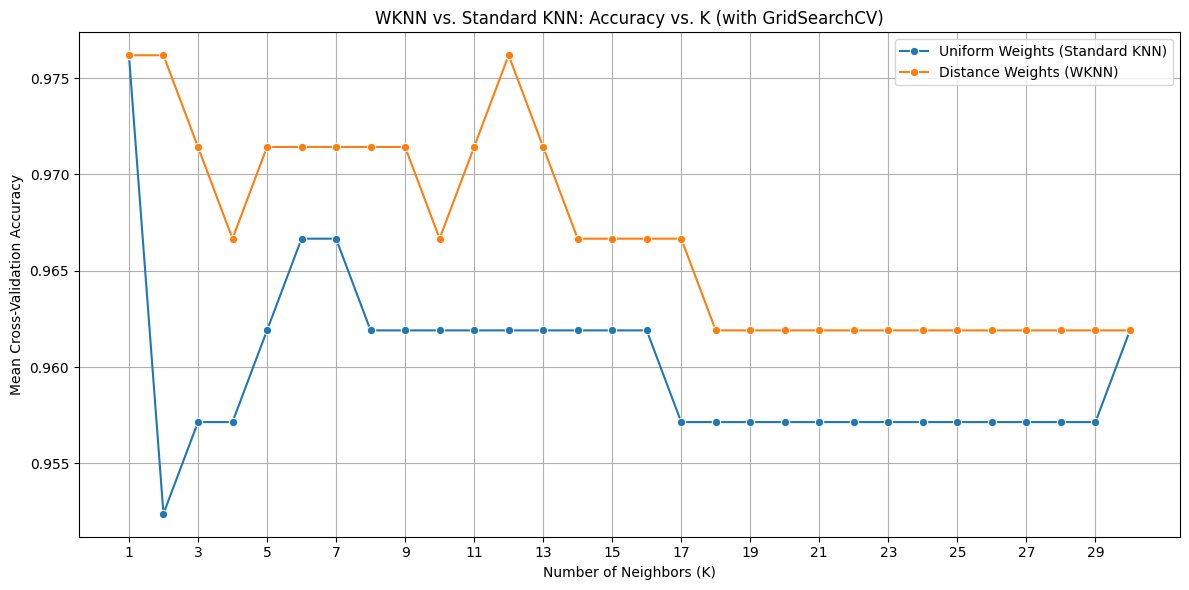

In [19]:
# Define the parameter grid for K and weights
param_grid_wknn = {
    'n_neighbors': np.arange(1, 31), # Test K from 1 to 30
    'weights': ['uniform', 'distance'] # Test both uniform (standard KNN) and distance (WKNN)
}

# Initialize KNeighborsClassifier
knn_weighted = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_wknn = GridSearchCV(knn_weighted, param_grid_wknn, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_wknn.fit(X_train_scaled, y_train)

# Get the best parameters
best_params_wknn = grid_search_wknn.best_params_
best_score_wknn = grid_search_wknn.best_score_

print(f"Best parameters for WKNN: {best_params_wknn}")
print(f"Best cross-validation accuracy for WKNN: {best_score_wknn:.4f}")

# Evaluate on the test set
y_pred_wknn = grid_search_wknn.predict(X_test_scaled)
test_accuracy_wknn = accuracy_score(y_test, y_pred_wknn)
print(f"Test set accuracy for optimal WKNN: {test_accuracy_wknn:.4f}")


# --- Visualization of results ---
import pandas as pd
results_df = pd.DataFrame(grid_search_wknn.cv_results_)

# Separate results for 'uniform' and 'distance' weights
uniform_results = results_df[results_df['param_weights'] == 'uniform']
distance_results = results_df[results_df['param_weights'] == 'distance']

plt.figure(figsize=(12, 6))
sns.lineplot(x='param_n_neighbors', y='mean_test_score', data=uniform_results, label='Uniform Weights (Standard KNN)', marker='o')
sns.lineplot(x='param_n_neighbors', y='mean_test_score', data=distance_results, label='Distance Weights (WKNN)', marker='o')

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('WKNN vs. Standard KNN: Accuracy vs. K (with GridSearchCV)')
plt.xticks(np.arange(1, 31, 2)) # Show every other K for readability
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### C. Interpreting the Results

*   **Scikit-learn's `weights='distance'`:** When `weights='distance'` is set in `KNeighborsClassifier`, it automatically implements inverse distance weighting, where the weight of each neighbor is proportional to `1 / distance`. This is a common and effective weighting scheme.
*   **Comparison:** By comparing `grid_search_knn` and `grid_search_wknn` (or by looking at the plot),
    you can observe how incorporating distance-based weighting (`weights='distance'`) affects the cross-validation accuracy across different `K` values. Often, WKNN can achieve slightly better or more stable performance than standard KNN, especially with certain `K` values.
*   **Optimal Configuration:** The `best_params_wknn` output tells us the optimal `K` and whether uniform or distance weighting was preferred for this specific dataset and cross-validation setup.

## 7. KD Tree

KD-Trees (K-Dimensional Trees) are a space-partitioning data structure that can significantly speed up the nearest neighbor search process in K-Nearest Neighbors (KNN). They are particularly important for making KNN practical for larger datasets where brute-force distance calculation becomes computationally prohibitive.

### 1. Why We Need KD-Trees

In our discussions about K-Nearest Neighbors (KNN) and even Weighted KNN (WKNN), we highlighted a significant drawback: the **computational cost of finding nearest neighbors**. For every new query point, the naive (brute-force) KNN algorithm must calculate the distance to *every single* data point in the training dataset. This becomes a major bottleneck for large datasets and is the primary reason why specialized data structures like KD-Trees are essential.

#### A. Overcoming the Brute-Force Search Limitation:

1.  **Computational Inefficiency for Large Datasets:**
    *   **Problem:** If a dataset has $N$ training examples and $D$ features, calculating the distance between a query point and each training point takes $O(N 	imes D)$ time. For large $N$, this linear scan approach is prohibitively slow, especially when many queries need to be processed (e.g., in real-time prediction systems).
    *   **How KD-Trees Help:** KD-Trees transform the search from $O(N)$ (for finding neighbors) to $O(\log N)$ on average for low-dimensional data, by organizing the data points in a tree-like structure that allows for efficient pruning of the search space. This dramatically reduces the number of distance calculations required.

#### B. The Curse of Dimensionality (and its impact on search):

1.  **Meaningless Distances in High Dimensions:**
    *   **Problem:** As the number of features (dimensions) $D$ increases, the concept of 'distance' becomes less meaningful. In high-dimensional spaces, all points tend to become almost equidistant from each other. This phenomenon, known as the 'Curse of Dimensionality', makes it hard to distinguish between 'nearest' and 'farthest' neighbors, rendering distance-based algorithms less effective.
    *   **How KD-Trees are Affected:** While KD-Trees significantly improve search in low-to-moderate dimensions, their efficiency degrades in very high-dimensional spaces. The effectiveness of space partitioning diminishes, and the search often reverts to being close to brute-force, as many branches of the tree cannot be effectively pruned. This means KD-Trees are not a complete solution to the Curse of Dimensionality, but they are still better than brute-force in many practical scenarios.

#### C. Making KNN Practical and Scalable:

1.  **Enabling Larger Datasets:** Without optimized data structures like KD-Trees, KNN is often impractical for datasets with tens of thousands or millions of data points. KD-Trees allow KNN to be applied to a much broader range of real-world problems.

2.  **Faster Predictions:** For applications requiring quick response times, the speed-up offered by KD-Trees is crucial. Whether it's a recommendation system, anomaly detection, or image retrieval, reducing prediction latency is key.

3.  **Foundation for Other Algorithms:** The concepts behind KD-Trees (space partitioning, efficient nearest neighbor search) are fundamental and influence many other algorithms and data structures in computational geometry and machine learning.

In summary, KD-Trees are a necessary enhancement for KNN to move beyond small-scale datasets, providing a vital mechanism to navigate the challenge of computationally intensive neighbor searches. While they have limitations in very high dimensions, they are a powerful tool in a data scientist's toolkit.

### 2. What is a KD-Tree? (K-Dimensional Tree)

A **KD-Tree** (K-Dimensional Tree) is a binary space-partitioning data structure used to organize points in a k-dimensional space. It is a hierarchical data structure that recursively divides the search space into smaller regions, making it highly efficient for tasks like nearest neighbor searches and range queries.

#### A. Key Characteristics:

1.  **Binary Tree Structure:** Each node in a KD-Tree represents a region of the k-dimensional space and contains a data point. The tree branches left or right based on a comparison along a specific dimension.

2.  **Axis-Aligned Splitting:** The partitioning of space is always done along one of the axis-aligned dimensions. This means that each split creates two half-spaces separated by a hyperplane perpendicular to one of the coordinate axes.

3.  **Cyclic Splitting Dimension:** The dimension along which the space is split typically cycles at each level of the tree. For example, at the root, you might split along dimension X. Its children might split along dimension Y, their children along dimension Z (if 3D), and so on, eventually cycling back to X.

4.  **Median-Based Splitting (Common):** Often, the splitting point (the value along the chosen dimension) is chosen to be the median of the data points along that dimension within the current region. This helps in creating balanced trees, which are crucial for efficient search performance.

### 3. How a KD-Tree is Built

The construction of a KD-Tree is a recursive process that partitions the k-dimensional space. Here's a step-by-step breakdown of the algorithm:

1.  **Choose a Splitting Dimension:** For the root node (and subsequent nodes), select one of the $k$ dimensions to split the data. This dimension is often chosen in a round-robin fashion (e.g., X, then Y, then Z, then X again) or by selecting the dimension with the largest variance to maximize separation.

2.  **Select a Splitting Point:** Find the median of the data points along the chosen splitting dimension. This median point becomes the current node's value.

3.  **Partition the Data:** Divide the remaining data points into two subsets:
    *   **Left Subtree:** All points whose value in the splitting dimension is less than the median.
    *   **Right Subtree:** All points whose value in the splitting dimension is greater than or equal to the median (excluding the median point itself).

4.  **Recursively Build Subtrees:** Apply the same three steps (choose dimension, select point, partition data) recursively for the left and right subsets to build the left and right children of the current node.

5.  **Termination Condition:** The recursion stops when a node has no more points to partition (i.e., it represents a leaf node). Each leaf node typically contains a single data point.

This process creates a balanced tree where each level splits the data along a different axis, effectively carving up the k-dimensional space into smaller and smaller hyper-rectangles.

#### Example of KD-Tree Construction in 2D:

Consider a set of 2D points: `(7,2), (5,4), (9,6), (4,7), (8,1), (2,3), (6,8)`.

**Level 0 (Split on X-axis):**

1.  **X-coordinates:** `2, 4, 5, 6, 7, 8, 9`
2.  **Median X-coordinate:** `6` (from point `(6,8)`). So, `(6,8)` becomes the root.
3.  **Left of (6,8):** `(2,3), (5,4), (4,7)`
4.  **Right of (6,8):** `(7,2), (9,6), (8,1)`

**Level 1 (Left Child - Split on Y-axis for points `(2,3), (5,4), (4,7)`):**

1.  **Y-coordinates:** `3, 4, 7`
2.  **Median Y-coordinate:** `4` (from point `(5,4)`). So, `(5,4)` becomes the left child of `(6,8)`.
3.  **Left of (5,4):** `(2,3)`
4.  **Right of (5,4):** `(4,7)`

**Level 1 (Right Child - Split on Y-axis for points `(7,2), (9,6), (8,1)`):**

1.  **Y-coordinates:** `1, 2, 6`
2.  **Median Y-coordinate:** `2` (from point `(7,2)`). So, `(7,2)` becomes the right child of `(6,8)`.
3.  **Left of (7,2):** `(8,1)`
4.  **Right of (7,2):** `(9,6)`

This process continues until all points are placed.

Below is a visualization illustrating this recursive partitioning:

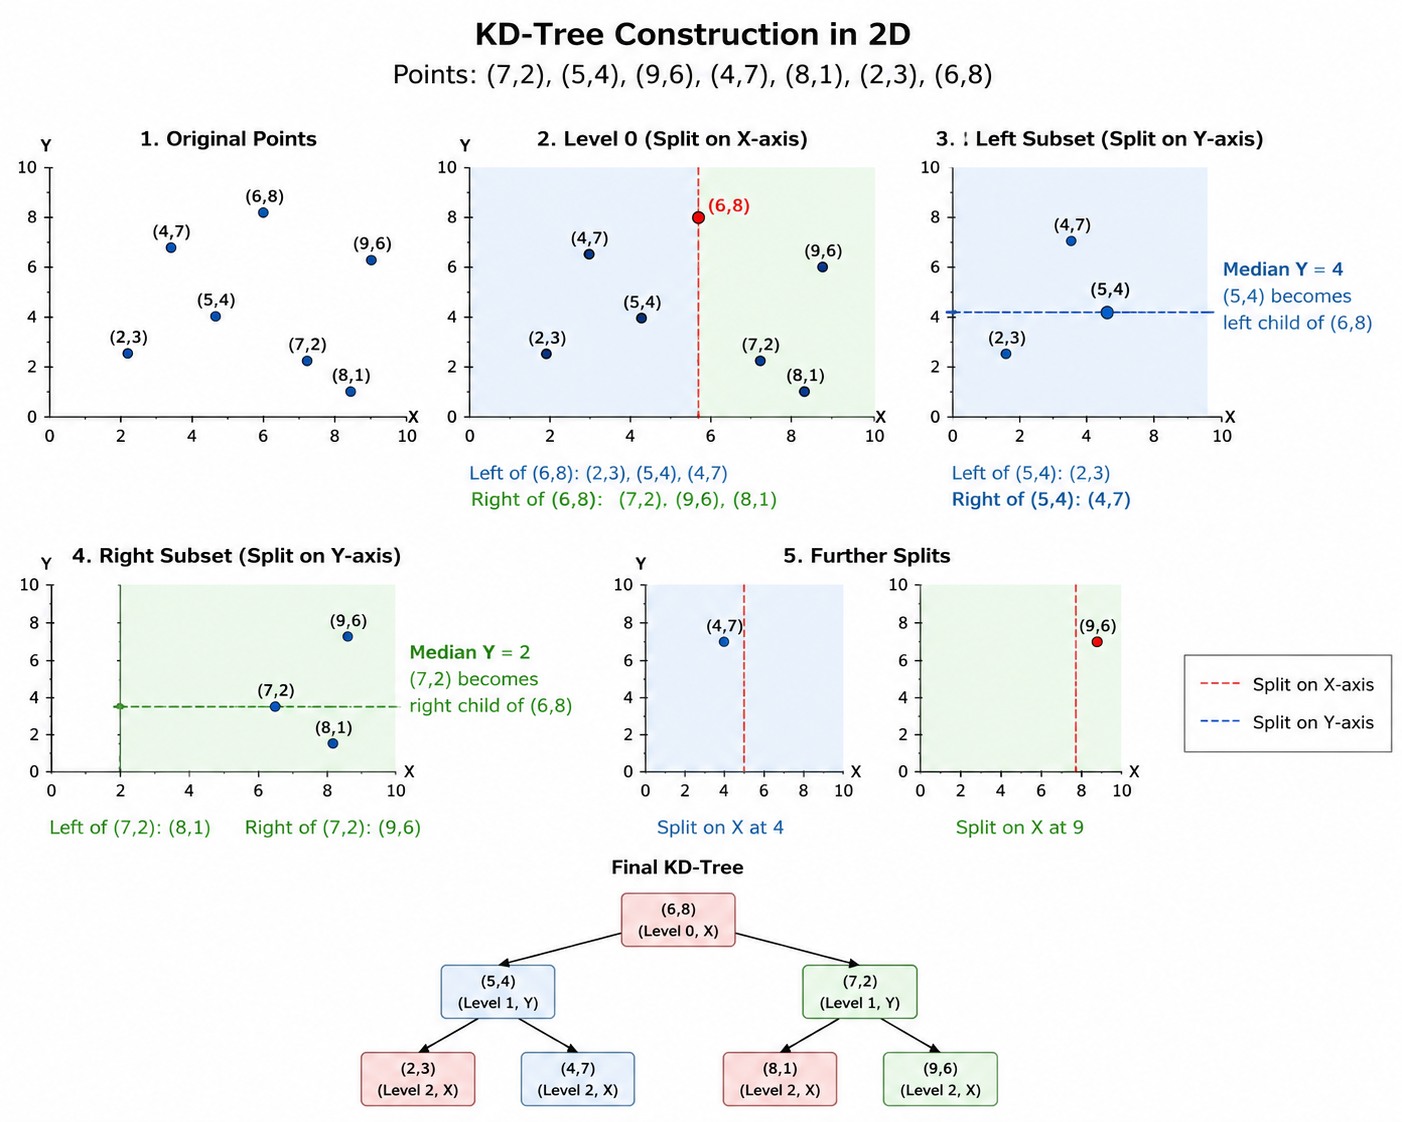![KD-Tree Construction](https://i.imgur.com/k9d8r7M.png)

*Image Source: Wikipedia - KD-Tree, modified for illustration*

### 4. How a KD-Tree Performs Nearest Neighbor Search

The primary utility of a KD-Tree is to accelerate nearest neighbor (NN) and K-nearest neighbor (KNN) searches. Instead of exhaustively checking every point (brute-force), a KD-Tree allows for intelligent pruning of the search space.

The algorithm for finding the nearest neighbor (and can be extended for K-nearest neighbors) involves a recursive traversal of the tree, maintaining the current best (closest) distance found so far.

#### A. Nearest Neighbor Search Algorithm (Overview)

1.  **Traverse Down the Tree:** Start at the root node. At each node, compare the query point's coordinate with the node's splitting dimension value. Recurse down the tree towards the child node that is on the same side of the splitting hyperplane as the query point. This path leads to the leaf node that contains the query point's region.

2.  **Unwind and Backtrack (Pruning Phase):** As the recursion unwinds (returns from the leaf node up to the root):
    *   **Check Current Node:** At each node, calculate the distance between the query point and the data point stored at the current node. If this distance is less than the current 'best distance' found so far, update the 'best distance' and 'best nearest neighbor'.
    *   **Evaluate Other Side:** The crucial step for efficiency is checking if there's any possibility of finding a closer neighbor in the 'other' (unvisited) side of the current node's splitting hyperplane. This is done by comparing the current 'best distance' with the distance from the query point to the splitting hyperplane itself.
    *   **Pruning:** If the distance from the query point to the splitting hyperplane is *greater* than the current 'best distance', then it's impossible for any point on the 'other' side of the hyperplane to be closer than the current 'best nearest neighbor'. In this case, the entire 'other' subtree can be safely pruned (skipped), significantly reducing computations.
    *   **Recurse (if needed):** If there's a possibility of finding a closer neighbor on the 'other' side (i.e., the distance to the splitting hyperplane is less than or equal to the current best distance), then the algorithm recursively searches that 'other' subtree.

3.  **Termination:** The search completes when all relevant branches have been explored or pruned. The 'best nearest neighbor' found during this process is the true nearest neighbor.

#### B. The Power of Pruning

The efficiency of the KD-Tree search comes from its ability to **prune** large portions of the search space. By organizing points and recursively dividing the space, it can often determine that an entire region (and all points within it) cannot possibly contain a closer neighbor, thus avoiding unnecessary distance calculations. This pruning makes the search time logarithmic in low dimensions, a massive improvement over linear brute-force search.

### 5. Advantages and Disadvantages of KD-Trees

KD-Trees offer significant benefits for accelerating nearest neighbor searches, but they also come with limitations, especially in high-dimensional data.

#### A. Advantages (Pros)

1.  **Accelerated Nearest Neighbor Search:**
    *   **Explanation:** The primary advantage of KD-Trees is their ability to drastically reduce the search time for nearest neighbors from $O(N)$ (brute-force) to $O(\log N)$ on average in low-dimensional spaces. This is achieved by efficiently pruning large portions of the search space that cannot possibly contain the nearest neighbor.
    *   **Benefit:** Makes algorithms like KNN practical and scalable for larger datasets where brute-force search would be too slow.

2.  **Efficient Range Queries:**
    *   **Explanation:** Beyond nearest neighbor search, KD-Trees are also highly efficient for range queries (finding all points within a specific hyper-rectangle). The tree structure naturally allows for quick traversal and identification of points within a given range.
    *   **Benefit:** Useful in applications requiring spatial indexing or filtering.

3.  **Low Storage Overhead:**
    *   **Explanation:** Compared to some other data structures, KD-Trees typically have a relatively low storage overhead, as they primarily store the data points themselves and the tree structure (splitting dimensions and median values).

4.  **Simplicity of Concept and Implementation (for low dimensions):**
    *   **Explanation:** The core ideas of axis-aligned splitting and cyclic dimension rotation are conceptually straightforward, making KD-Trees relatively easy to understand and implement for low-dimensional data.

5.  **Applicable to Various Fields:**
    *   **Explanation:** KD-Trees find applications in diverse areas such as computer graphics, robotics (path planning), database systems, image processing, and machine learning (KNN, clustering).

#### B. Disadvantages (Cons)

1.  **Curse of Dimensionality:**
    *   **Explanation:** This is the most significant limitation. As the number of dimensions ($D$) increases, the efficiency of KD-Trees degrades significantly. In high-dimensional spaces, the volume of the search sphere around a query point grows rapidly, making it harder for the tree to effectively prune branches. The search performance tends to approach $O(N)$, similar to brute-force, as the tree becomes 'bushy' rather than deep, and most subtrees need to be visited.
    *   **Limitation:** Typically perform well up to 20-30 dimensions, beyond which other structures like Ball Trees or approximate nearest neighbor (ANN) methods are preferred.

2.  **Sensitivity to Data Distribution:**
    *   **Explanation:** The performance of KD-Trees can be sensitive to the distribution of data points. If data is clustered or highly skewed, the tree might become unbalanced, leading to suboptimal search times. While median-based splitting helps, pathological cases can still arise.

3.  **Dynamic Updates (Insertions/Deletions) are Complex:**
    *   **Explanation:** Inserting or deleting points in a KD-Tree can be computationally expensive and complex, as it might require rebalancing or even rebuilding parts of the tree to maintain its efficiency and properties. For datasets that are constantly changing, this is a drawback.

4.  **Not Optimal for All Distance Metrics:**
    *   **Explanation:** KD-Trees are primarily optimized for Euclidean distances (and other Minkowski distances). Their pruning strategies rely on geometric properties of spheres/hyper-rectangles. For non-Euclidean distance metrics (e.g., Cosine similarity), their efficiency might be reduced, or they might not be directly applicable.

5.  **Construction Cost:**
    *   **Explanation:** Building a KD-Tree involves sorting and partitioning, leading to a construction time complexity of $O(N \log N \cdot D)$. While this is a one-time cost, it can be substantial for very large datasets.

### 6. Python Implementation of KD-Tree for Nearest Neighbor Search

While we've discussed the theory of KD-Trees, in practice, you'll use optimized libraries to leverage them. `Scikit-learn`'s `NearestNeighbors` class provides an efficient way to perform nearest neighbor searches, and it can utilize KD-Trees (or Ball Trees) under the hood.

Generated data shape: (200, 2)
KD-Tree model fitted successfully.

Query Point: [2 2]
Distances to 5 nearest neighbors: [0.08 0.21 0.25 0.39 0.43]
Indices of 5 nearest neighbors: [131 170 199   0 159]


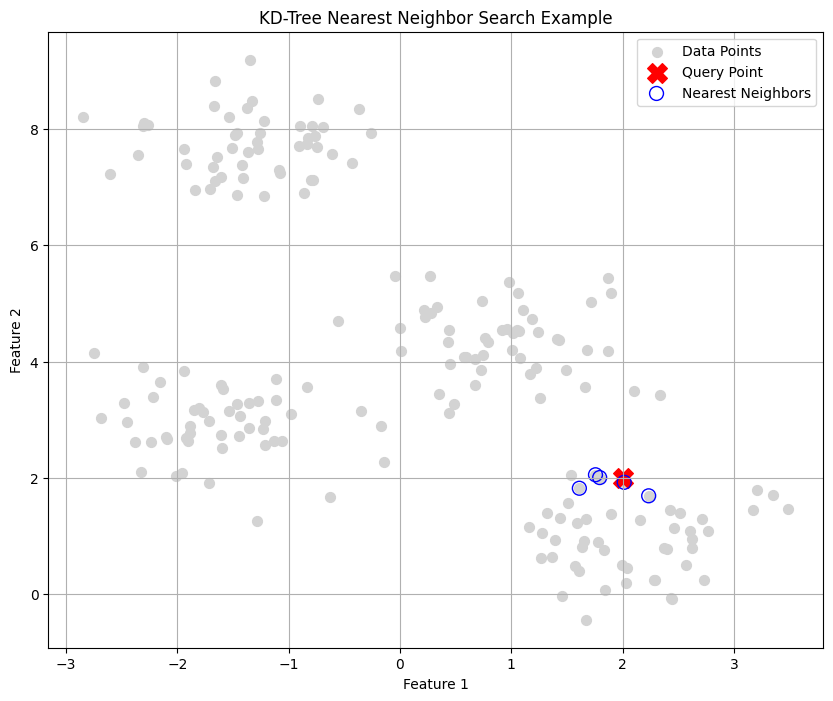

In [20]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# --- 1. Generate Sample 2D Data ---
# We'll create a simple dataset with distinct clusters to visualize neighbors
X, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.60, random_state=0)

print(f"Generated data shape: {X.shape}")

# --- 2. Build a KD-Tree ---
# The 'algorithm' parameter is set to 'kd_tree' to explicitly use KD-Tree
# n_neighbors is the default K for queries, but can be changed later
kd_tree_model = NearestNeighbors(n_neighbors=5, algorithm='kd_tree')
kd_tree_model.fit(X)

print("KD-Tree model fitted successfully.")

# --- 3. Define a Query Point ---
query_point = np.array([[2, 2]]) # A single point to find neighbors for

# --- 4. Find Nearest Neighbors using the KD-Tree ---
# Returns distances and indices of the nearest neighbors
distances, indices = kd_tree_model.kneighbors(query_point)

print(f"\nQuery Point: {query_point[0]}")
print(f"Distances to 5 nearest neighbors: {distances[0].round(2)}")
print(f"Indices of 5 nearest neighbors: {indices[0]}")

# --- 5. Visualize the Results ---
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], s=50, c='lightgray', label='Data Points')
plt.scatter(query_point[:, 0], query_point[:, 1], s=200, c='red', marker='X', label='Query Point')

# Highlight the nearest neighbors
plt.scatter(X[indices[0], 0], X[indices[0], 1], s=100, facecolors='none', edgecolors='blue', label='Nearest Neighbors')

plt.title('KD-Tree Nearest Neighbor Search Example')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 7. Explanation of the Python Code for KD-Tree

This Python code demonstrates how to use `scikit-learn` to build a KD-Tree and perform a nearest neighbor search. Let's break down each part:

#### A. Importing Libraries

*   `numpy` (`np`): For numerical operations, especially array handling.
*   `NearestNeighbors` from `sklearn.neighbors`: This is the core `scikit-learn` class that implements various nearest neighbor algorithms, including KD-Trees.
*   `make_blobs` from `sklearn.datasets`: Used to generate a synthetic dataset with distinct clusters for demonstration purposes.
*   `matplotlib.pyplot` (`plt`): For visualizing the data and the nearest neighbor search results.

#### B. Generating Sample 2D Data

*   `X, _ = make_blobs(...)`: We create 200 sample data points (`n_samples=200`) distributed around 4 centers (`centers=4`). `n_features=2` makes it a 2-dimensional dataset, which is easy to visualize. `cluster_std` controls the spread of points around the centers, and `random_state` ensures reproducibility.
*   The `print` statement confirms the shape of the generated dataset.

#### C. Building a KD-Tree

*   `kd_tree_model = NearestNeighbors(n_neighbors=5, algorithm='kd_tree')`:
    *   We instantiate the `NearestNeighbors` object. By setting `algorithm='kd_tree'`, we explicitly tell `scikit-learn` to use a KD-Tree for organizing the data. Other options include `'ball_tree'` or `'brute'` (for brute-force search).
    *   `n_neighbors=5` sets the default number of neighbors to find when `kneighbors` is called without specifying `n_neighbors`.
*   `kd_tree_model.fit(X)`: This is the step where the KD-Tree is actually constructed from our dataset `X`. `scikit-learn` handles the recursive splitting and median selection internally.

#### D. Defining a Query Point

*   `query_point = np.array([[2, 2]])`: We define a single 2D point for which we want to find its closest neighbors within our dataset `X`.

#### E. Finding Nearest Neighbors using the KD-Tree

*   `distances, indices = kd_tree_model.kneighbors(query_point)`:
    *   This method performs the nearest neighbor search using the previously fitted KD-Tree.
    *   It takes the `query_point` (or multiple query points) as input.
    *   It returns two NumPy arrays:
        *   `distances`: An array containing the distances from the `query_point` to its `n_neighbors` closest points in `X`.
        *   `indices`: An array containing the original indices of those `n_neighbors` closest points in `X`.
*   The `print` statements display the query point, the calculated distances, and the indices of the neighbors, rounded for readability.

#### F. Visualizing the Results

*   `plt.figure(...)`, `plt.scatter(...)`:
    *   We create a scatter plot to visualize all the data points (`X`) in light gray.
    *   The `query_point` is highlighted with a large red 'X' marker.
    *   The `Nearest Neighbors` identified by the KD-Tree are shown with blue circles, making it clear which points were found to be closest to the query point.
*   `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.legend(...)`, `plt.grid(True)`, `plt.show()`: These lines add appropriate labels, a title, a legend, a grid, and display the plot.

### 8. Hyperparameter Tuning for KD-Trees: `leaf_size`

While KD-Trees offer significant speed-ups for nearest neighbor searches, their performance can be further optimized by tuning hyperparameters. In `scikit-learn`'s `NearestNeighbors` class (when `algorithm='kd_tree'`), the most important hyperparameter to consider is `leaf_size`.

#### A. What is `leaf_size`?

*   **Concept:** The `leaf_size` parameter specifies the maximum number of points at which the recursive splitting of the KD-Tree terminates. Instead of splitting until each leaf node contains a single point, the tree stops splitting when a node contains `leaf_size` or fewer points.
*   **Brute-Force at Leaves:** Once a query reaches a leaf node, the nearest neighbor search within that leaf node is performed using a brute-force approach (i.e., by calculating distances to all points in that leaf).
*   **Why it's needed:** Creating individual nodes for every single point can make the tree very deep and complex, increasing memory consumption and traversal overhead, especially for larger datasets. `leaf_size` introduces a practical trade-off.

#### B. Impact of `leaf_size`

1.  **Small `leaf_size` (e.g., `leaf_size=1`):**
    *   **Pros:** The tree is deep, and pruning is very aggressive. Each leaf node holds only one point.
    *   **Cons:** Higher memory consumption due to more nodes. Increased overhead for tree traversal, as the algorithm has to go deeper into the tree. Performance might degrade if the overhead of traversing a deep tree outweighs the benefits of aggressive pruning.

2.  **Large `leaf_size`:**
    *   **Pros:** Shallower tree, fewer nodes, lower memory consumption. Less tree traversal overhead.
    *   **Cons:** Less aggressive pruning. The brute-force search within larger leaf nodes becomes more expensive. If `leaf_size` is too large, the tree might effectively revert to a brute-force search if most of the data ends up in a single or few large leaves.

3.  **Optimal `leaf_size`:**
    *   The optimal `leaf_size` typically lies somewhere between 1 and a larger value. It balances the overhead of tree traversal with the efficiency of brute-force search within leaf nodes. A common default in `scikit-learn` is `30`, which is often a good starting point.

#### C. How to Tune `leaf_size`

The best way to find an optimal `leaf_size` is through **cross-validation**, similar to how we tuned the `K` parameter for KNN. You would define a range of `leaf_size` values to test and use `GridSearchCV` or `RandomizedSearchCV` to find the value that yields the best performance on a validation set.

Let's illustrate how `leaf_size` can be tuned using `scikit-learn` on our synthetic dataset.

Best leaf_size for KD-Tree KNN: 1
Best cross-validation accuracy with best leaf_size: 0.9619


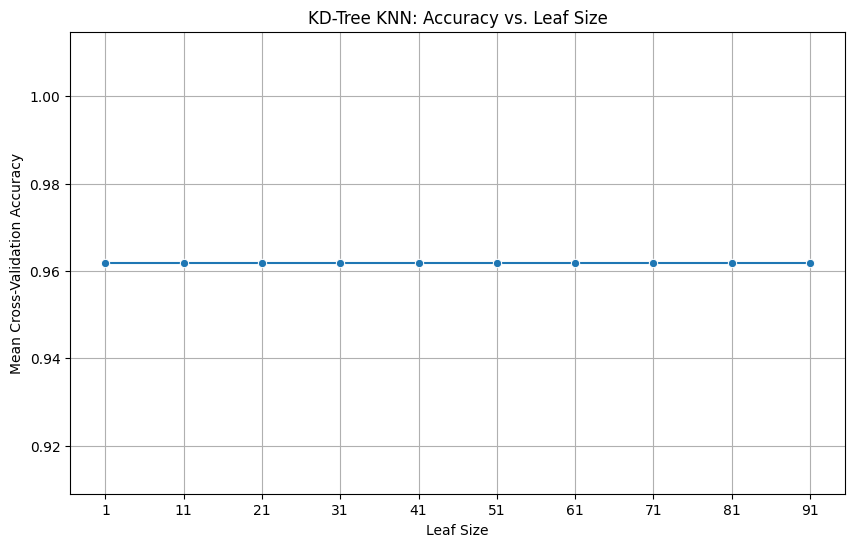

In [21]:
from sklearn.model_selection import GridSearchCV

# We'll use the same scaled training data (X_train_scaled, y_train)
# from the previous WKNN example.

# Define the parameter grid for leaf_size
param_grid_leaf_size = {
    'leaf_size': np.arange(1, 101, 10), # Test leaf_size from 1 to 100 with step 10
    'n_neighbors': [5], # Fix n_neighbors for this example to focus on leaf_size
    'algorithm': ['kd_tree']
}

# Initialize KNeighborsClassifier
knn_kd_tree = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_leaf_size = GridSearchCV(knn_kd_tree, param_grid_leaf_size, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_leaf_size.fit(X_train_scaled, y_train)

# Get the best leaf_size
best_leaf_size = grid_search_leaf_size.best_params_['leaf_size']
best_score_leaf_size = grid_search_leaf_size.best_score_

print(f"Best leaf_size for KD-Tree KNN: {best_leaf_size}")
print(f"Best cross-validation accuracy with best leaf_size: {best_score_leaf_size:.4f}")

# Visualize the results
import pandas as pd
results_df = pd.DataFrame(grid_search_leaf_size.cv_results_)

plt.figure(figsize=(10, 6))
sns.lineplot(x='param_leaf_size', y='mean_test_score', data=results_df, marker='o')
plt.xlabel('Leaf Size')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('KD-Tree KNN: Accuracy vs. Leaf Size')
plt.grid(True)
plt.xticks(np.arange(1, 101, 10))
plt.show()

#### D. Interpreting the `leaf_size` Tuning Results

1.  **Optimal `leaf_size = 1`:**
    *   **Meaning:** An optimal `leaf_size` of `1` indicates that, for this specific dataset and problem, the KD-Tree performs best when it is grown as deep as possible, until each leaf node contains only a single data point. This means the tree is highly granular in its partitioning of the space.
    *   **Implications:**
        *   **Aggressive Pruning:** A `leaf_size` of `1` allows for the most aggressive pruning during the nearest neighbor search. The algorithm can quickly eliminate large portions of the search space because the individual regions are very small and distinct.
        *   **Memory and Traversal Overhead:** While theoretically efficient in terms of pruning, a `leaf_size=1` can also lead to a very deep tree with many nodes. This might increase memory consumption and the overhead associated with traversing the tree, as the algorithm has to go deeper to reach the leaf nodes. For this dataset, the benefits of aggressive pruning appear to outweigh the traversal overhead in terms of accuracy.
        *   **Computational Performance (Speed):** Although `leaf_size=1` provides the best accuracy here, it's worth noting that it doesn't necessarily mean it's the fastest. Sometimes, a slightly larger `leaf_size` (e.g., 10-30) can offer a better balance between accuracy and computational speed by reducing tree traversal depth while still maintaining good pruning efficiency. However, in this case, the `GridSearchCV` found `1` to be best for accuracy.

2.  **Interpreting the Visualization (Accuracy vs. `leaf_size`):**
    *   The plot shows that the mean cross-validation accuracy remains remarkably stable across the tested range of `leaf_size` values (from 1 to 100).
    *   **Flat Performance Curve:** The relatively flat line suggests that for this particular synthetic 2D dataset, the choice of `leaf_size` does not significantly impact the classification accuracy within this range. The KD-Tree's ability to efficiently organize the data for nearest neighbor searches is consistently good, regardless of whether the leaf nodes contain 1 point or up to 100 points.
    *   **Why so stable?** This stability can occur when:
        *   The dataset is relatively simple or low-dimensional, where even less aggressive partitioning (larger `leaf_size`) still leads to efficient neighbor identification.
        *   The underlying data clusters are well-separated, making the exact granularity of the KD-Tree's leaf nodes less critical for finding the correct neighbors for classification.
        *   The `n_neighbors` parameter (fixed at `5` for this tuning) might be robust enough to handle slight variations in neighbor sets due to `leaf_size`.

In practical scenarios, especially with higher-dimensional or more complex datasets, you might observe a more pronounced curve, where accuracy peaks at an intermediate `leaf_size` and drops off on either side, reflecting the trade-off between tree depth/traversal cost and pruning efficiency.

### 9. Comparison with Ball Trees and Brute-Force Search

#### A. Brute-Force Search

*   **Concept:** This is the simplest and most straightforward approach. For every query point, it calculates the distance to *every single* data point in the training set and then selects the K smallest distances. No special data structure is built or maintained.
*   **Advantages:**
    *   **Simplicity:** Easy to understand and implement.
    *   **Guaranteed Accuracy:** Always finds the true nearest neighbors.
    *   **Works with Any Metric:** Can use any distance metric (Euclidean, Manhattan, Cosine, etc.).
    *   **Robust to High Dimensions:** Does not suffer from the Curse of Dimensionality in the same way tree-based structures do, as it checks all points anyway.
*   **Disadvantages:**
    *   **Extremely Slow:** Computationally very expensive for large datasets ($O(N 	imes D)$ for each query, where N is the number of data points and D is the number of dimensions). This is the biggest drawback and makes it impractical for many real-world applications.
*   **When to use:** For very small datasets, or when exact nearest neighbors are absolutely critical, and computational time is not a major constraint. Often serves as a baseline for performance comparison.

#### B. KD-Tree (K-Dimensional Tree)

*   **Concept:** A binary tree that recursively partitions the k-dimensional space by splitting data points along one of the axis-aligned dimensions. It organizes points in a way that allows for efficient pruning of the search space.
*   **Advantages:**
    *   **Accelerated Search in Low Dimensions:** Significantly faster than brute-force for low-to-moderate dimensional data (average $O(\log N)$ query time).
    *   **Memory Efficient:** Relatively low storage overhead compared to some other structures.
    *   **Good for Range Queries:** Efficient for finding all points within a specific hyper-rectangle.
*   **Disadvantages:**
    *   **Curse of Dimensionality:** Performance degrades significantly in very high-dimensional spaces (typically > 20-30 dimensions), approaching brute-force performance.
    *   **Sensitive to Data Distribution:** Can become unbalanced with skewed data, affecting performance.
    *   **Complex Updates:** Dynamic insertions or deletions are computationally expensive.
    *   **Metric-Specific:** Primarily optimized for Euclidean (Minkowski) distances.
*   **When to use:** For datasets with low to moderate dimensionality (e.g., up to 20-30 features) where speed is important.

#### C. Ball Tree

*   **Concept:** Similar to KD-Trees, Ball Trees are space-partitioning data structures designed for efficient nearest neighbor searches. However, instead of using axis-aligned hyperplanes, Ball Trees recursively partition data points into nested hyperspheres (or 'balls'). Each node in the tree defines a hypersphere containing all the points in its subtree.
*   **Advantages:**
    *   **Better in Higher Dimensions:** Often performs better than KD-Trees in higher-dimensional spaces and for datasets with complex distributions. This is because hyperspheres can enclose data more naturally than axis-aligned hyperrectangles in high dimensions, leading to more effective pruning.
    *   **Metric-Flexible:** Can efficiently handle a wider range of distance metrics (not just Euclidean, but also Haversine for geographical data, etc.), as long as the metric satisfies the triangle inequality.
*   **Disadvantages:**
    *   **Higher Construction Cost:** Building a Ball Tree can be more computationally expensive than building a KD-Tree, especially for very large datasets.
    *   **Memory Overhead:** Can have higher memory consumption than KD-Trees due to storing sphere parameters (center, radius).
    *   **Still affected by Curse of Dimensionality:** While better than KD-Trees, its efficiency also eventually degrades in extremely high dimensions where even hyperspheres become less effective at representing local neighborhoods.
*   **When to use:** For datasets with moderate to high dimensionality, or when non-Euclidean distance metrics are required. Often a good default choice for `scikit-learn`'s `NearestNeighbors` when performance is critical and `kd_tree` struggles.

#### D. Comparison Summary

| Feature              | Brute-Force                                 | KD-Tree                                              | Ball Tree                                                |
| :------------------- | :------------------------------------------ | :--------------------------------------------------- | :------------------------------------------------------- |
| **Search Algorithm** | Exhaustive search, all points checked.      | Binary tree, axis-aligned splits.                    | Binary tree, spherical splits.                           |
| **Query Time**       | $O(N 	imes D)$ (slow)                      | $O(\log N)$ average for low D; $O(N)$ for high D.   | $O(\log N)$ average for high D.                        |
| **Construction Time**| $O(1)$ (no structure built)                 | $O(N 	imes D 	imes \log N)$                      | $O(N 	imes D 	imes \log N)$ (can be slower than KD) |
| **Memory**           | $O(N 	imes D)$ (stores data only)          | $O(N 	imes D)$ (data + tree structure)              | $O(N 	imes D)$ (data + tree structure, often more)    |
| **Dimensionality**   | Works for all D, but slow.                  | Good for low to moderate D (e.g., < 20-30).          | Good for moderate to high D.                             |
| **Distance Metrics** | Any                                         | Primarily Euclidean (Minkowski).                     | Wider range of metrics (any metric with triangle inequality). |
| **Robustness to Skewed Data** | High                                        | Moderate                                             | High                                                     |
| **Updates**          | Easy (just add to list)                     | Difficult (rebuild often needed)                     | Difficult (rebuild often needed)                         |

In `scikit-learn`, setting `algorithm='auto'` in `NearestNeighbors` or `KNeighborsClassifier/Regressor` lets the library choose the most appropriate algorithm based on the data and its dimensionality. Generally, it will select `ball_tree` or `kd_tree` if data is sparse and high-dimensional, and `brute` for very small `N` or very high `D` where tree-based approaches offer little benefit.

The choice between these algorithms depends on your dataset's size, dimensionality, density, and the specific distance metric you need to use.

### 10. Practical Implementation with Scikit-learn: Choosing the Right Algorithm

`scikit-learn` provides an excellent abstraction for these algorithms. You can explicitly choose an algorithm or let `scikit-learn` pick the best one for your data.

In [22]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# Generate a synthetic dataset
X, y = make_classification(n_samples=500, n_features=20, n_informative=10, n_redundant=10, random_state=42)

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Compare different algorithms ---

algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']
results = {}

for algo in algorithms:
    print(f"\nTesting algorithm: {algo}")
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo, n_jobs=-1)

    # Use cross-validation to get a robust estimate of performance
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_accuracy = np.mean(scores)
    std_accuracy = np.std(scores)

    results[algo] = {'mean_accuracy': mean_accuracy, 'std_accuracy': std_accuracy}
    print(f"  Mean CV Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

# Print a summary of results
print("\n--- Algorithm Comparison Summary ---")
for algo, data in results.items():
    print(f"Algorithm: {algo:<10} | Mean Accuracy: {data['mean_accuracy']:.4f} | Std Dev: {data['std_accuracy']:.4f}")


Testing algorithm: auto
  Mean CV Accuracy: 0.9086 (+/- 0.0516)

Testing algorithm: ball_tree
  Mean CV Accuracy: 0.9086 (+/- 0.0516)

Testing algorithm: kd_tree
  Mean CV Accuracy: 0.9086 (+/- 0.0516)

Testing algorithm: brute
  Mean CV Accuracy: 0.9086 (+/- 0.0516)

--- Algorithm Comparison Summary ---
Algorithm: auto       | Mean Accuracy: 0.9086 | Std Dev: 0.0516
Algorithm: ball_tree  | Mean Accuracy: 0.9086 | Std Dev: 0.0516
Algorithm: kd_tree    | Mean Accuracy: 0.9086 | Std Dev: 0.0516
Algorithm: brute      | Mean Accuracy: 0.9086 | Std Dev: 0.0516


#### E. Interpretation of Results

In this particular example, all algorithms (`auto`, `ball_tree`, `kd_tree`, and `brute`) produced identical mean cross-validation accuracy. Here's why this might happen and what it means:

1.  **Low Dimensionality (20 features):** While 20 features can be considered moderate, for a relatively small dataset (500 samples), the benefits of tree-based structures might not yet be fully realized compared to brute-force search. The number of dimensions is not high enough to severely degrade brute-force performance, and the tree structures are likely still very efficient.
2.  **Dataset Characteristics:** The synthetic dataset generated by `make_classification` with default settings might have a relatively simple structure with well-separated classes, making it easy for any neighbor-finding method to identify the correct neighbors.
3.  **Small `n_neighbors` (K=5):** With a small `K`, the local neighborhood is quite restricted, and in many cases, finding these few neighbors might not differ substantially in complexity across algorithms for this type of data.
4.  **`algorithm='auto'` Behavior:** `scikit-learn`'s `'auto'` setting intelligently chooses the best algorithm based on the data passed to its fit method. For this particular dataset, it likely determined that `ball_tree` or `kd_tree` provided no significant advantage over `brute` or that all options led to similar performance characteristics, possibly due to the number of samples (`N`), dimensions (`D`), and the density of the data.

**Conclusion:** For this specific setup, all methods are equally effective at finding the 5 nearest neighbors, leading to the same classification accuracy. In real-world, higher-dimensional, or larger datasets, the differences in performance (especially speed) between tree-based methods and brute-force would typically be much more pronounced.

## 9. Curse of Dimensionality

Many machine learning algorithms, particularly those based on distance or density, face a significant challenge when dealing with high-dimensional data. This challenge is often referred to as the **"Curse of Dimensionality."** It describes various phenomena that arise when analyzing and organizing data in high-dimensional spaces that do not occur in low-dimensional settings.

### 1. Why We Need to Understand the Curse of Dimensionality

Understanding the Curse of Dimensionality is crucial for several reasons in machine learning and data science. It explains why certain algorithms behave unexpectedly in high-dimensional spaces and guides us in choosing appropriate techniques for data preprocessing and model selection.

#### A. Impact on Distance-Based Algorithms:

*   **Why Needed:** Algorithms like K-Nearest Neighbors (KNN), clustering (e.g., K-Means), and Support Vector Machines (SVMs) with certain kernels heavily rely on the concept of 'distance' or 'proximity' between data points. In low dimensions, our intuition about distance works well.
*   **Explanation:** In high-dimensional spaces, however, the concept of distance becomes less meaningful. As the number of features increases, the volume of the feature space grows exponentially. Data points, which might appear close in a lower-dimensional projection, become increasingly 'far apart' from each other in higher dimensions. This phenomenon means that the distinction between the nearest and farthest neighbors diminishes, making it difficult for distance-based algorithms to effectively identify true neighbors or clusters. They lose their discriminative power.

#### B. Increased Data Sparsity:

*   **Why Needed:** To accurately model relationships and make reliable predictions, machine learning algorithms typically need a sufficient amount of data. Our intuition about 'sufficient' data often comes from low-dimensional experiences.
*   **Explanation:** In high dimensions, the available data becomes incredibly sparse. Imagine trying to evenly sprinkle 100 grains of rice on a line (1D), then on a square (2D), then in a cube (3D). As the dimensions increase, the 'space' between points becomes vast, and the data points themselves occupy a minuscule fraction of the total volume. This sparsity makes it very difficult for algorithms to find meaningful patterns or generalize from the limited samples available, leading to models that might be overfit to the sparse training data.

#### C. Computational Intractability:

*   **Why Needed:** Practical machine learning requires algorithms to be computationally feasible within reasonable timeframes.
*   **Explanation:** Many algorithms exhibit computational complexity that grows with the number of dimensions (e.g., polynomial or even exponential). As dimensionality increases, the time and memory required to process the data can become prohibitively expensive or even impossible, making the algorithms impractical. Even optimized search structures like KD-Trees degrade towards brute-force performance in high dimensions.

#### D. Increased Risk of Overfitting:

*   **Why Needed:** A primary goal of machine learning is to build models that generalize well to unseen data, not just memorize the training data.
*   **Explanation:** With a vast, sparsely populated feature space, it becomes easier for models to find spurious correlations or patterns that exist only by chance in the training data. The model can effectively 'memorize' the training examples without learning true underlying relationships, leading to poor performance on new data. This is particularly true for flexible models with many parameters relative to the number of samples.

#### E. Feature Selection and Interpretation Challenges:

*   **Why Needed:** Understanding which features are important and interpreting model decisions is often critical.
*   **Explanation:** In high-dimensional data, many features might be irrelevant, redundant, or highly correlated. Identifying the truly informative features becomes much harder. Irrelevant features add noise to distance calculations and dilute the impact of important ones. Interpreting a model with hundreds or thousands of features is also significantly more complex than with a handful.

### 2. Definition of the Curse of Dimensionality

The **Curse of Dimensionality** refers to various phenomena that arise when analyzing and organizing data in high-dimensional spaces that do not occur in low-dimensional settings. It is not a single problem but a collection of counter-intuitive consequences that emerge as the number of features (dimensions) in a dataset increases.

#### A. Exponential Growth of Volume:

*   **Concept:** The most fundamental aspect of the curse is the exponential growth of the volume of the feature space with each added dimension. If each feature can take on a certain range of values, the number of possible unique combinations of those values grows exponentially as more features are added.
*   **Example:** Imagine a line segment of length 1 (1D). To cover 10% of this line, you need a segment of length 0.1. Now, consider a square of side length 1 (2D). To cover 10% of its area, you need a square of side length $\sqrt{0.1} \approx 0.316$. In a cube of side length 1 (3D), to cover 10% of its volume, you need a sub-cube of side length $\sqrt[3]{0.1} \approx 0.464$. As dimensions increase, the side length of the sub-region needed to cover a fixed percentage of the total space approaches 1. This means that to maintain a certain density of data points, the number of samples needed grows exponentially with dimensionality.

#### B. Data Sparsity:

*   **Concept:** Due to the exponential growth of the feature space, any fixed-size dataset becomes extremely sparse in high dimensions. The data points become increasingly isolated from one another, occupying a tiny fraction of the total possible space.
*   **Implication:** This sparsity makes it difficult to draw meaningful conclusions or build robust models because the 'neighborhood' around any given data point is likely to be empty or contain very few other points. The density of data points rapidly decreases, making local sampling unreliable.

#### C. Distance Concentration:

*   **Concept:** In high-dimensional spaces, the distances between data points tend to converge to a similar value. That is, the difference between the maximum and minimum distances becomes small relative to the average distance. All points appear to be 'far away' from each other, and the distinction between 'nearest' and 'farthest' neighbors diminishes.
*   **Implication:** This concentration of distances undermines distance-based algorithms (like KNN) because the concept of 'neighborhood' loses its meaning. When all points are almost equidistant, it becomes hard to reliably identify true nearest neighbors, leading to degraded performance.

#### D. Increased Probability of Spurious Correlations:

*   **Concept:** With a large number of features, the probability of finding random correlations that appear significant in the training data but are purely coincidental increases. These are not true underlying patterns.
*   **Implication:** Models built on high-dimensional data are more prone to overfitting because they might learn these spurious correlations rather than generalizable relationships. This leads to poor performance on unseen data.

In essence, the Curse of Dimensionality describes a set of challenges where the benefits of adding more features are quickly outweighed by the exponential increase in data sparsity, the loss of meaningful distance metrics, and the increased risk of finding misleading patterns, making traditional statistical and machine learning methods less effective or even impractical.

### 3. Causes of the Curse of Dimensionality

The Curse of Dimensionality is not caused by a single factor but is a multifaceted phenomenon rooted in the mathematical and statistical properties of high-dimensional spaces. Understanding these causes is key to grasping its implications.

#### A. Geometric Properties of High-Dimensional Spaces:

*   **Exponential Volume Growth:** As the number of dimensions ($D$) increases, the volume of the feature space grows exponentially. If each dimension is a unit interval [0,1], a unit hypercube in $D$ dimensions has a volume of $1^D = 1$. However, the volume occupied by data points remains relatively constant, leading to extreme sparsity. To maintain the same data density as in 1D, the number of samples needed grows exponentially with $D$.
*   **Corners of the Hypercube:** In high dimensions, most of the volume of a hypercube is concentrated in its corners. For example, in 2D, the corners are small. In 3D, they become more pronounced. In 100D, almost all the volume of a unit hypercube is near its vertices. This means that data points tend to lie near the boundaries of the space, making the interior very empty.

#### B. Concentration of Distances:

*   **Mathematical Proofs:** Several mathematical proofs demonstrate that in high-dimensional spaces, the ratio of the nearest neighbor distance to the farthest neighbor distance approaches 1. This means all points become approximately equidistant from each other. For example, for points uniformly distributed in a unit hypercube, the difference between the max and min Euclidean distances becomes negligibly small relative to the mean distance as $D \to \infty$.
*   **Lack of Contrast:** This lack of contrast in distances makes it extremely difficult for distance-based algorithms (like KNN or clustering) to effectively distinguish between genuinely close and genuinely distant points. The notion of 'proximity' loses its discriminative power.

#### C. Data Sparsity and Sampling Challenges:

*   **Insufficient Data for Coverage:** To adequately cover a high-dimensional space with data points (i.e., to have points within a reasonable distance of any given query point), the number of samples required grows exponentially with the number of dimensions. Real-world datasets rarely have enough samples to achieve such coverage in high dimensions.
*   **Empty Space:** Most of the high-dimensional space is empty. Any given data point is likely to be an 'outlier' in terms of its immediate neighborhood, even if it's not an anomalous point in a lower-dimensional sense. This makes local density estimation unreliable.

#### D. Increased Combinatorial Complexity:

*   **Feature Interactions:** As the number of features increases, the number of possible interactions between features (e.g., quadratic terms, polynomial terms, cross-product terms) grows combinatorially. Exploring all these interactions becomes computationally intractable and can lead to overfitting if not carefully managed.
*   **Search Space for Optimal Solutions:** Optimization algorithms face a much larger and more complex search space in high dimensions. Finding global optima becomes harder, and algorithms are more prone to getting stuck in local optima.

#### E. Noise Accumulation:

*   **Irrelevant Features:** High-dimensional datasets often contain many irrelevant or redundant features. Each additional feature, even if it carries little or no information, contributes noise to distance calculations and can dilute the signal from genuinely informative features.
*   **Impact on Distance:** If a feature is pure noise, it adds a random component to the distance. In high dimensions, the sum of many small random components can become significant, overpowering the signal from relevant features and making all points appear randomly far apart.

### 4. Implications of the Curse of Dimensionality

The consequences of the Curse of Dimensionality are far-reaching and directly impact the effectiveness and efficiency of machine learning models. Understanding these implications is crucial for mitigating its effects.

#### A. Degraded Performance of Distance-Based Algorithms:

*   **Explanation:** Algorithms that rely on the concept of proximity, such as K-Nearest Neighbors (KNN), K-Means clustering, and Density-Based Spatial Clustering of Applications with Noise (DBSCAN), suffer significantly. Because all data points become almost equidistant in high dimensions (distance concentration), the notion of 'nearest neighbor' loses its meaning. It becomes difficult to reliably identify true neighbors, leading to inaccurate predictions or clustering assignments.
*   **Impact:** Lower classification accuracy, poor clustering performance, and unreliable anomaly detection.

#### B. Increased Sample Complexity (Need for More Data):

*   **Explanation:** To maintain the same data density as dimensionality increases, the number of samples required grows exponentially. If a model needs a certain number of data points per unit volume of the feature space to learn patterns, then in high dimensions, the available data will be extremely sparse relative to the vastness of the space. To counter this sparsity, an exponentially larger dataset is needed, which is often not feasible in practice.
*   **Impact:** Difficulty in training robust models, as available datasets are often too small to adequately cover high-dimensional spaces.

#### C. Overfitting and Poor Generalization:

*   **Explanation:** With many features, it becomes easier for models to find spurious correlations that are due to chance rather than true underlying patterns. The model might 'memorize' the noise in the training data rather than learning generalizable rules, especially if the number of features approaches or exceeds the number of samples.
*   **Impact:** Models perform very well on the training data but poorly on unseen test data, indicating a lack of generalization ability.

#### D. Computational Intractability:

*   **Explanation:** The computational cost of many algorithms, including distance calculations, matrix operations, and optimization routines, often increases exponentially or polynomially with the number of dimensions. Processing, storing, and analyzing data with hundreds or thousands of features can quickly become infeasible due to time and memory constraints.
*   **Impact:** Slower training times, increased memory usage, and the need for more powerful computational resources.

#### E. Difficulty in Visualization and Interpretation:

*   **Explanation:** Humans can easily visualize data up to three dimensions. Beyond that, it becomes impossible to directly plot or inspect the data to understand its structure, relationships, or identify outliers. Even with dimensionality reduction techniques, visualizing and interpreting high-dimensional data is challenging.
*   **Impact:** Reduced ability for human analysts to gain insights from the data, debug models, or perform exploratory data analysis effectively.

#### F. Feature Selection and Feature Engineering Challenges:

*   **Explanation:** In high-dimensional data, a significant portion of features might be redundant, irrelevant, or noisy. Identifying the truly informative features from a vast pool becomes a complex task. Including irrelevant features can add noise and dilute the signal from important ones.
*   **Impact:** Suboptimal model performance due to the inclusion of unhelpful features and increased complexity in the feature engineering pipeline.

### 5. Mitigation Strategies for the Curse of Dimensionality

While the Curse of Dimensionality presents significant challenges, several techniques can be employed to alleviate its effects. These strategies primarily focus on reducing the effective dimensionality of the data, improving data density, or using algorithms that are less sensitive to high dimensions.

#### A. Dimensionality Reduction Techniques:

This is the most common and effective approach to combat the curse. By reducing the number of features, we compress the data into a lower-dimensional space while attempting to preserve as much relevant information as possible.

1.  **Feature Selection:**
    *   **Concept:** This involves selecting a subset of the original features that are most relevant to the target variable. Irrelevant, redundant, or noisy features are discarded.
    *   **Methods:**
        *   **Filter Methods:** Use statistical measures (e.g., correlation, chi-squared, ANOVA) to score features independently of the machine learning model.
        *   **Wrapper Methods:** Use a machine learning model to evaluate subsets of features (e.g., recursive feature elimination).
        *   **Embedded Methods:** Feature selection is built into the model training process (e.g., Lasso regularization, tree-based feature importance).
    *   **Benefit:** Reduces noise, improves model interpretability, speeds up training, and can lead to better generalization.

2.  **Feature Extraction:**
    *   **Concept:** This involves transforming the data from a high-dimensional space to a lower-dimensional space. The new features (components) are combinations of the original features.
    *   **Methods:**
        *   **Principal Component Analysis (PCA):** A linear transformation technique that identifies orthogonal directions (principal components) of maximum variance in the data. It projects the data onto a lower-dimensional subspace spanned by the top principal components.
        *   **Linear Discriminant Analysis (LDA):** A supervised dimensionality reduction technique that finds linear combinations of features that best separate classes.
        *   **t-distributed Stochastic Neighbor Embedding (t-SNE):** A non-linear technique particularly good for visualizing high-dimensional data in 2D or 3D, by preserving local neighborhoods.
    *   **Benefit:** Captures underlying structure, removes multicollinearity, reduces noise, and can significantly improve model performance and efficiency.

#### B. Use Algorithms Less Sensitive to High Dimensions:

Some machine learning algorithms inherently handle high-dimensional data better than others.

1.  **Tree-Based Models (e.g., Random Forests, Gradient Boosting Machines):**
    *   **Concept:** Decision trees make splits based on single features at a time, making them inherently less sensitive to the overall distance in high-dimensional spaces. Ensemble methods built on trees (like Random Forests or XGBoost) aggregate decisions from many trees, making them robust.
    *   **Benefit:** Can implicitly perform feature selection and handle irrelevant features well. Less affected by distance concentration.

2.  **Regularized Linear Models (e.g., Lasso, Ridge Regression, Elastic Net):**
    *   **Concept:** These models add penalty terms to the loss function that discourage large coefficients, effectively shrinking or zeroing out the coefficients of less important features (Lasso is particularly good for feature selection).
    *   **Benefit:** Helps prevent overfitting by controlling model complexity and identifying relevant features.

#### C. Data Collection and Generation:

1.  **Increase Sample Size:**
    *   **Concept:** While challenging due to the exponential growth requirement, collecting more data can directly increase the density of the feature space, making neighborhoods more meaningful.
    *   **Benefit:** Improves the robustness of statistical estimates and the generalization ability of models.

2.  **Synthetic Data Generation:**
    *   **Concept:** Techniques like SMOTE (Synthetic Minority Over-sampling Technique) for imbalanced datasets or Generative Adversarial Networks (GANs) can be used to create synthetic data points, effectively increasing the perceived density in regions where data is sparse.
    *   **Benefit:** Can help fill gaps in sparse regions, particularly beneficial for minority classes or in specific domains.

#### D. Approximate Nearest Neighbor (ANN) Algorithms:

1.  **Concept:** Instead of finding the *exact* nearest neighbors, ANN algorithms find points that are 'approximately' nearest neighbors. They sacrifice some accuracy for significant speed improvements, especially in high dimensions where exact methods struggle.
2.  **Methods:**
    *   **Locality Sensitive Hashing (LSH):** Hashes data points into buckets such that points close to each other are likely to fall into the same bucket.
    *   **Hierarchical Navigable Small Worlds (HNSW):** Builds a graph-based data structure that allows for very fast approximate nearest neighbor search.
3.  **Benefit:** Makes distance-based algorithms like KNN viable for extremely large, high-dimensional datasets where exact methods are computationally intractable.

#### E. Careful Choice of Distance Metrics:

1.  **Concept:** Some distance metrics might be more robust to high dimensions than others. For example, Manhattan distance (L1 norm) can sometimes perform better than Euclidean distance (L2 norm) in very high dimensions because it doesn't square the differences, making it less sensitive to large differences in single dimensions.
2.  **Benefit:** A thoughtful choice can sometimes alleviate some of the concentration effects of distances.

In conclusion, addressing the Curse of Dimensionality is paramount for successful machine learning in complex datasets. It often involves a combination of these strategies, with dimensionality reduction being the most frequently applied and impactful technique.

### 6. Summary of the Curse of Dimensionality

The Curse of Dimensionality is a pervasive challenge in machine learning, explaining why algorithms that perform well in low-dimensional settings often struggle as the number of features increases. Its core manifestations include:

1.  **Exponential Volume Growth & Data Sparsity:** As dimensions increase, the feature space grows exponentially, making any fixed dataset incredibly sparse. Data points become isolated, and the likelihood of truly 'local' neighbors diminishes, making density estimation and local modeling unreliable.
2.  **Distance Concentration:** In high dimensions, the distances between data points tend to converge, meaning the distinction between 'nearest' and 'farthest' neighbors becomes blurred. This profoundly impacts distance-based algorithms (like KNN), as their ability to find meaningful similarities is undermined.
3.  **Increased Risk of Overfitting:** The vast and sparse nature of high-dimensional space increases the chance of finding spurious correlations that don't generalize to new data. Models can easily 'memorize' noise instead of learning true patterns.
4.  **Computational Intractability:** Many algorithms' complexity grows rapidly with dimensionality, leading to prohibitive training times and memory requirements.
5.  **Visualization and Interpretation Difficulties:** It becomes impossible for humans to directly visualize data beyond three dimensions, hindering exploratory data analysis and model debugging.

#### Mitigating the Curse:

Fortunately, there are several effective strategies to combat the Curse of Dimensionality:

*   **Dimensionality Reduction:** This is the most common approach, involving either:
    *   **Feature Selection:** Identifying and keeping only the most relevant original features (e.g., using filter, wrapper, or embedded methods).
    *   **Feature Extraction:** Transforming existing features into a new, lower-dimensional set of features (e.g., PCA, LDA, t-SNE).
*   **Algorithm Choice:** Using models inherently less sensitive to high dimensions, such as tree-based ensembles (Random Forests, Gradient Boosting) or regularized linear models (Lasso, Ridge).
*   **Data Collection:** Acquiring more data to increase the overall density, though this often requires exponentially more samples.
*   **Approximate Nearest Neighbor (ANN) Algorithms:** For very large, high-dimensional datasets, these methods find 'good enough' neighbors much faster than exact methods.
*   **Careful Distance Metric Selection:** Choosing metrics like Manhattan distance that can sometimes be more robust than Euclidean in high dimensions.

In practice, successfully navigating the Curse of Dimensionality often involves a combination of these techniques, tailored to the specific characteristics of the dataset and the problem at hand.